## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#print(f'--> outputs logs in: {OUTPUT_PATH}')

## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'pessimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 40,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 35,     # annulation anticipée (> 2h avant)
    'late': 5,      # annulation tardive (< 2h avant)
    'noise': 0.05
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

#print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:12:06.151 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:12:06.224 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:12:06.273 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:12:06.293 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:12:06.397 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:12:06.478 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:12:06.597 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:12:06.637 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:12:06.720 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:12:06.819 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:12:06.878 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.59 kWh
  Station 1: 2.92 kWh
  Station 2: 3.61 kWh
  Station 3: 0.00 kWh
  Station 4: 13.63 kWh
  Station 5: 1.35 kWh
  Station 6: 2.13 kWh
  Station 7: 12.92 kWh
  Station 8: 0.00 kWh
  Station 9: 0.00 kWh
  Station 10: 6.64 kWh
  Station 11: 3.81 kWh
  Station 12: 0.00 kWh
  Station 13: 6.92 kWh
  Station 14: 4.13 kWh
  Station 15: 5.22 kWh
  Station 16: 0.00 kWh
  Station 17: 39.46 kWh
  Station 18: 18.00 kWh
  Station 19: 11.97 kWh
  Station 20: 5.62 kWh
  Station 21: 3.62 kWh
  Station 22: 68.22 kWh
  Station 23: 0.00 kWh
  Station 24: 1.75 kWh
  Station 25: 2.25 kWh
  Station 26: 2.33 kWh
  Station 27: 100.88 kWh
  Station 28: 0.00 kWh
  Station 29: 0.99 kWh
  Station 30: 8.38 kWh
  Station 31: 20.60 kWh
  Station 32: 75.56 kWh
  Station 33: 8.74 kWh
  Station 34: 57.23 kWh
  Station 35: 28.02 kWh
  Station 36: 4.04 kWh
  Station 37: 2.27 kWh
  Station 38: 0.00 kWh
  Station 39: 16.35 kWh

--- User Req

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

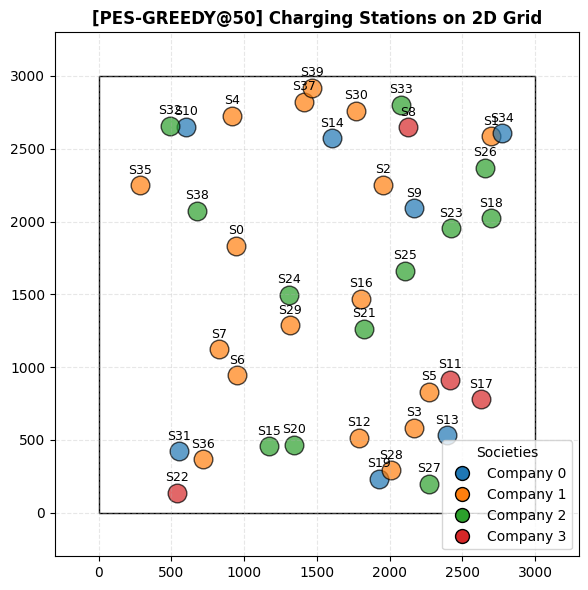

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

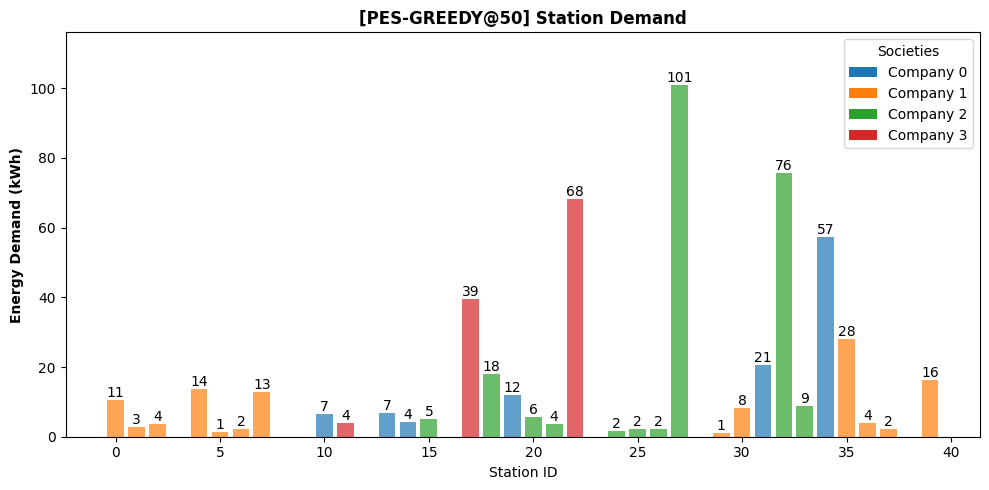

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

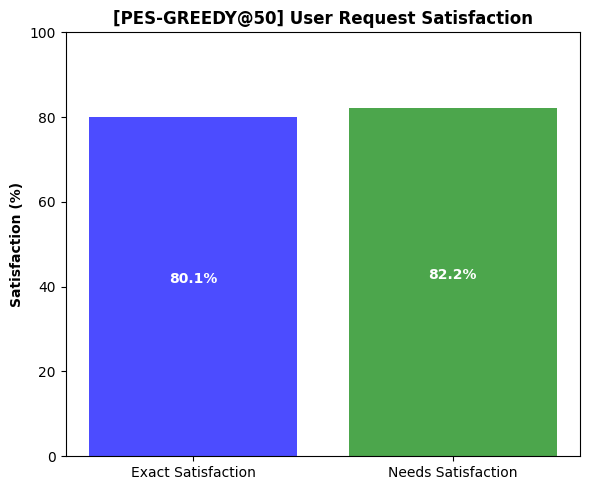

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

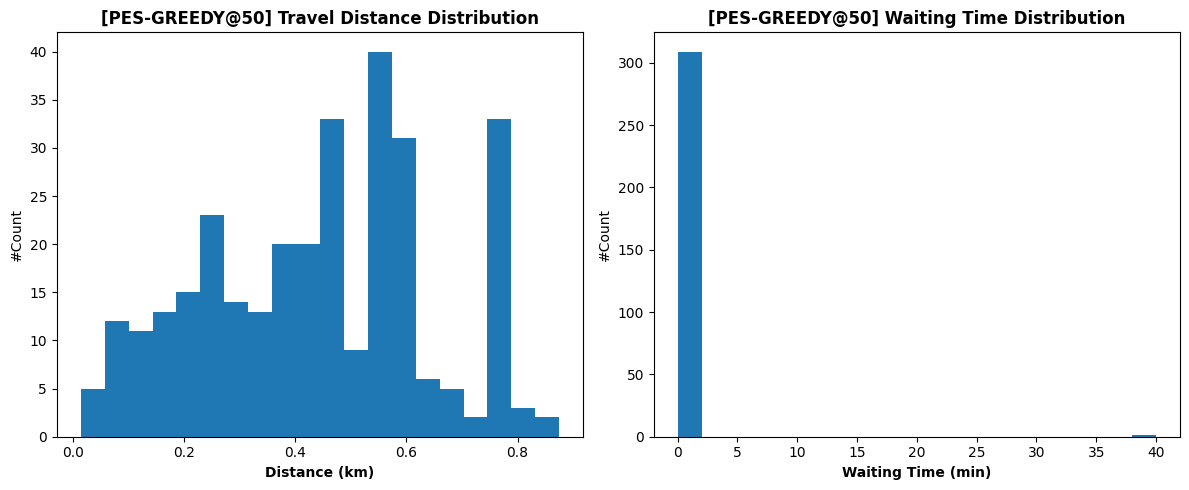

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

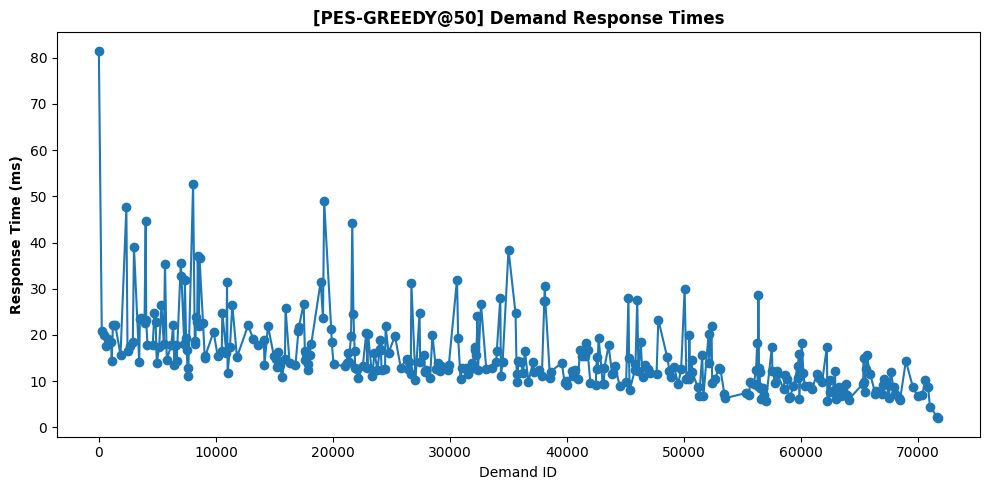

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

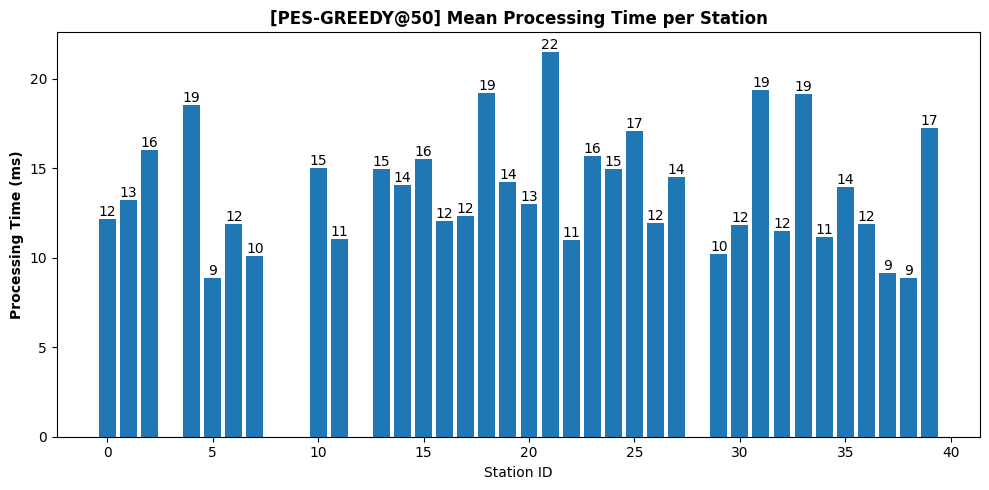

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           9  0.000000  0.000000  0.000000  0.000000  0.000000   
1            0          10  0.093750  0.000000  0.000000  0.000000       NaN   
2            0          13  0.061111  0.013194  0.000000  0.000000  0.000000   
3            0          14  0.072222  0.000000  0.000000  0.000000       NaN   
4            0          19  0.135417  0.030556  0.000000  0.000000  0.000000   
5            0          31  0.209028  0.055556  0.000000  0.000000  0.000000   
6            0          34  0.413194  0.249306  0.036111  0.156250       NaN   
7            1           0  0.168750  0.000000  0.000000  0.000000       NaN   
8            1           1  0.044444  0.000000  0.000000  0.000000  0.000000   
9            1           2  0.047222  0.000000  0.000000  0.000000  0.000000   
10           1           3  0.000000  0.000000  0.000000  0.000000  0.000000   
11           1           4  0.197917  0.

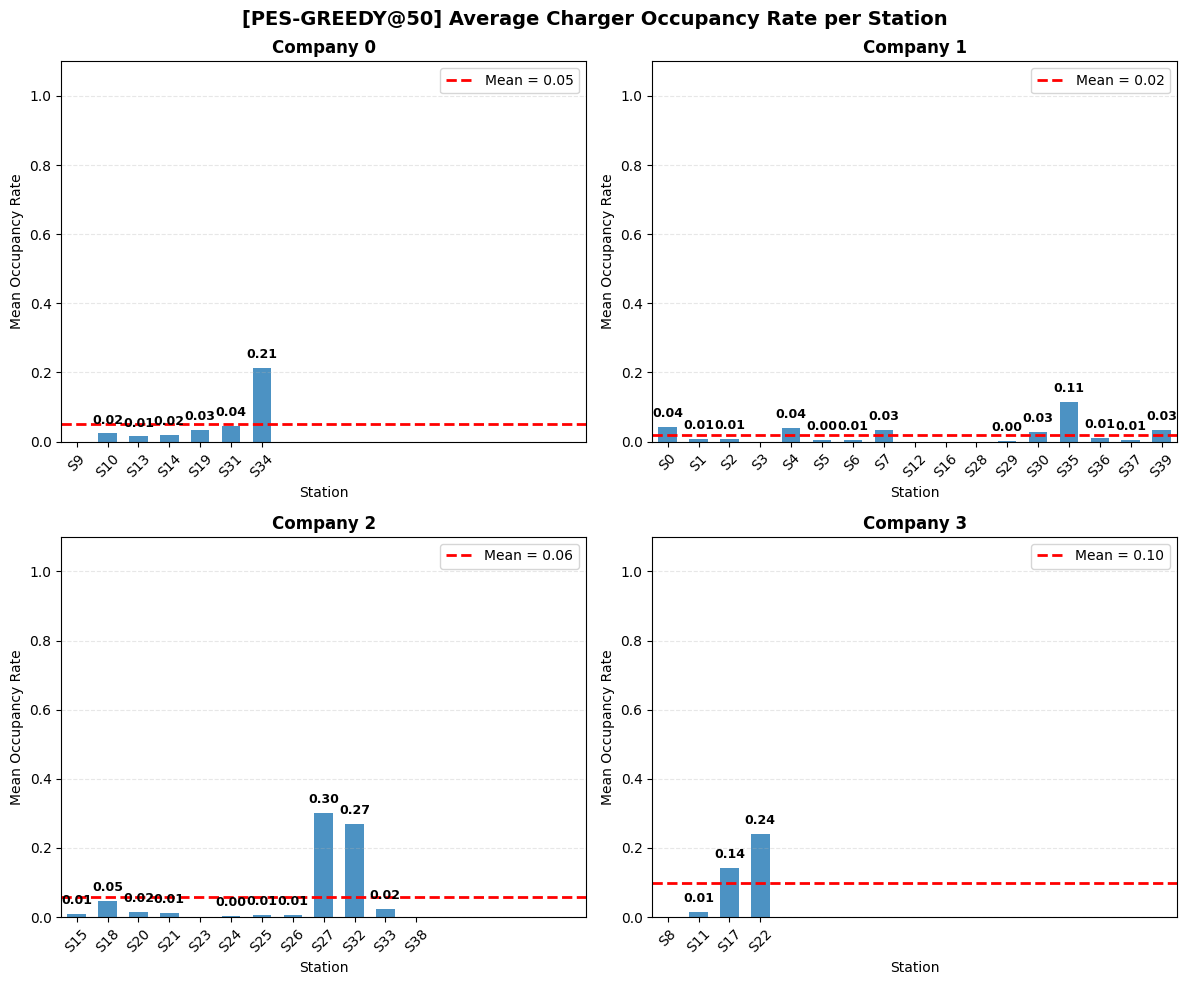

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

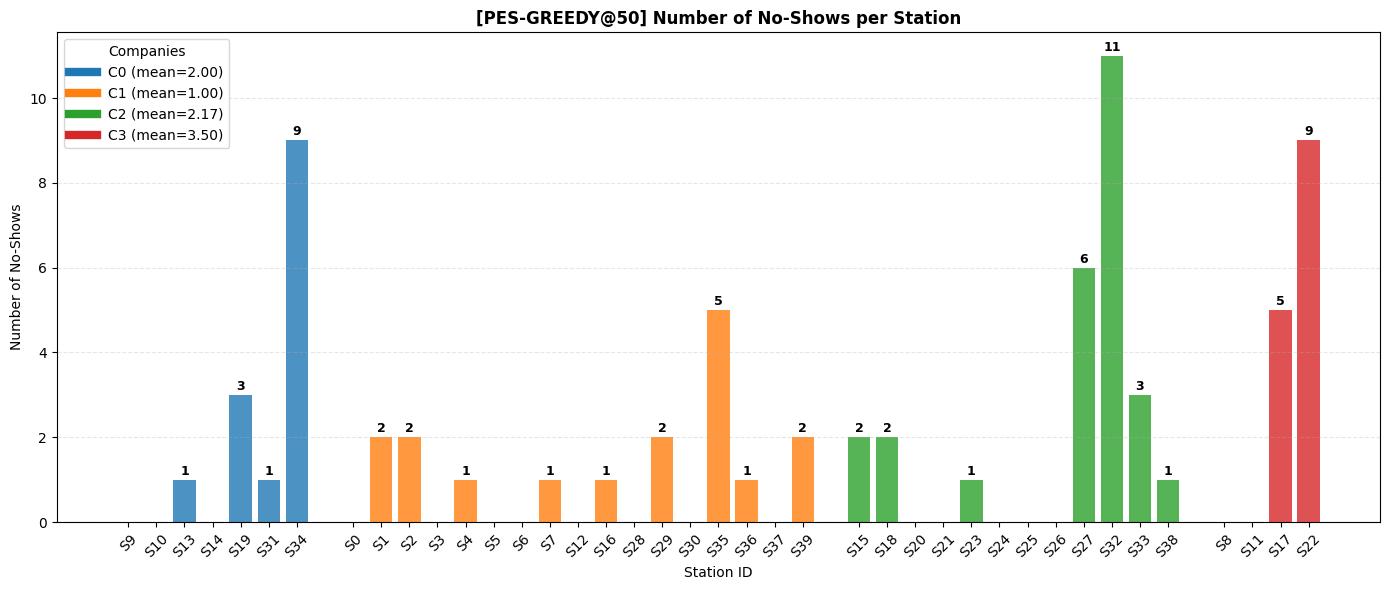

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,9,0,0,0,0,0,NaN,NaN,NaN,NaN
1,0,10,4,4,0,0,0,1.000000,0.000000,0.0,0.0
2,0,13,5,4,1,0,0,0.800000,0.200000,0.0,0.0
3,0,14,2,2,0,0,0,1.000000,0.000000,0.0,0.0
4,0,19,9,6,3,0,0,0.666667,0.333333,0.0,0.0
5,0,31,13,12,1,0,0,0.923077,0.076923,0.0,0.0
6,0,34,44,35,9,0,0,0.795455,0.204545,0.0,0.0
7,1,0,6,6,0,0,0,1.000000,0.000000,0.0,0.0
8,1,1,4,2,2,0,0,0.500000,0.500000,0.0,0.0
9,1,2,4,2,2,0,0,0.500000,0.500000,0.0,0.0


NUMBER OF REJECTED REQUESTS

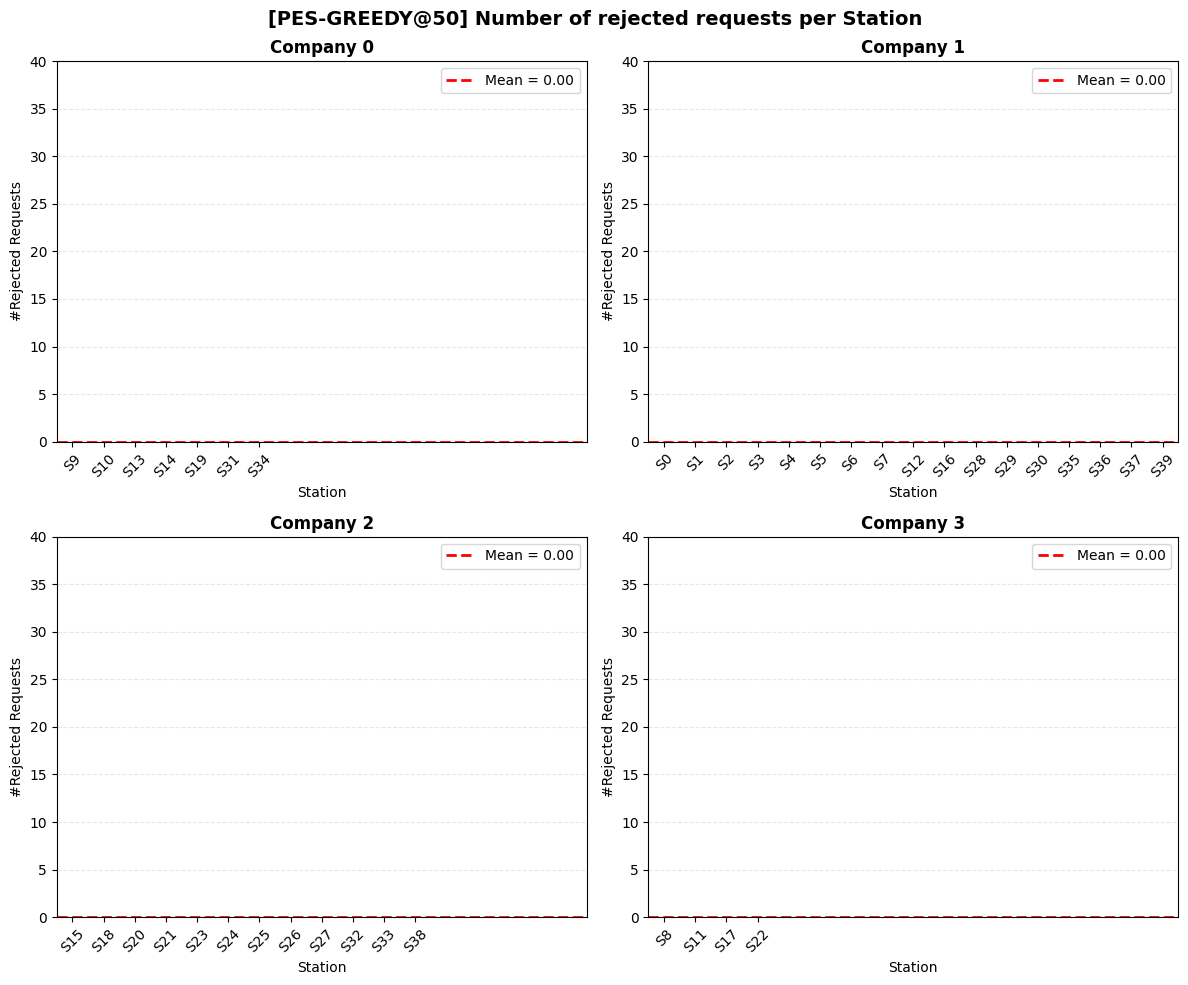

In [30]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [31]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [32]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [33]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:12:14.463 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:12:15.562 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:12:15.835 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:12:16.577 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:12:17.128 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:12:17.557 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:12:17.870 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:12:17.912 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:12:18.521 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:12:19.080 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:12:19.260 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [34]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 53.23 kWh
  Station 1: 0.70 kWh
  Station 2: 49.92 kWh
  Station 3: 10.67 kWh
  Station 4: 0.00 kWh
  Station 5: 7.02 kWh
  Station 6: 22.73 kWh
  Station 7: 1.87 kWh
  Station 8: 0.00 kWh
  Station 9: 3.13 kWh
  Station 10: 0.00 kWh
  Station 11: 7.78 kWh
  Station 12: 0.00 kWh
  Station 13: 1.33 kWh
  Station 14: 0.00 kWh
  Station 15: 4.04 kWh
  Station 16: 14.98 kWh
  Station 17: 7.35 kWh
  Station 18: 0.00 kWh
  Station 19: 0.00 kWh
  Station 20: 6.72 kWh
  Station 21: 70.19 kWh
  Station 22: 0.00 kWh
  Station 23: 0.00 kWh
  Station 24: 12.83 kWh
  Station 25: 6.79 kWh
  Station 26: 65.58 kWh
  Station 27: 13.21 kWh
  Station 28: 9.40 kWh
  Station 29: 12.81 kWh
  Station 30: 54.97 kWh
  Station 31: 7.12 kWh
  Station 32: 67.70 kWh
  Station 33: 1.50 kWh
  Station 34: 0.00 kWh
  Station 35: 3.38 kWh
  Station 36: 0.00 kWh
  Station 37: 4.55 kWh
  Station 38: 10.45 kWh
  Station 39: 25.24 kWh

--- User Req

In [35]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

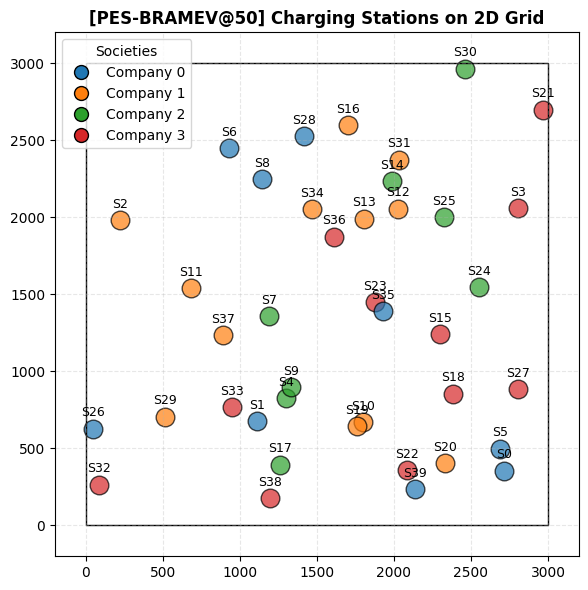

In [36]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

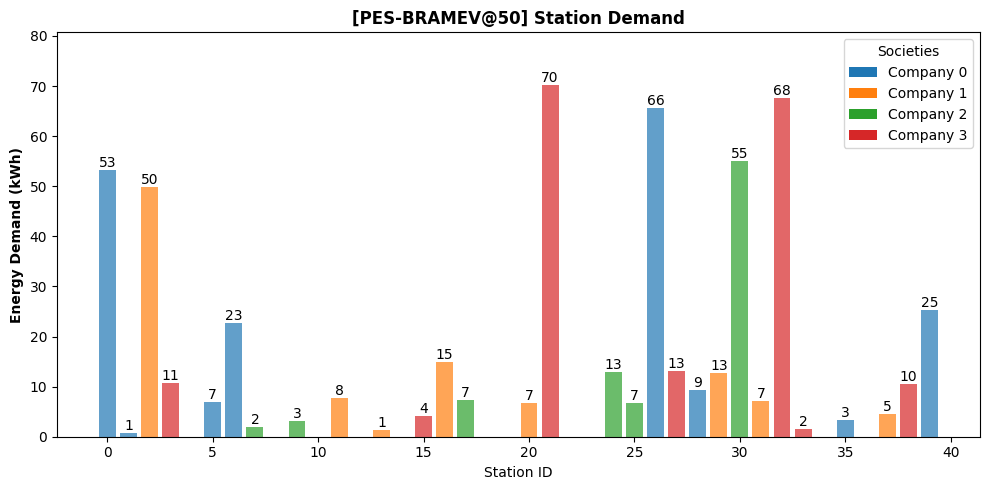

In [37]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

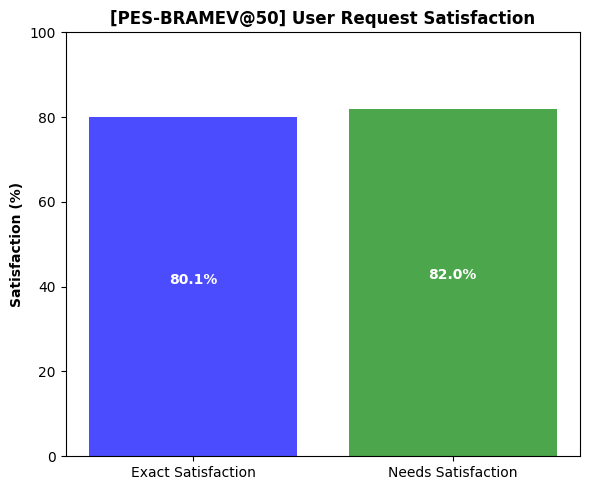

In [38]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

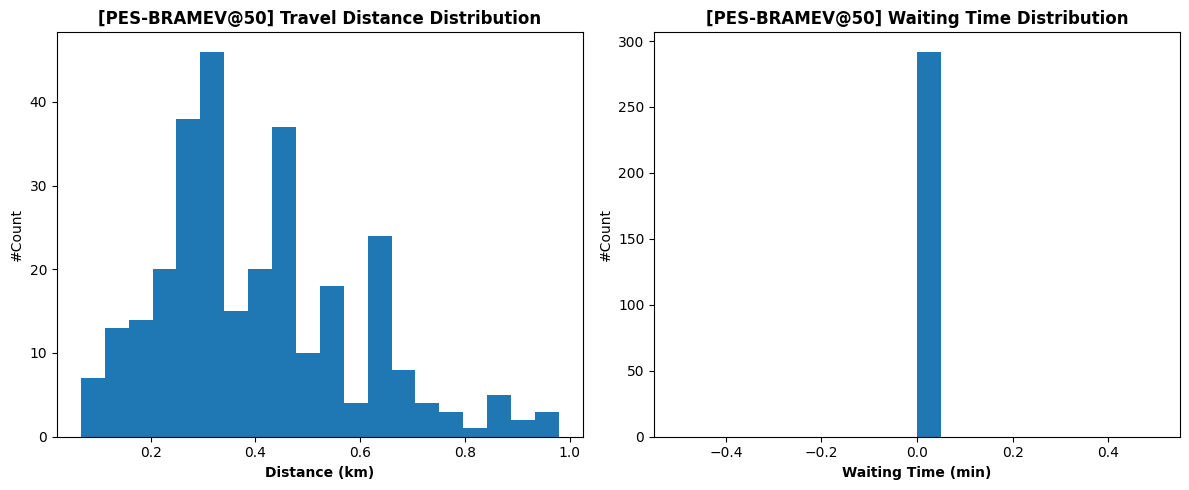

In [39]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

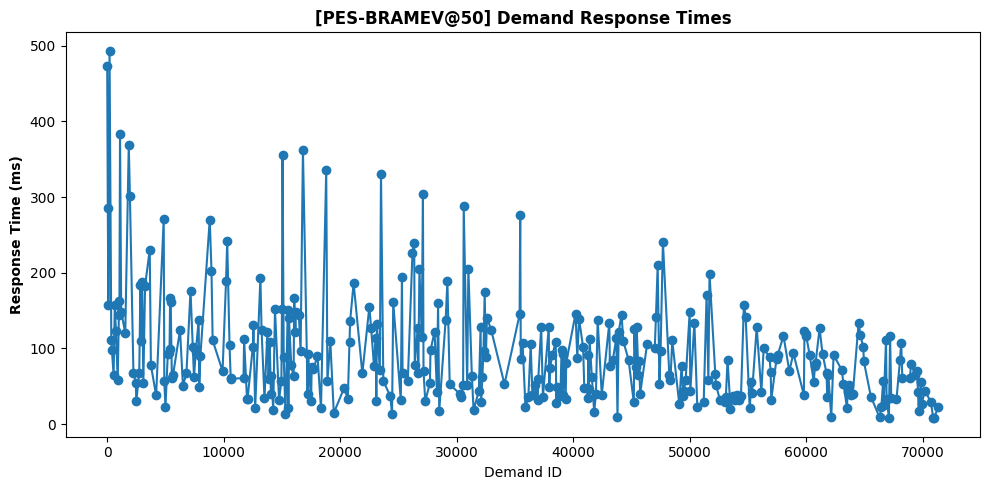

In [40]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

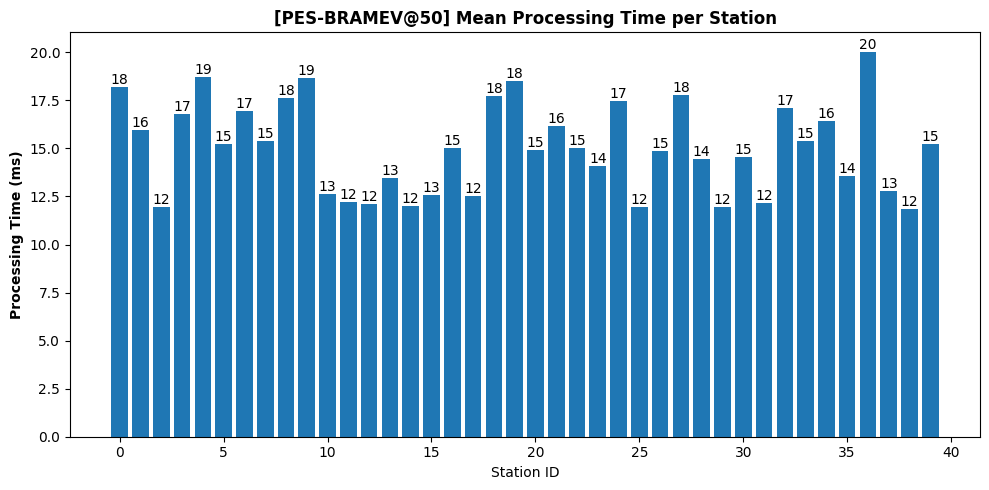

In [41]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

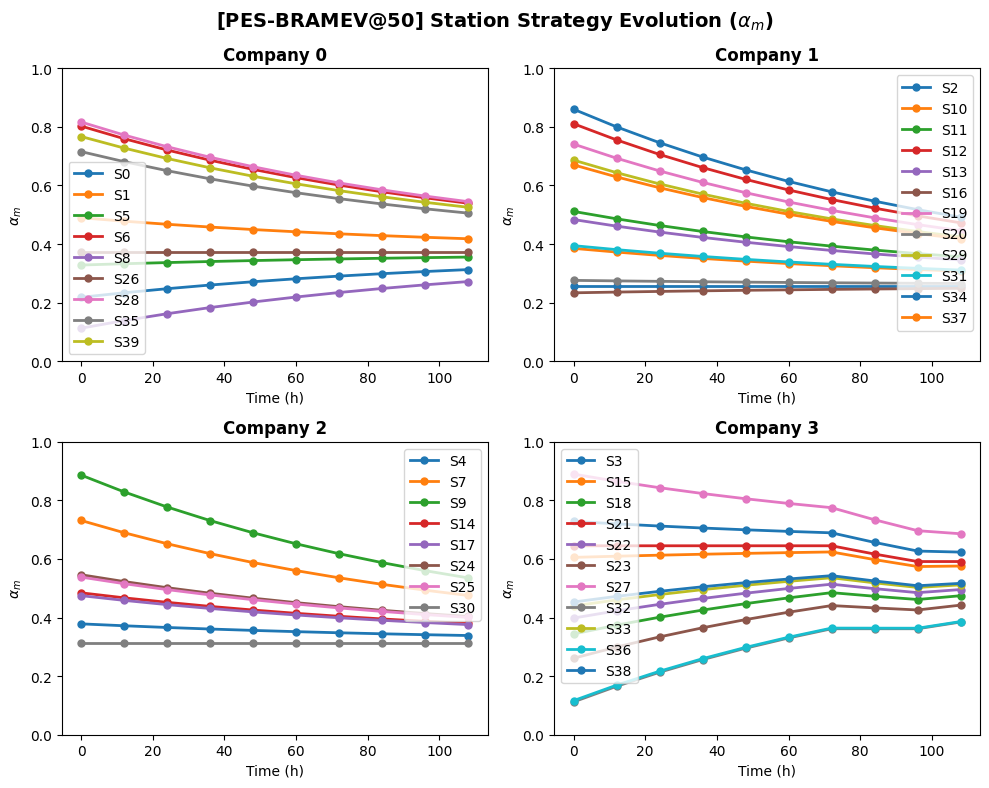

In [42]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [43]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.479861  0.257639  0.018750  0.000000  0.000000   
1            0           1  0.008333  0.000000  0.000000  0.000000  0.000000   
2            0           5  0.125000  0.000000  0.000000  0.000000  0.000000   
3            0           6  0.248611  0.046528  0.000000  0.000000  0.000000   
4            0           8  0.000000  0.000000  0.000000  0.000000  0.000000   
5            0          26  0.394444  0.414583  0.059722  0.000000  0.107639   
6            0          28  0.133333  0.000000  0.000000  0.000000  0.000000   
7            0          35  0.048611  0.000000  0.000000  0.000000       NaN   
8            0          39  0.260417  0.061111  0.013194  0.000000  0.000000   
9            1           2  0.391667  0.154861  0.043056  0.037500       NaN   
10           1          10  0.000000  0.000000  0.000000  0.000000       NaN   
11           1          11  0.114583  0.

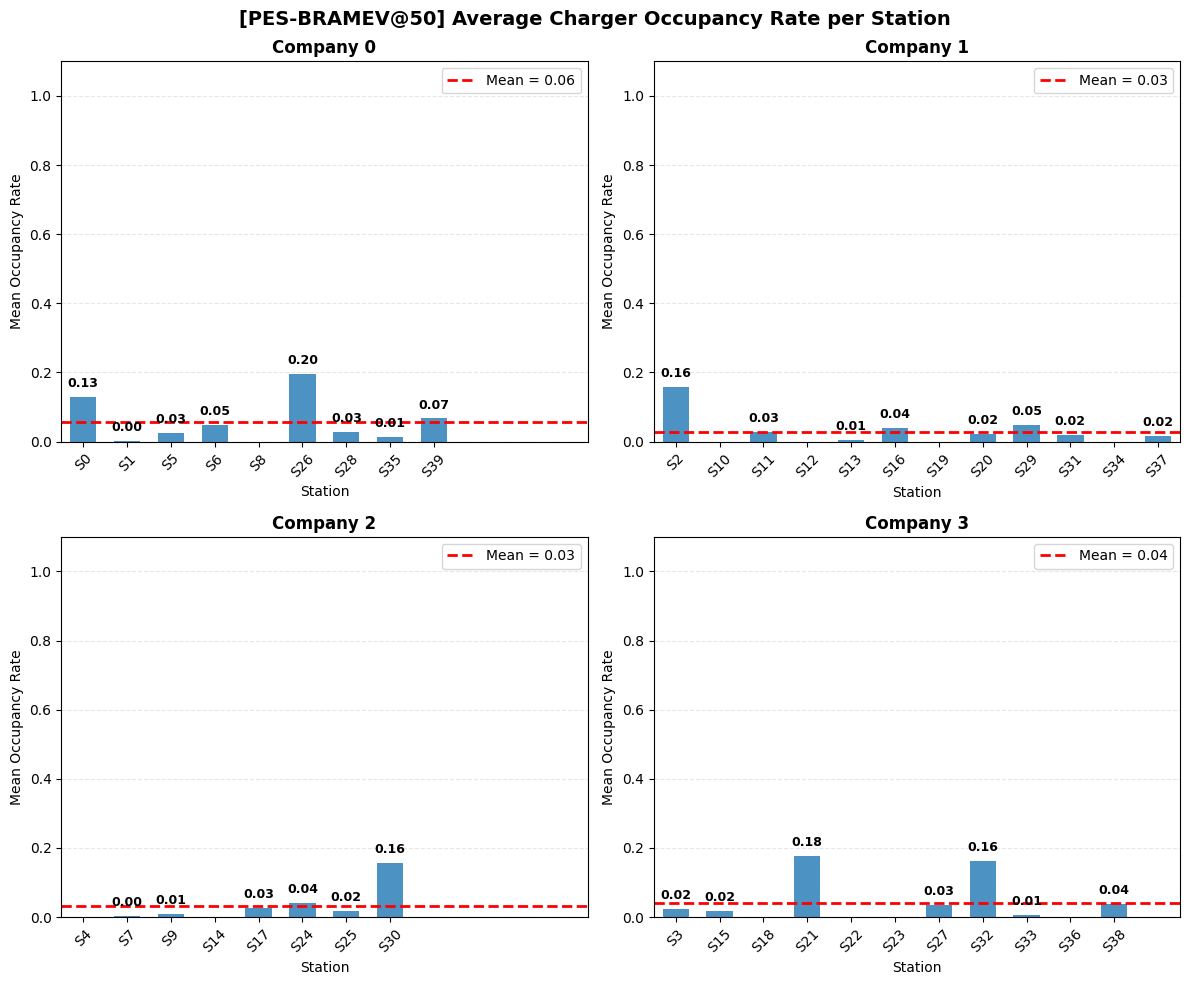

In [44]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

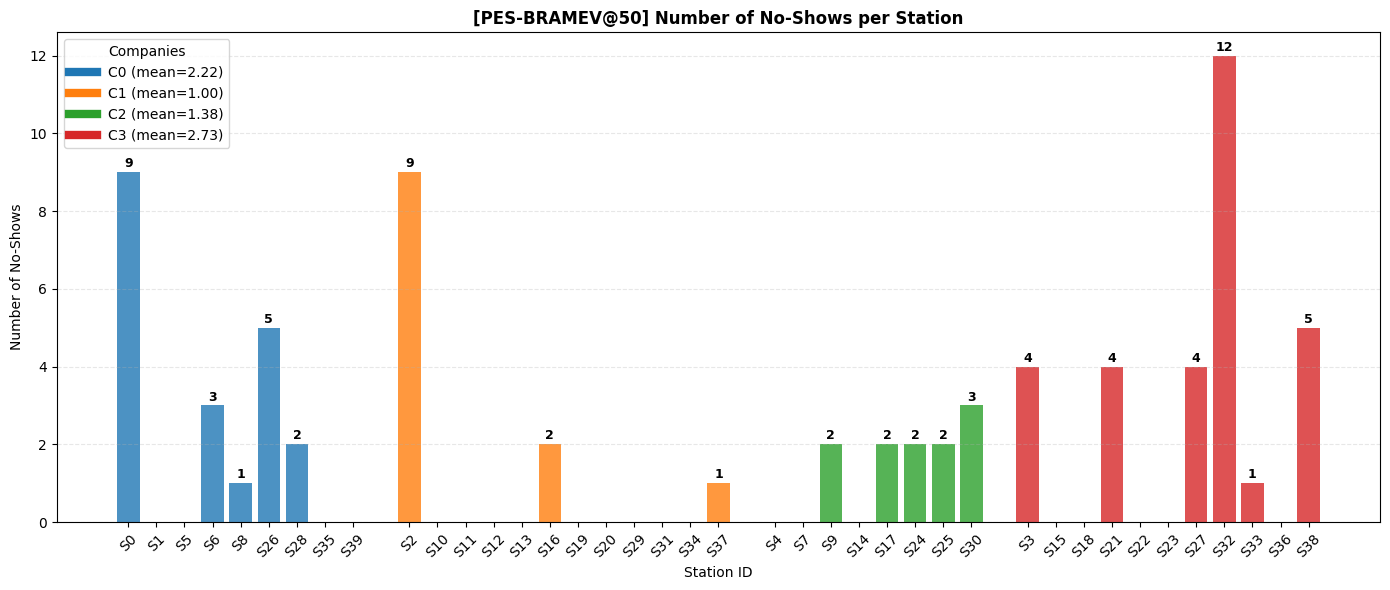

In [45]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [46]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,36,27,9,0,0,0.750000,0.250000,0.0,0.0
1,0,1,1,1,0,0,0,1.000000,0.000000,0.0,0.0
2,0,5,4,4,0,0,0,1.000000,0.000000,0.0,0.0
3,0,6,15,12,3,0,0,0.800000,0.200000,0.0,0.0
4,0,8,1,0,1,0,0,0.000000,1.000000,0.0,0.0
5,0,26,41,34,5,0,0,0.829268,0.121951,0.0,0.0
6,0,28,7,5,2,0,0,0.714286,0.285714,0.0,0.0
7,0,35,2,2,0,0,0,1.000000,0.000000,0.0,0.0
8,0,39,14,14,0,0,0,1.000000,0.000000,0.0,0.0
9,1,2,36,27,9,0,0,0.750000,0.250000,0.0,0.0


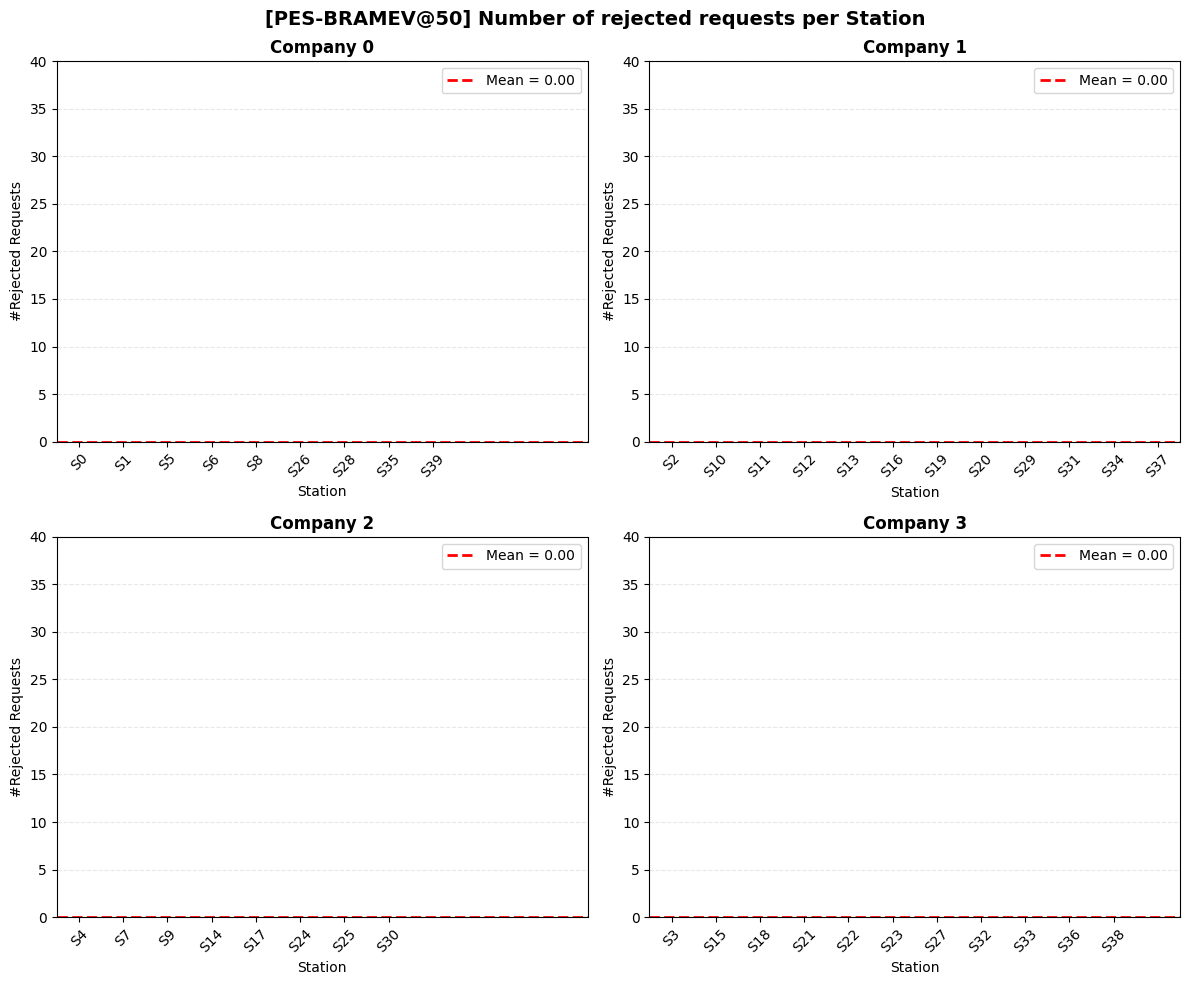

In [47]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

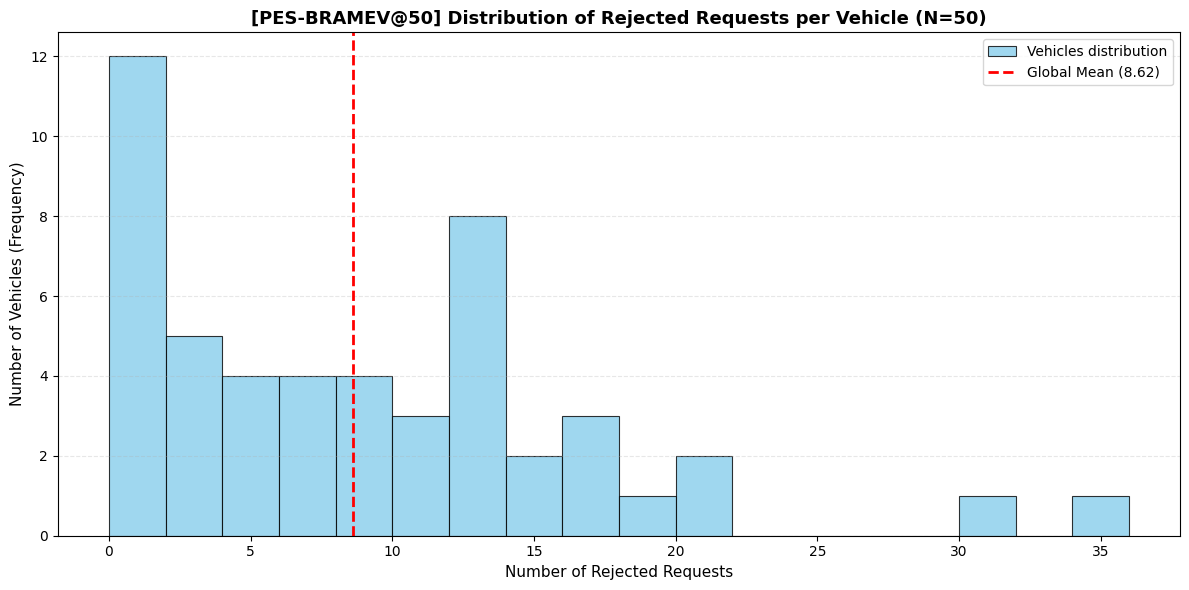

In [48]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

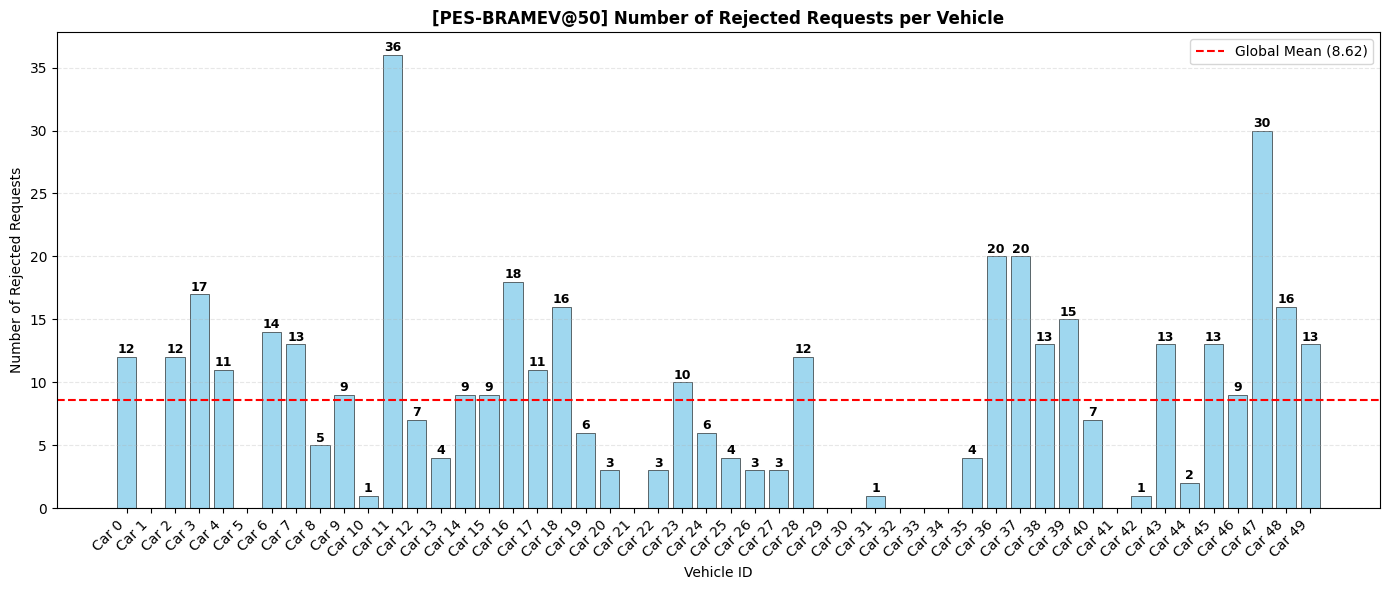

In [49]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

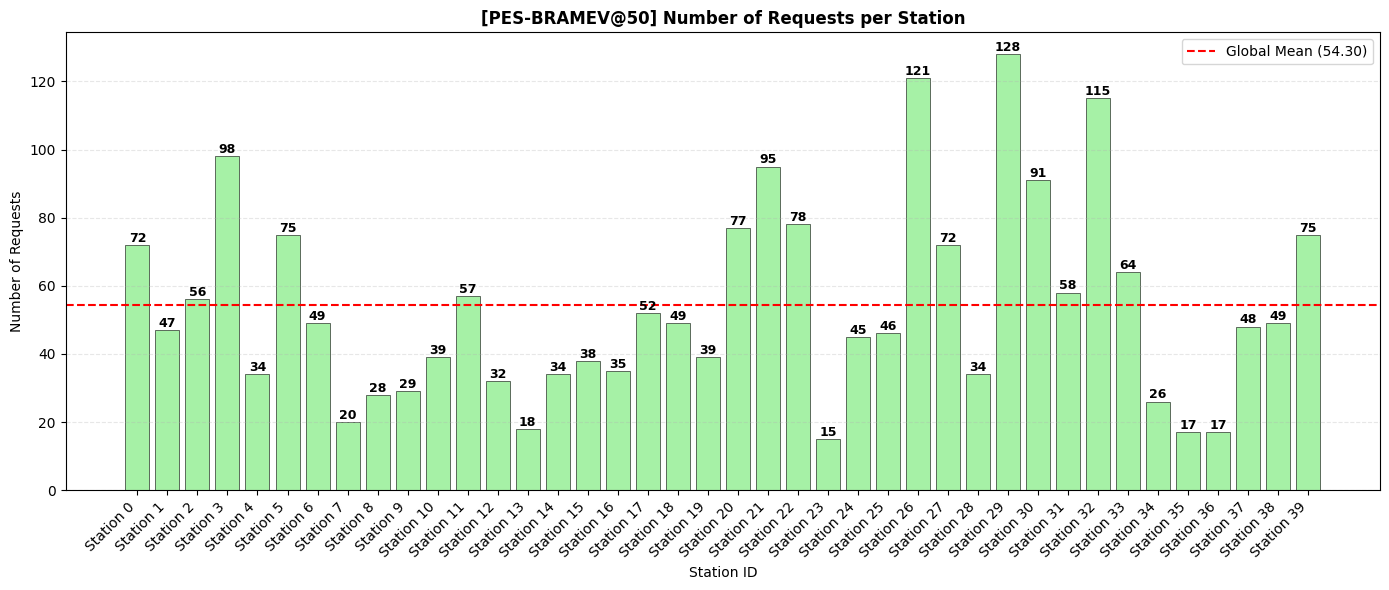

In [50]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [51]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

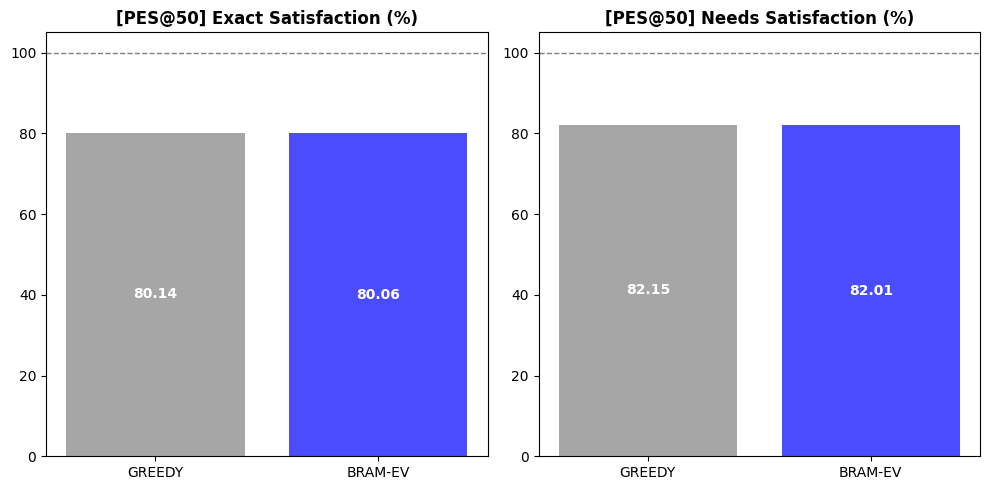

In [52]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

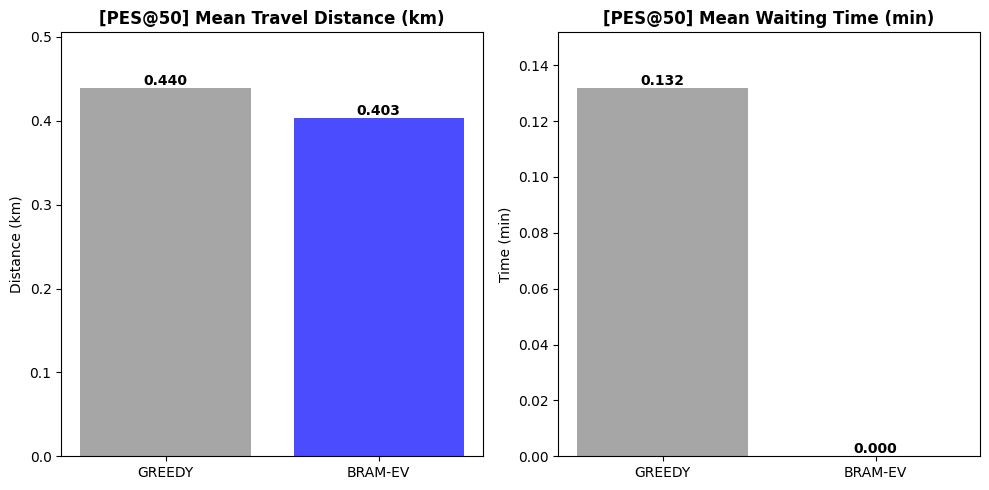

In [53]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

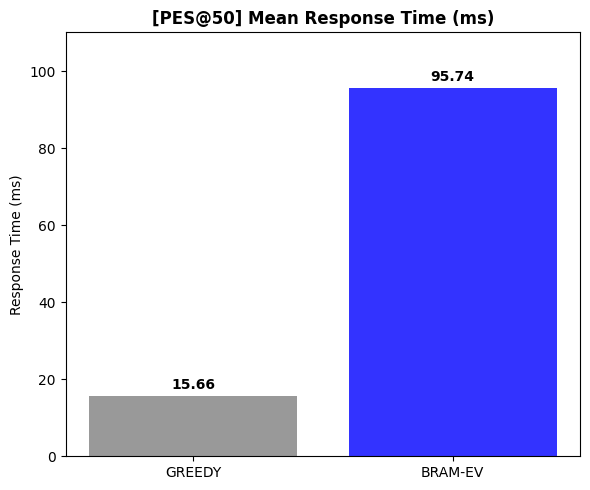

In [54]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [55]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [56]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [57]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [58]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:12:47.277 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:12:47.365 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:12:47.512 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:12:47.634 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:12:47.779 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:12:47.941 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:12:48.103 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:12:48.459 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:12:48.717 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:12:48.862 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:12:49.003 | IN

##### *Metrics*

In [59]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.89 kWh
  Station 1: 1.40 kWh
  Station 2: 0.00 kWh
  Station 3: 47.06 kWh
  Station 4: 17.15 kWh
  Station 5: 1.20 kWh
  Station 6: 21.84 kWh
  Station 7: 0.00 kWh
  Station 8: 18.17 kWh
  Station 9: 6.58 kWh
  Station 10: 148.58 kWh
  Station 11: 21.19 kWh
  Station 12: 18.81 kWh
  Station 13: 1.73 kWh
  Station 14: 2.00 kWh
  Station 15: 1.47 kWh
  Station 16: 1.96 kWh
  Station 17: 19.71 kWh
  Station 18: 12.06 kWh
  Station 19: 8.34 kWh
  Station 20: 5.72 kWh
  Station 21: 138.88 kWh
  Station 22: 118.30 kWh
  Station 23: 7.42 kWh
  Station 24: 1.75 kWh
  Station 25: 149.53 kWh
  Station 26: 32.48 kWh
  Station 27: 49.08 kWh
  Station 28: 24.48 kWh
  Station 29: 29.19 kWh
  Station 30: 2.57 kWh
  Station 31: 8.20 kWh
  Station 32: 18.50 kWh
  Station 33: 1.93 kWh
  Station 34: 18.40 kWh
  Station 35: 13.90 kWh
  Station 36: 41.56 kWh
  Station 37: 5.50 kWh
  Station 38: 38.01 kWh
  Station 39: 2.45 kWh

-

In [60]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

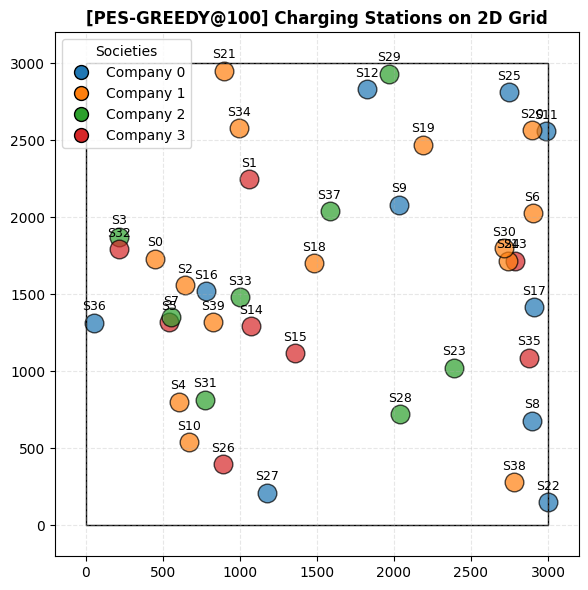

In [61]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

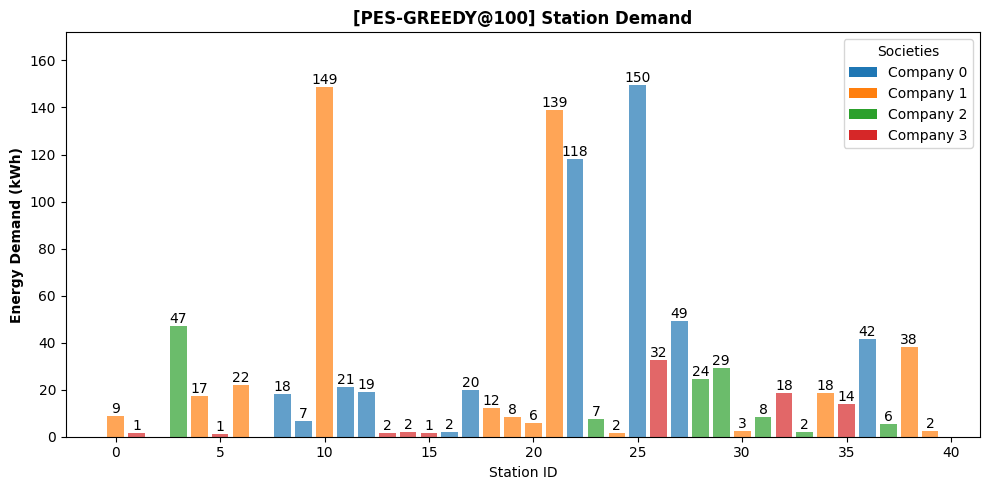

In [62]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

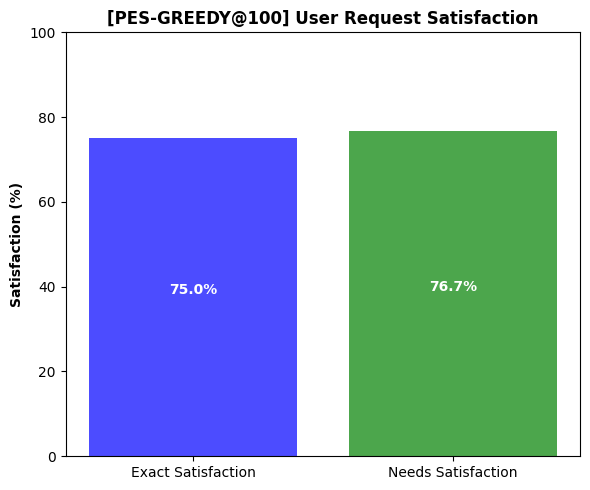

In [63]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

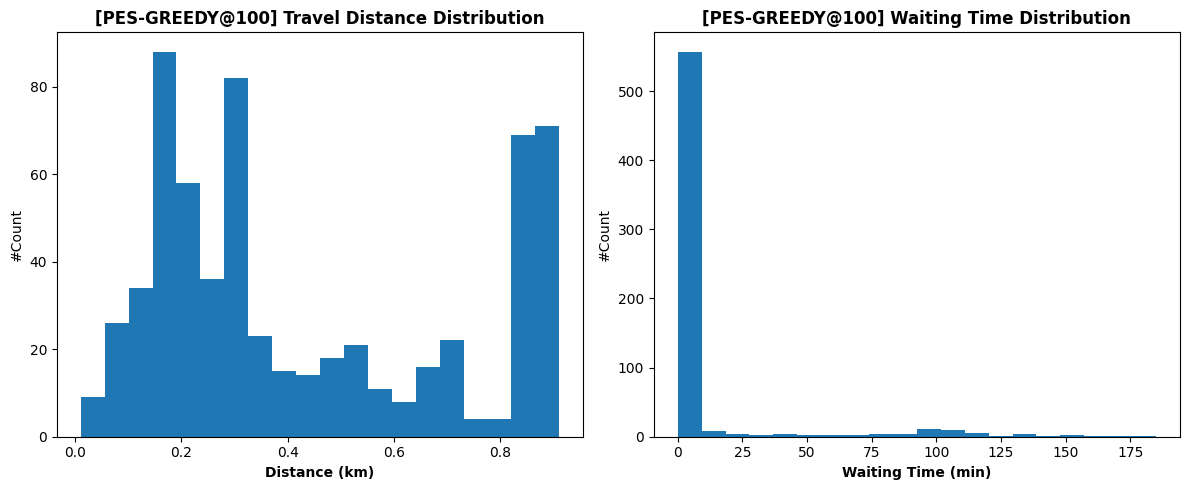

In [64]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

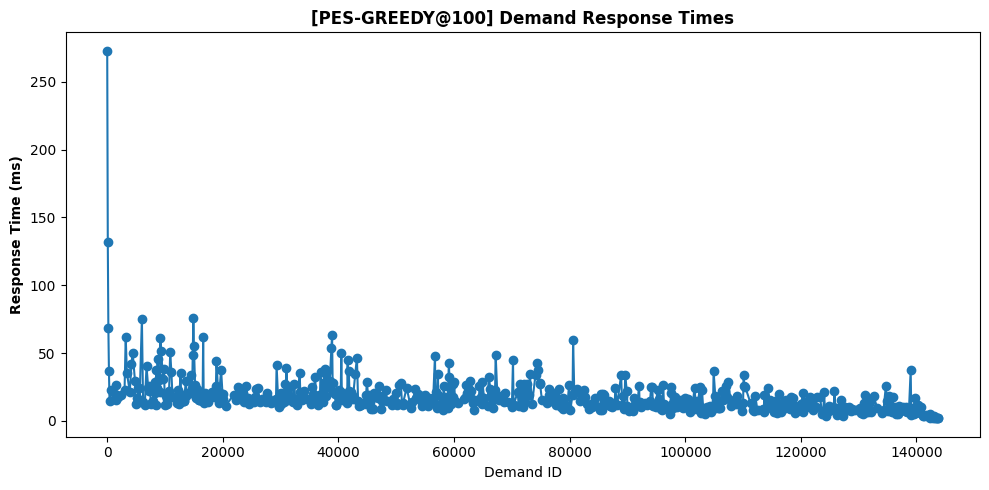

In [65]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

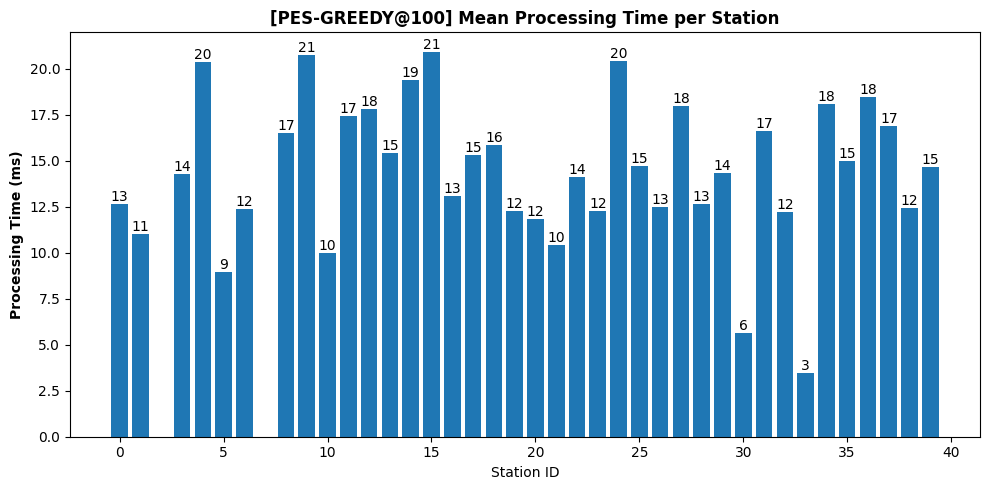

In [66]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [67]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           8  0.177778  0.034028  0.000000  0.000000  0.000000   
1            0           9  0.126389  0.000000  0.000000  0.000000  0.000000   
2            0          11  0.233333  0.035417  0.000000  0.000000  0.000000   
3            0          12  0.229167  0.021528  0.016667  0.000000  0.000000   
4            0          16  0.032639  0.000000  0.000000  0.000000       NaN   
5            0          17  0.161806  0.029861  0.000000  0.026389  0.025694   
6            0          22  0.650000  0.536111  0.179167  0.106944  0.334028   
7            0          25  0.617361  0.552778  0.186806  0.242361  0.295139   
8            0          27  0.356250  0.272917  0.000000  0.000000  0.000000   
9            0          36  0.331250  0.170833  0.043750  0.000000  0.000000   
10           1           0  0.153472  0.000000  0.000000  0.000000       NaN   
11           1           2  0.000000  0.

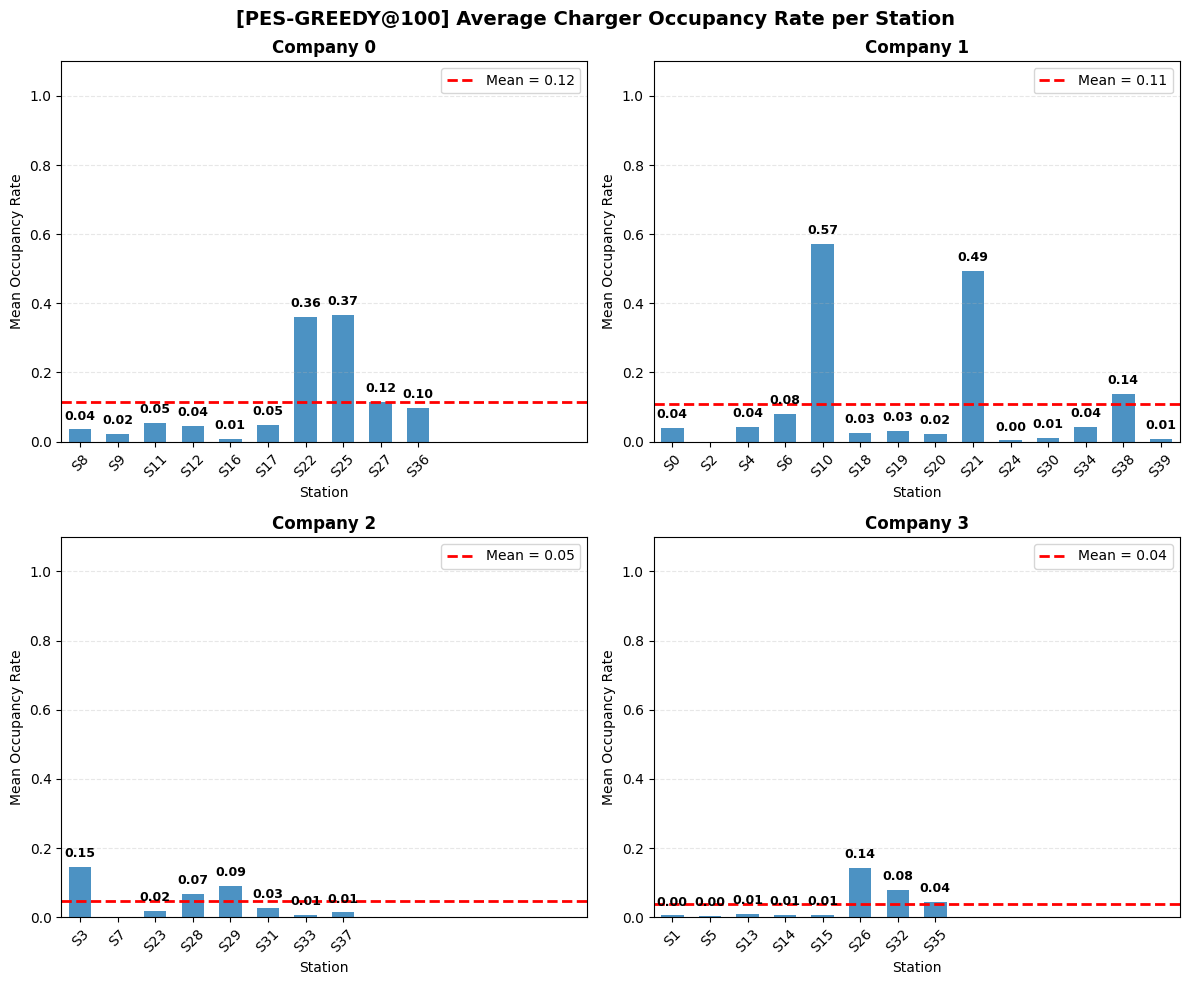

In [68]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

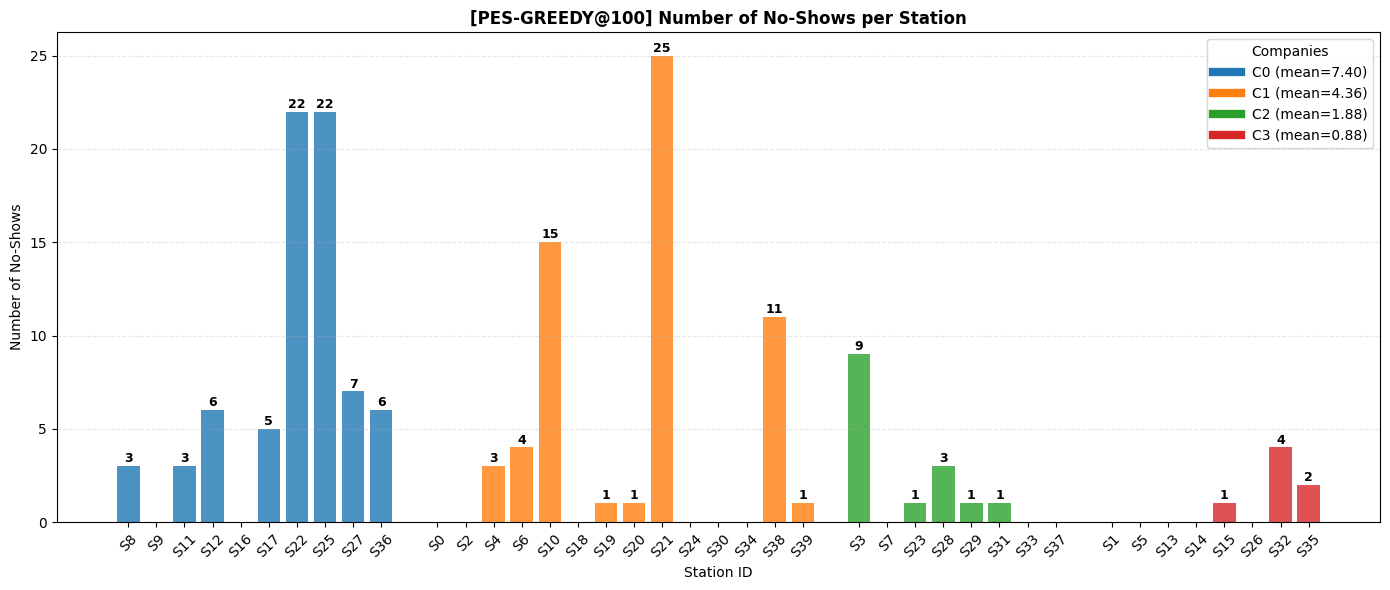

In [69]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [70]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,8,13,10,3,0,0,0.769231,0.230769,0.000000,0.000000
1,0,9,4,4,0,0,0,1.000000,0.000000,0.000000,0.000000
2,0,11,15,12,3,0,0,0.800000,0.200000,0.000000,0.000000
3,0,12,17,10,6,0,0,0.588235,0.352941,0.000000,0.000000
4,0,16,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
5,0,17,15,10,5,0,0,0.666667,0.333333,0.000000,0.000000
6,0,22,89,67,22,0,0,0.752809,0.247191,0.000000,0.000000
7,0,25,110,86,22,1,0,0.781818,0.200000,0.009091,0.000000
8,0,27,34,27,7,0,0,0.794118,0.205882,0.000000,0.000000
9,0,36,29,23,6,0,0,0.793103,0.206897,0.000000,0.000000


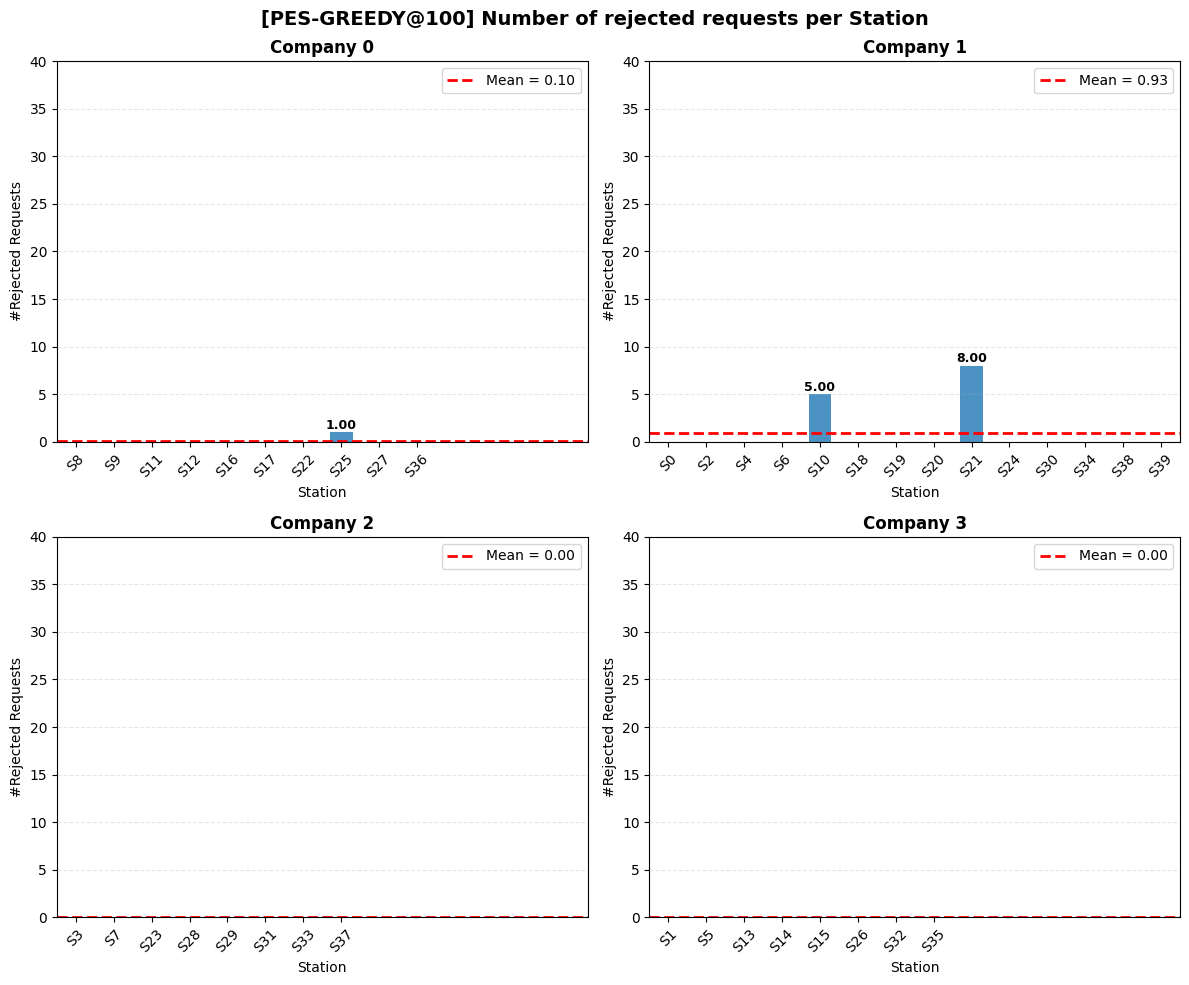

In [71]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [72]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [73]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [74]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:13:04.551 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:13:05.050 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:13:06.293 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:13:07.446 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:13:08.804 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:13:09.965 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:13:11.207 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:13:11.702 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:13:12.477 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:13:13.659 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:13:14.563 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [75]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 14.05 kWh
  Station 1: 6.33 kWh
  Station 2: 4.92 kWh
  Station 3: 24.85 kWh
  Station 4: 16.19 kWh
  Station 5: 3.37 kWh
  Station 6: 46.83 kWh
  Station 7: 14.14 kWh
  Station 8: 5.98 kWh
  Station 9: 130.53 kWh
  Station 10: 104.79 kWh
  Station 11: 8.82 kWh
  Station 12: 20.58 kWh
  Station 13: 54.67 kWh
  Station 14: 7.49 kWh
  Station 15: 5.77 kWh
  Station 16: 25.18 kWh
  Station 17: 3.81 kWh
  Station 18: 65.32 kWh
  Station 19: 10.12 kWh
  Station 20: 7.15 kWh
  Station 21: 14.37 kWh
  Station 22: 16.91 kWh
  Station 23: 1.75 kWh
  Station 24: 1.90 kWh
  Station 25: 20.82 kWh
  Station 26: 35.08 kWh
  Station 27: 1.80 kWh
  Station 28: 20.30 kWh
  Station 29: 31.15 kWh
  Station 30: 115.16 kWh
  Station 31: 0.00 kWh
  Station 32: 3.32 kWh
  Station 33: 50.62 kWh
  Station 34: 12.46 kWh
  Station 35: 36.28 kWh
  Station 36: 42.75 kWh
  Station 37: 6.62 kWh
  Station 38: 2.27 kWh
  Station 39: 105.84 kWh

In [76]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

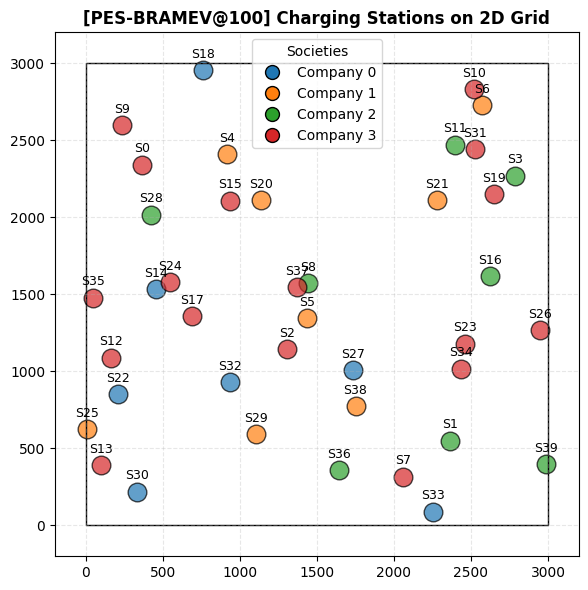

In [77]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

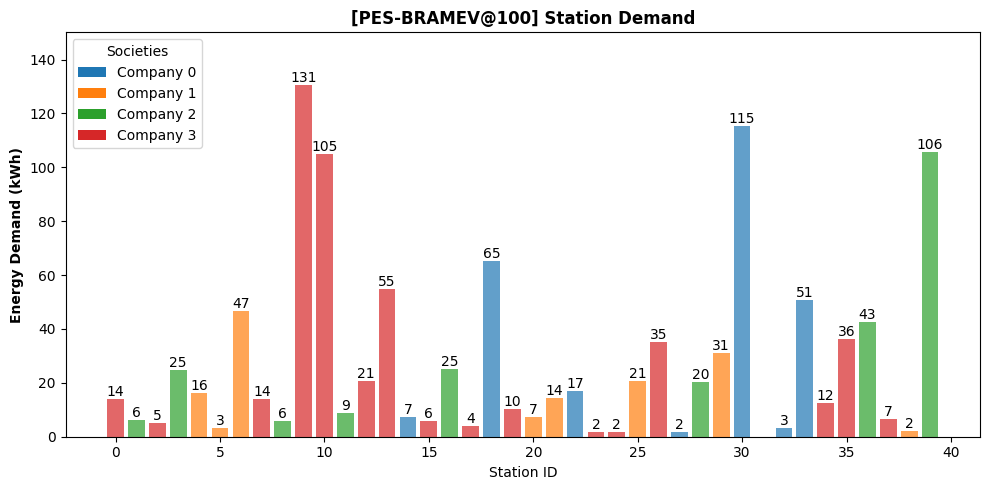

In [78]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

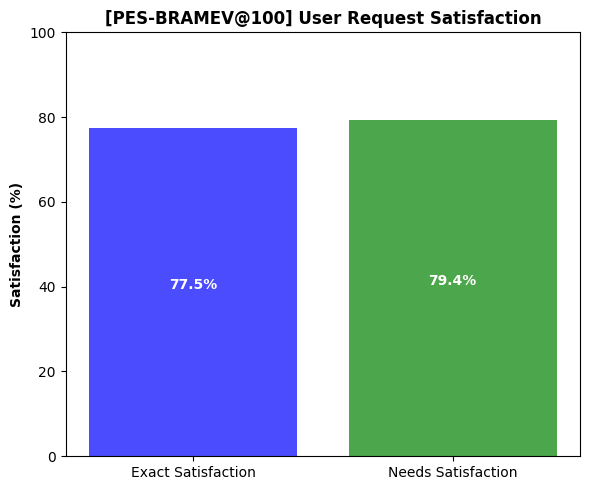

In [79]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

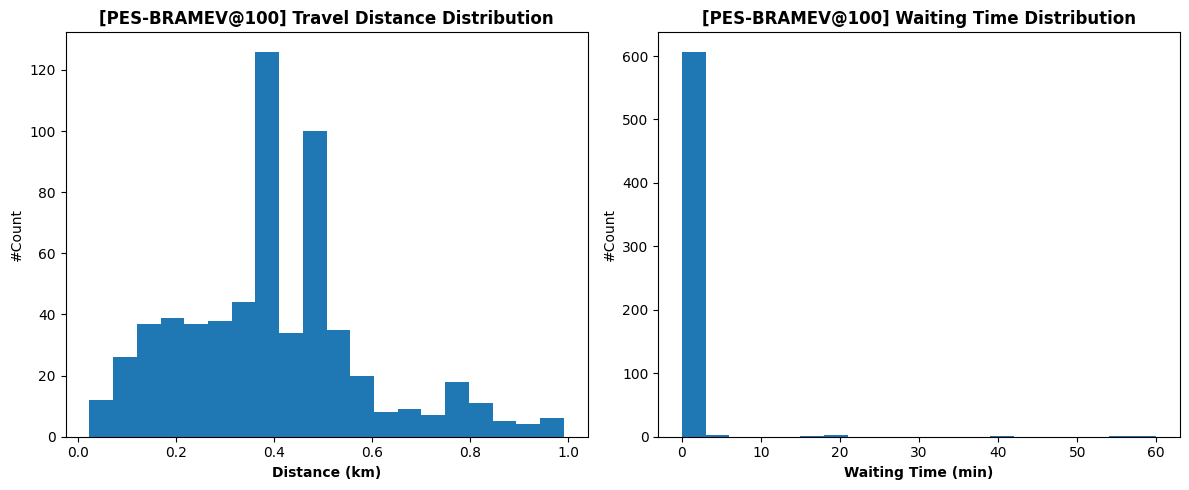

In [80]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

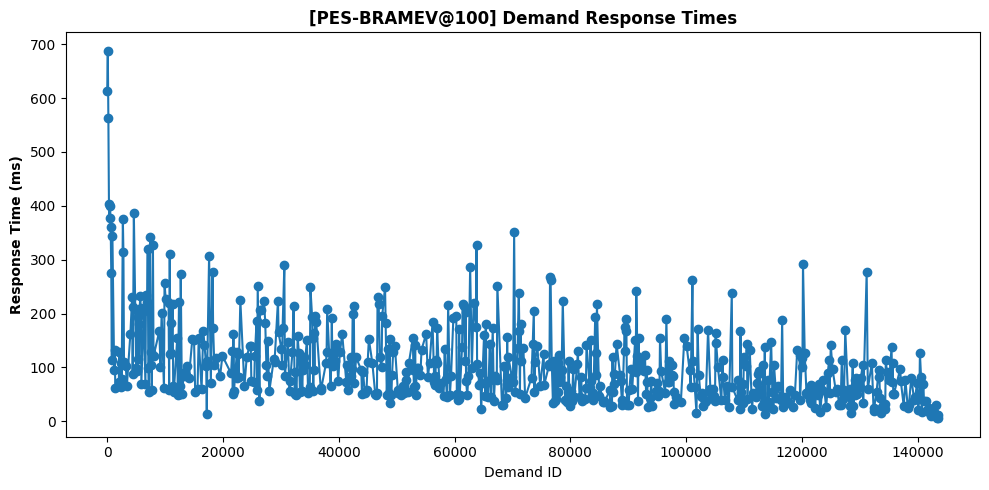

In [81]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

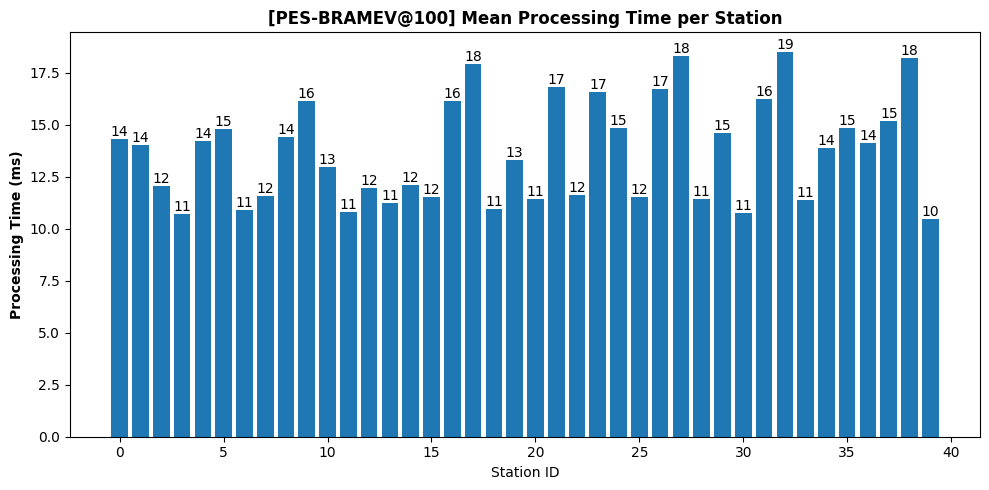

In [82]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

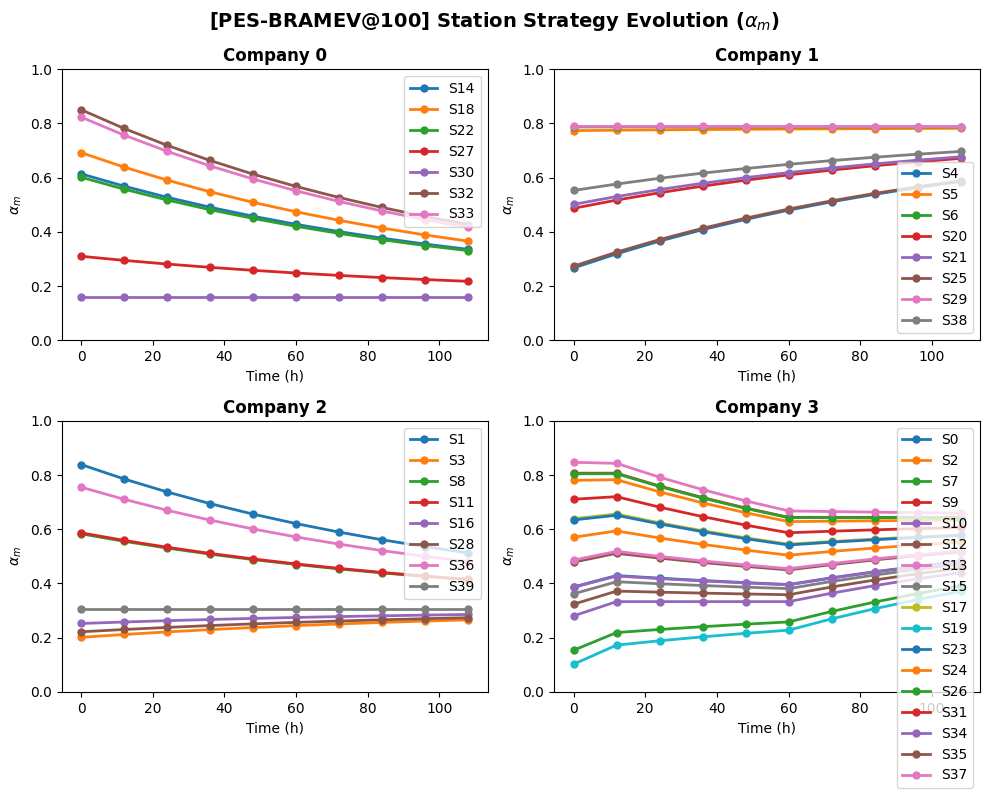

In [83]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [84]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          14  0.052083  0.038889  0.021528  0.000000       NaN   
1            0          18  0.556944  0.179167  0.075000  0.156250       NaN   
2            0          22  0.190972  0.077083  0.000000  0.000000       NaN   
3            0          27  0.025000  0.000000  0.000000  0.000000  0.000000   
4            0          30  0.539583  0.425694  0.244444  0.328472       NaN   
5            0          32  0.031944  0.016667  0.000000  0.000000  0.000000   
6            0          33  0.402083  0.190278  0.024306  0.046528       NaN   
7            1           4  0.156250  0.054167  0.000000  0.000000  0.000000   
8            1           5  0.045139  0.000000  0.000000  0.000000  0.000000   
9            1           6  0.312500  0.225694  0.025000  0.065278       NaN   
10           1          20  0.102083  0.000000  0.000000  0.000000       NaN   
11           1          21  0.212500  0.

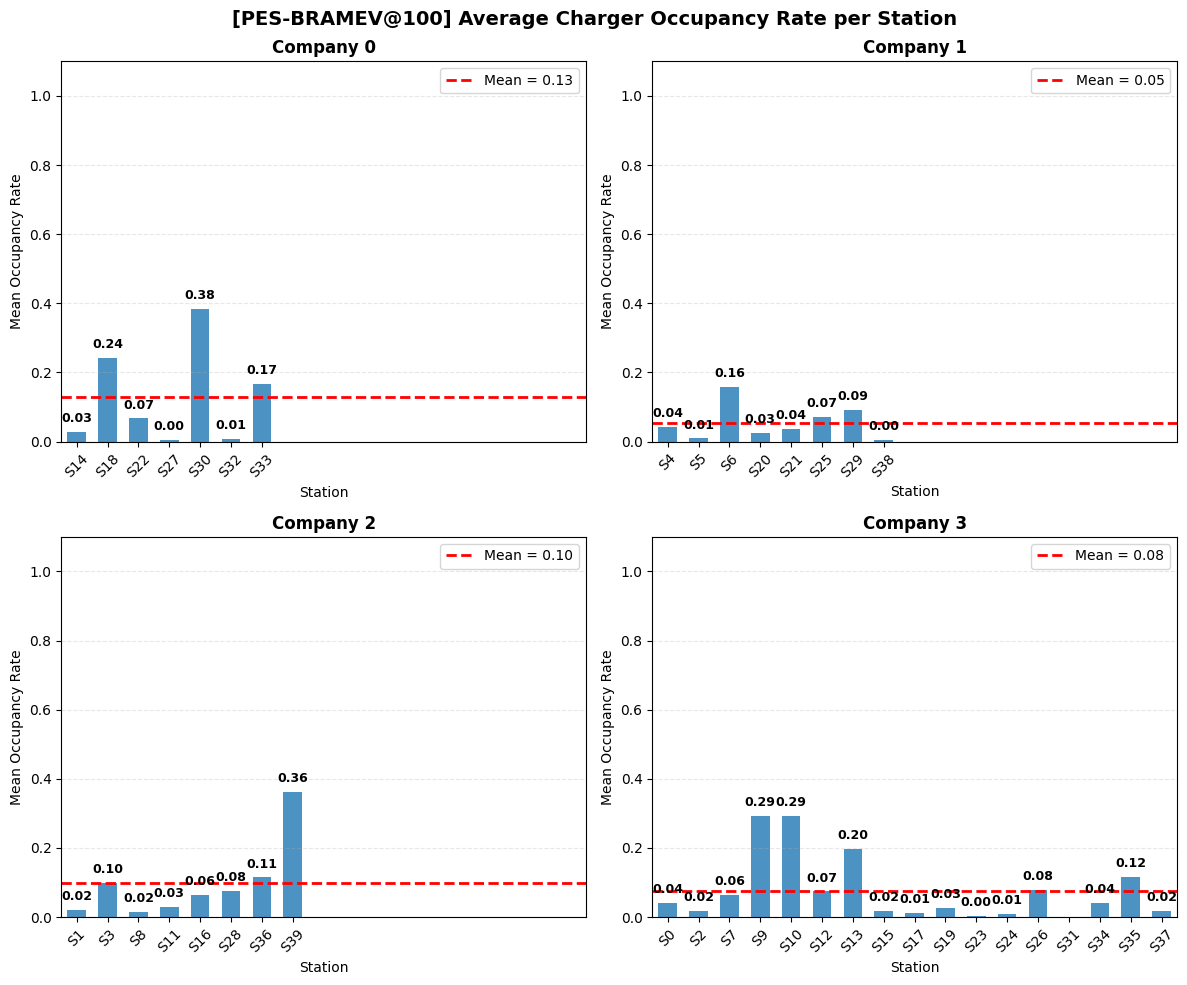

In [85]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

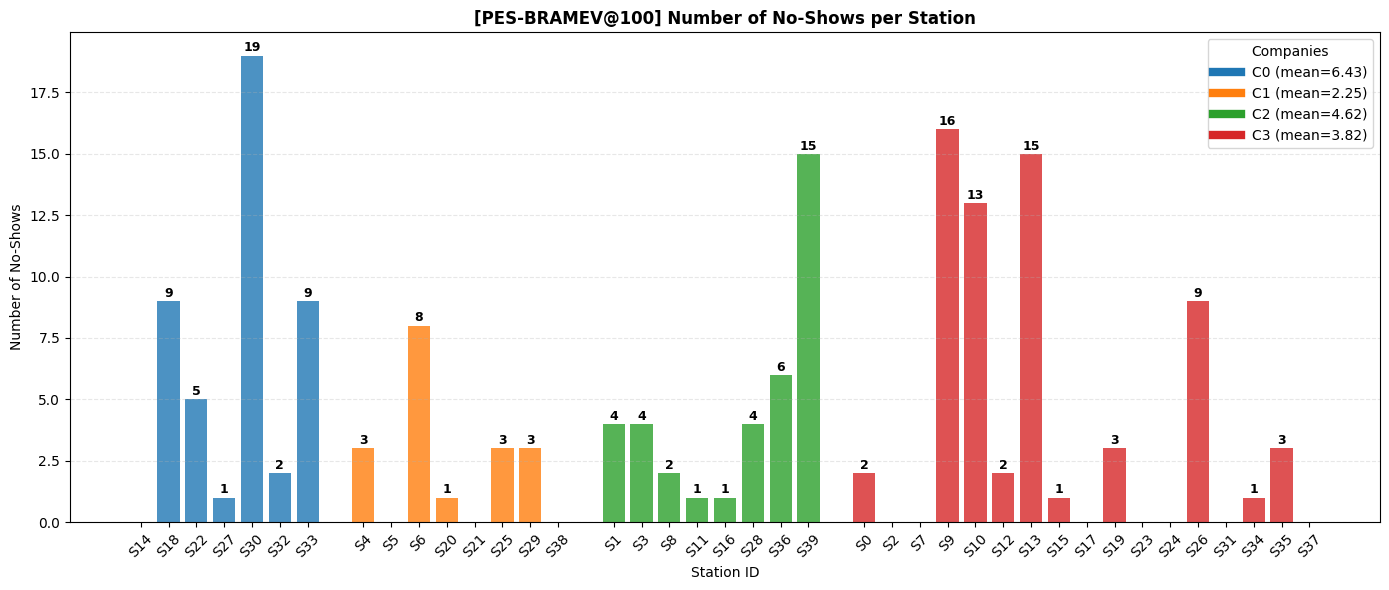

In [86]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [87]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,14,5,5,0,0,0,1.000000,0.000000,0.0,0.0
1,0,18,46,36,9,0,0,0.782609,0.195652,0.0,0.0
2,0,22,13,8,5,0,0,0.615385,0.384615,0.0,0.0
3,0,27,2,1,1,0,0,0.500000,0.500000,0.0,0.0
4,0,30,83,64,19,0,0,0.771084,0.228916,0.0,0.0
5,0,32,4,2,2,0,0,0.500000,0.500000,0.0,0.0
6,0,33,38,29,9,0,0,0.763158,0.236842,0.0,0.0
7,1,4,10,7,3,0,0,0.700000,0.300000,0.0,0.0
8,1,5,2,2,0,0,0,1.000000,0.000000,0.0,0.0
9,1,6,34,26,8,0,0,0.764706,0.235294,0.0,0.0


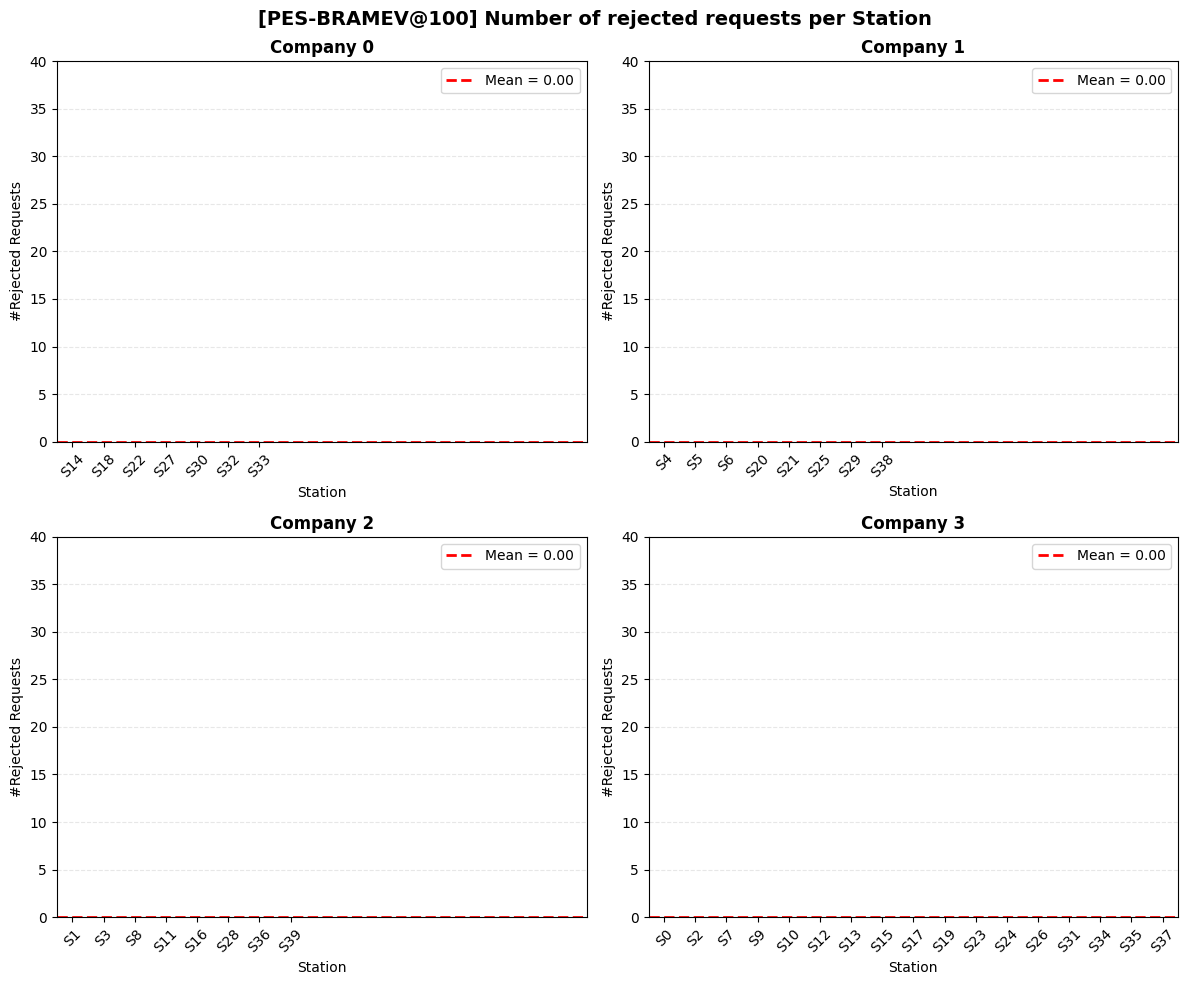

In [88]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

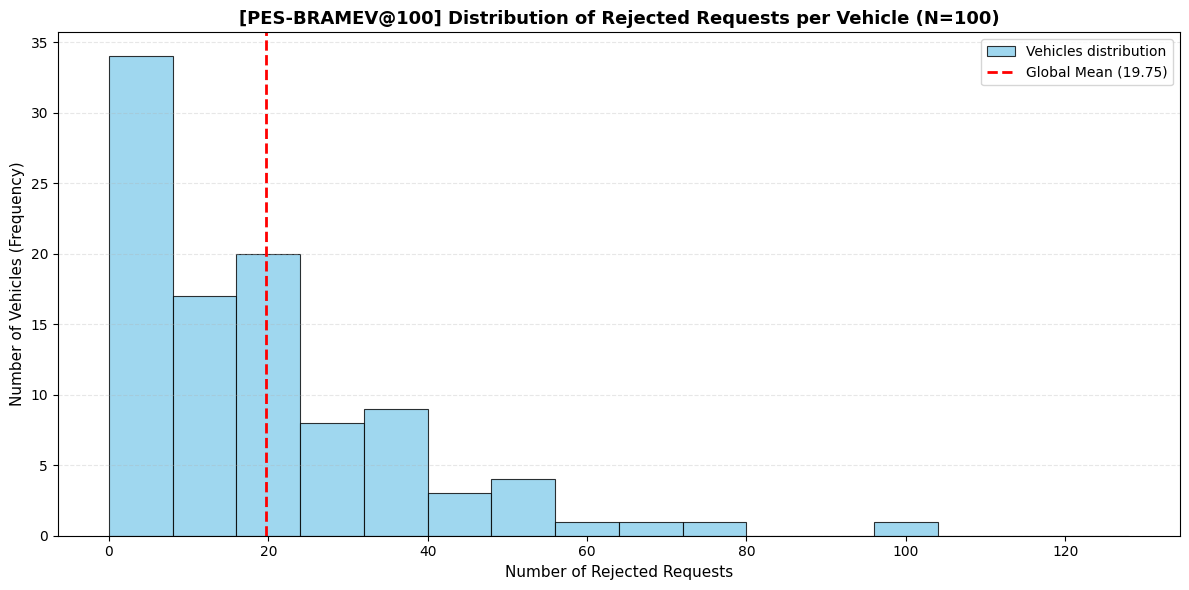

In [89]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

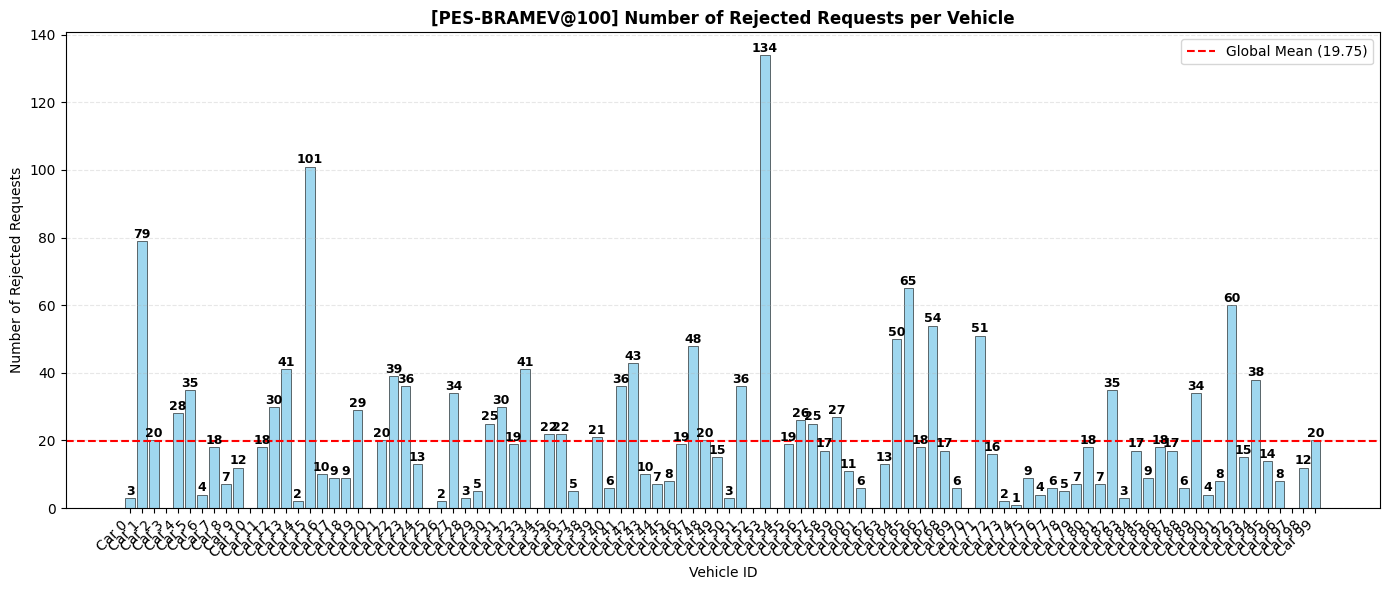

In [90]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

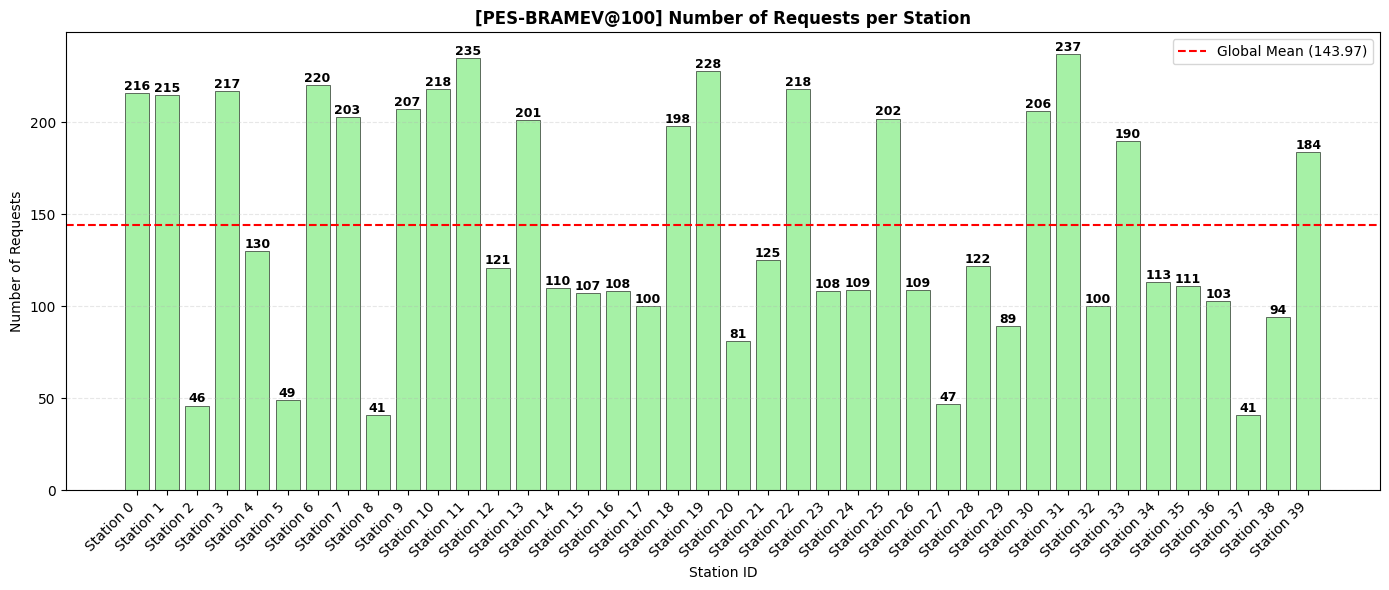

In [91]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [92]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

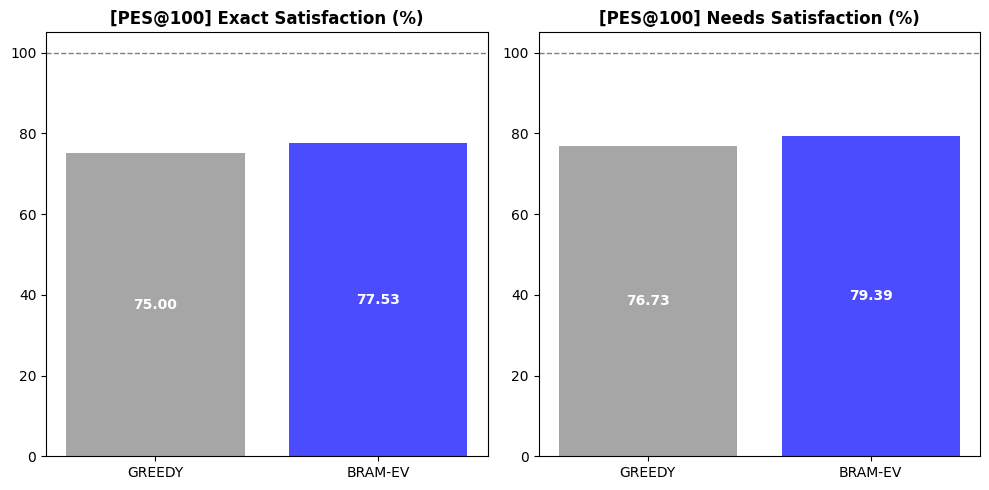

In [93]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

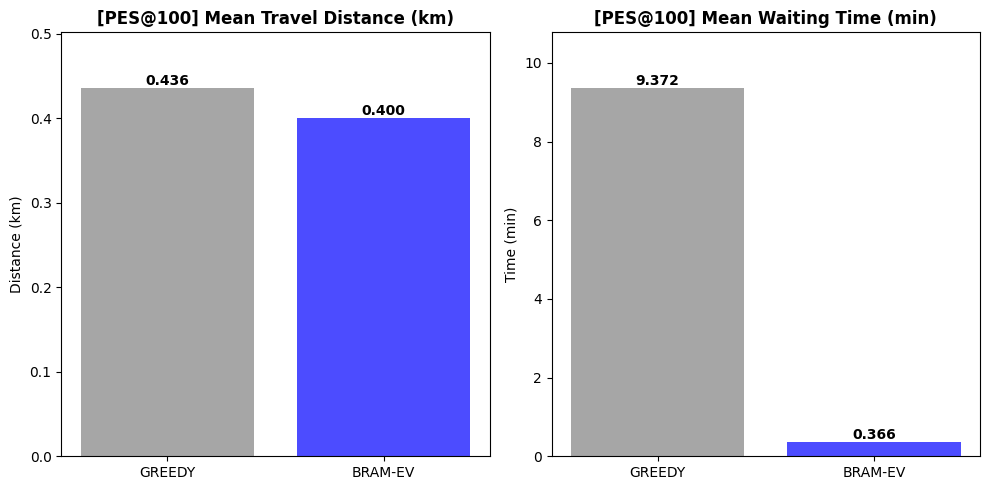

In [94]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

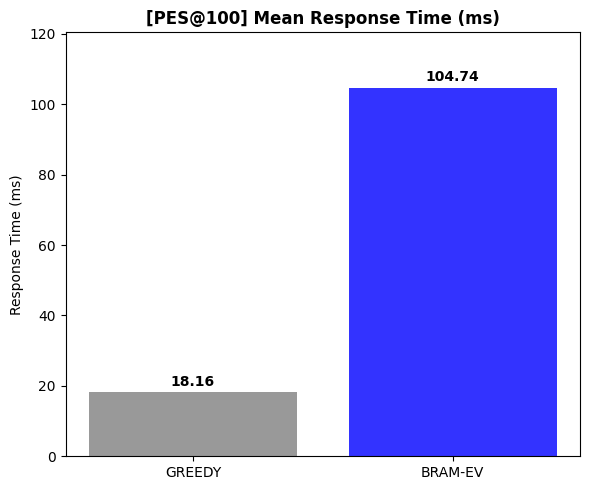

In [95]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [96]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [97]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/150cars


##### *Initialisation*

In [98]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [99]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:14:10.811 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:14:10.956 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:14:11.345 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:14:11.652 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:14:11.764 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:14:11.982 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:14:12.274 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:14:12.580 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:14:12.937 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:14:13.032 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:14:13.333 | IN

##### *Metrics*

In [100]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.56 kWh
  Station 1: 4.77 kWh
  Station 2: 43.17 kWh
  Station 3: 15.53 kWh
  Station 4: 13.28 kWh
  Station 5: 16.22 kWh
  Station 6: 3.55 kWh
  Station 7: 7.97 kWh
  Station 8: 6.56 kWh
  Station 9: 23.89 kWh
  Station 10: 78.63 kWh
  Station 11: 4.67 kWh
  Station 12: 5.67 kWh
  Station 13: 78.94 kWh
  Station 14: 16.20 kWh
  Station 15: 43.79 kWh
  Station 16: 54.28 kWh
  Station 17: 190.53 kWh
  Station 18: 38.71 kWh
  Station 19: 176.04 kWh
  Station 20: 17.14 kWh
  Station 21: 179.64 kWh
  Station 22: 219.55 kWh
  Station 23: 49.30 kWh
  Station 24: 3.19 kWh
  Station 25: 39.42 kWh
  Station 26: 4.83 kWh
  Station 27: 47.16 kWh
  Station 28: 5.02 kWh
  Station 29: 6.07 kWh
  Station 30: 3.13 kWh
  Station 31: 44.62 kWh
  Station 32: 1.60 kWh
  Station 33: 7.62 kWh
  Station 34: 6.22 kWh
  Station 35: 71.33 kWh
  Station 36: 5.28 kWh
  Station 37: 18.77 kWh
  Station 38: 7.92 kWh
  Station 39: 6.25 kWh


In [101]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

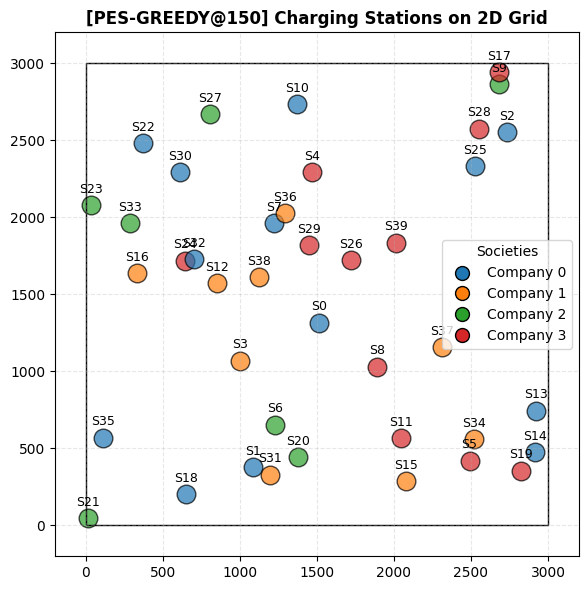

In [102]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

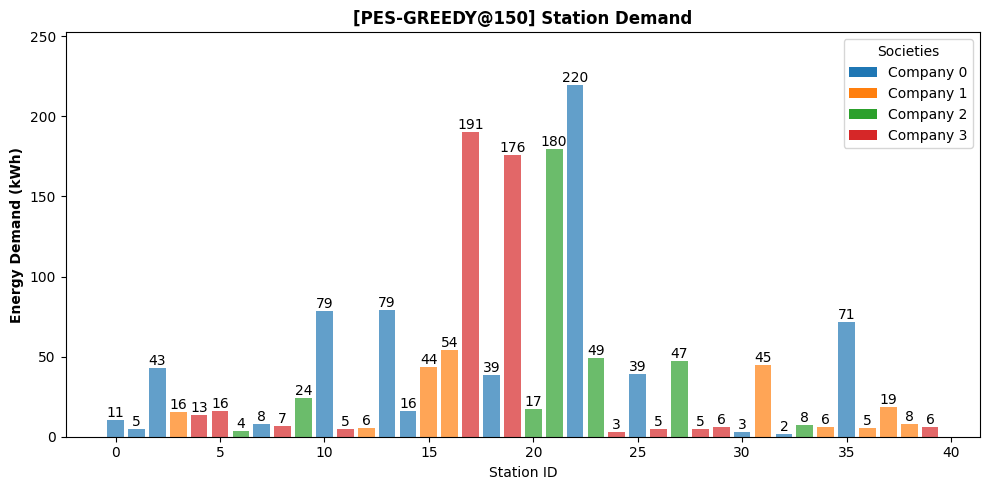

In [103]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

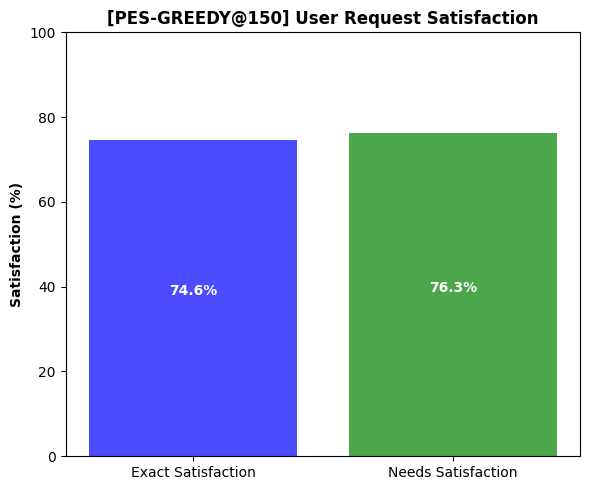

In [104]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

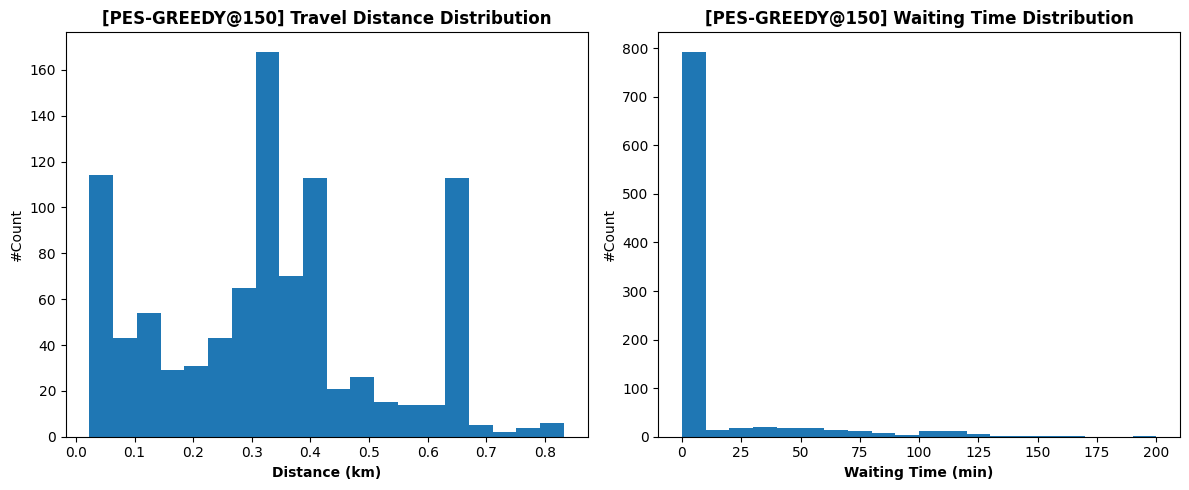

In [105]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

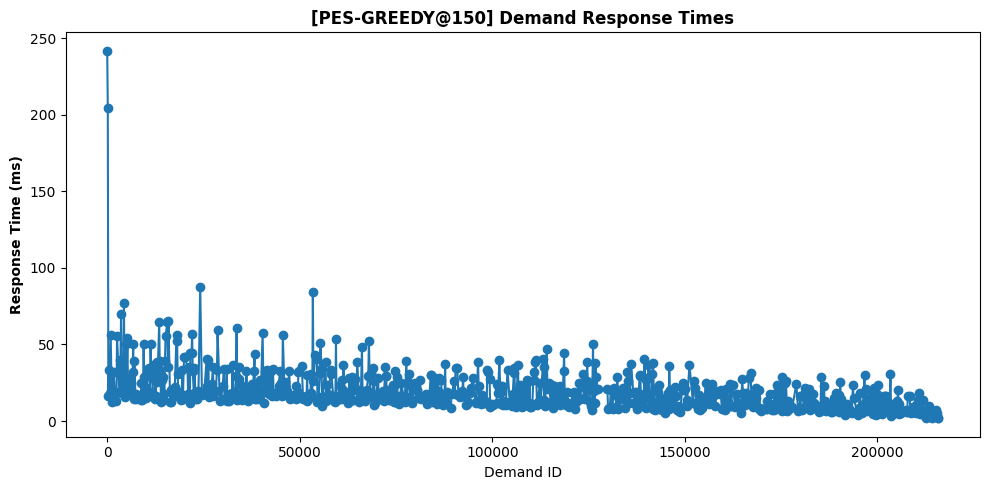

In [106]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

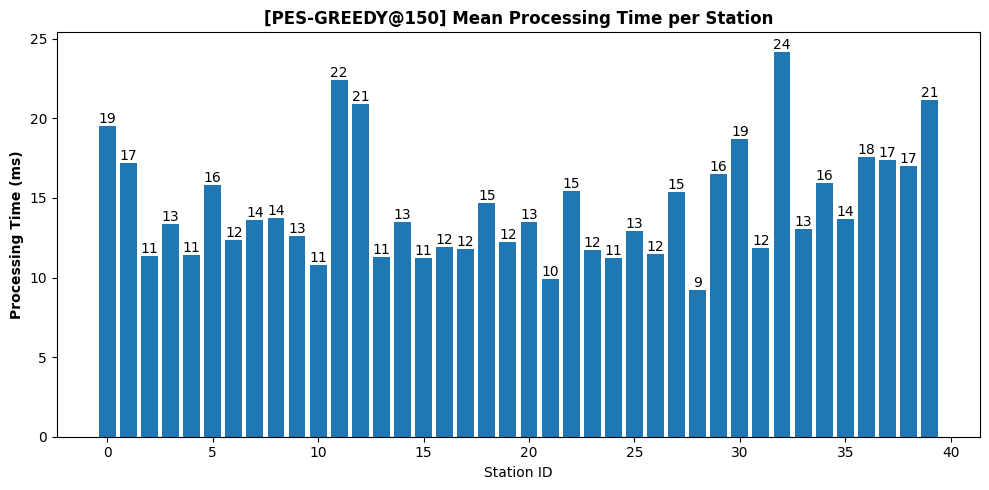

In [107]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [108]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.160417  0.015972  0.000000  0.000000  0.000000   
1            0           1  0.091667  0.000000  0.000000  0.000000  0.000000   
2            0           2  0.374306  0.142361  0.000000  0.131944       NaN   
3            0           7  0.107639  0.000000  0.000000  0.000000  0.000000   
4            0          10  0.481250  0.309028  0.134722  0.247222       NaN   
5            0          13  0.534722  0.325694  0.115972  0.218750       NaN   
6            0          14  0.173611  0.075694  0.000000  0.000000       NaN   
7            0          18  0.397222  0.156250  0.000000  0.029167  0.022917   
8            0          22  0.671528  0.662500  0.519444  0.472222  0.486111   
9            0          25  0.298611  0.220139  0.028472  0.059028       NaN   
10           0          30  0.065278  0.000000  0.000000  0.000000  0.000000   
11           0          32  0.033333  0.

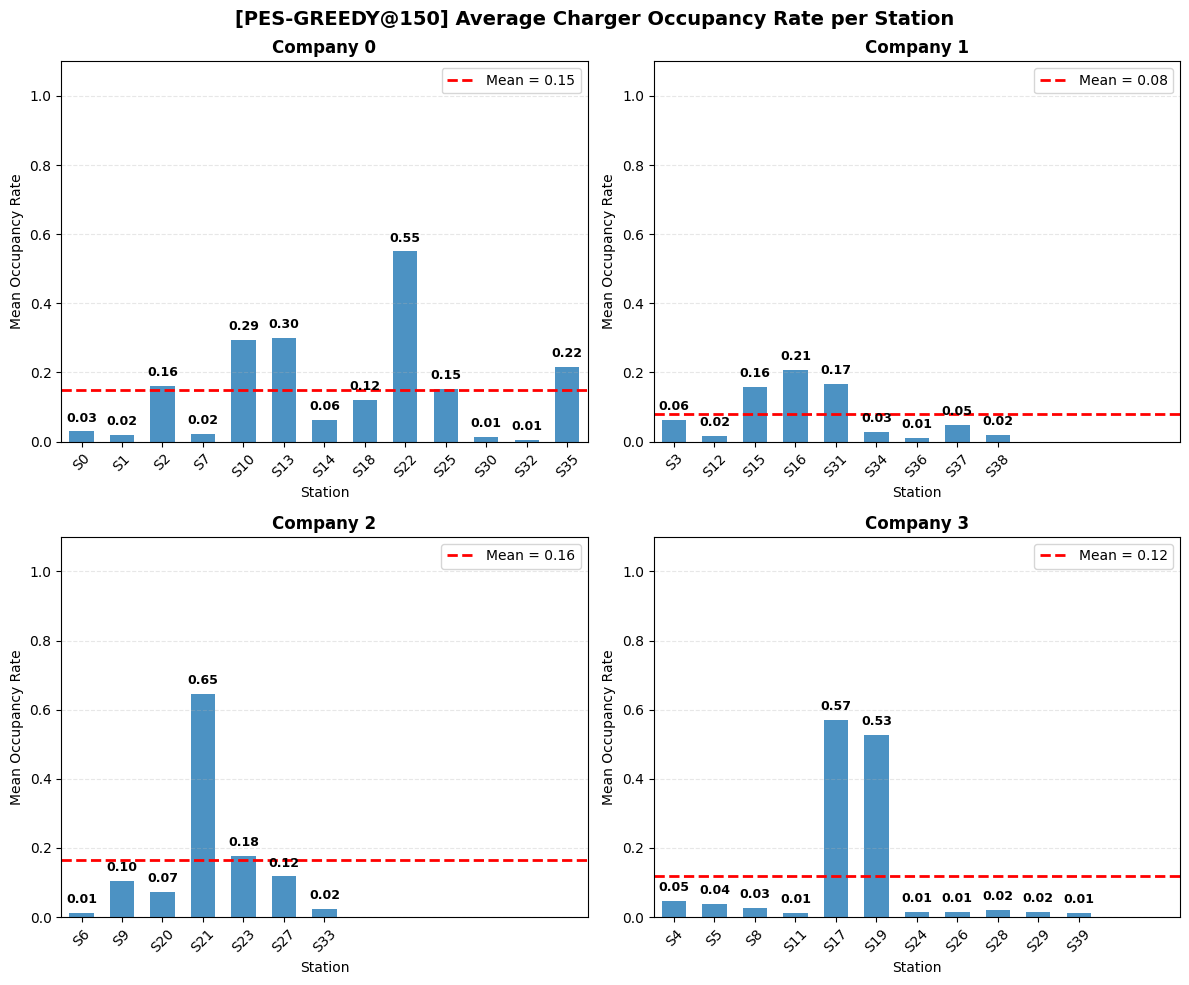

In [109]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

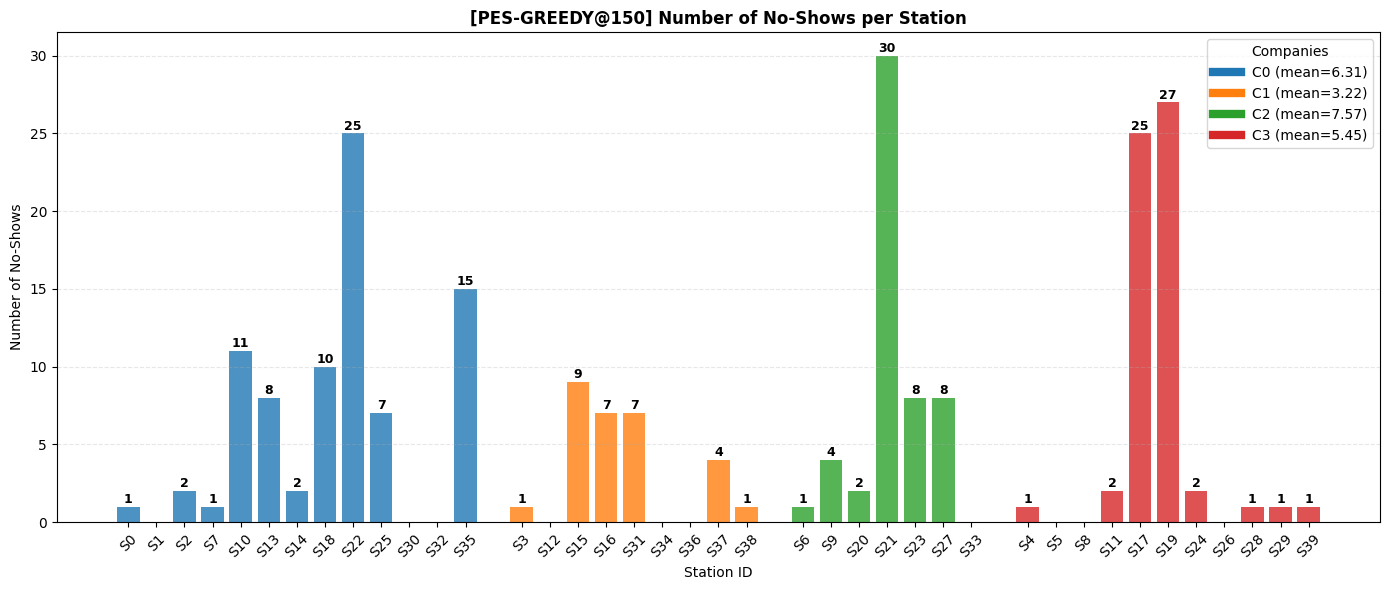

In [110]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [111]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,7,6,1,0,0,0.857143,0.142857,0.000000,0.000000
1,0,1,3,3,0,0,0,1.000000,0.000000,0.000000,0.000000
2,0,2,26,24,2,0,0,0.923077,0.076923,0.000000,0.000000
3,0,7,6,5,1,0,0,0.833333,0.166667,0.000000,0.000000
4,0,10,57,46,11,0,0,0.807018,0.192982,0.000000,0.000000
5,0,13,55,46,8,0,0,0.836364,0.145455,0.000000,0.000000
6,0,14,11,9,2,0,0,0.818182,0.181818,0.000000,0.000000
7,0,18,33,22,10,0,0,0.666667,0.303030,0.000000,0.000000
8,0,22,160,130,25,0,0,0.812500,0.156250,0.000000,0.000000
9,0,25,28,21,7,0,0,0.750000,0.250000,0.000000,0.000000


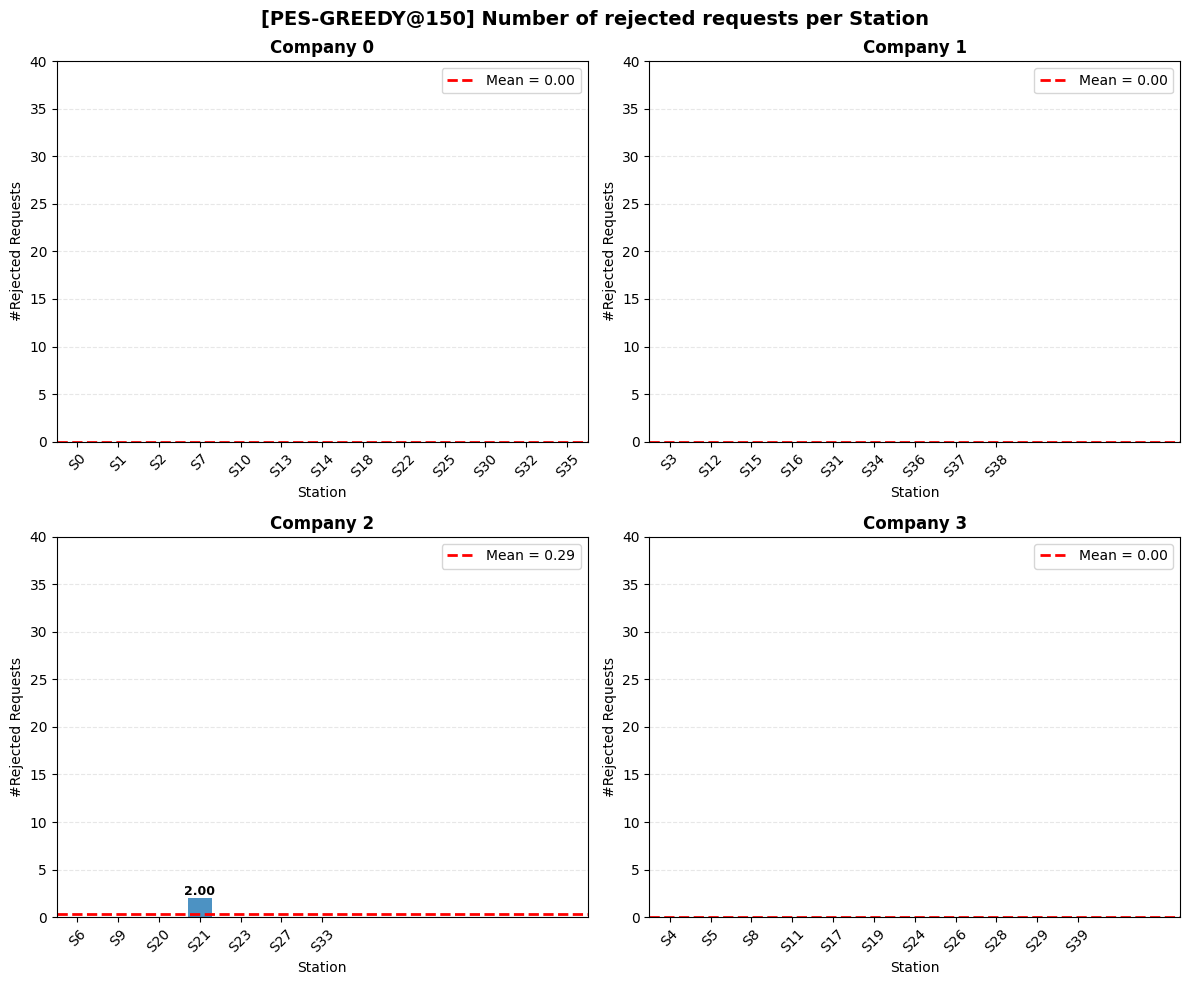

In [112]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [113]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [114]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [115]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:14:33.533 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:14:35.490 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:14:36.795 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:14:38.729 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:14:39.727 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:14:41.775 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:14:42.773 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:14:44.134 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:14:45.710 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:14:47.036 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:14:48.932 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [116]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 199.50 kWh
  Station 1: 10.22 kWh
  Station 2: 55.64 kWh
  Station 3: 9.49 kWh
  Station 4: 60.87 kWh
  Station 5: 6.63 kWh
  Station 6: 101.09 kWh
  Station 7: 14.93 kWh
  Station 8: 61.51 kWh
  Station 9: 81.47 kWh
  Station 10: 25.94 kWh
  Station 11: 37.81 kWh
  Station 12: 3.43 kWh
  Station 13: 26.93 kWh
  Station 14: 3.15 kWh
  Station 15: 0.00 kWh
  Station 16: 57.61 kWh
  Station 17: 11.40 kWh
  Station 18: 15.84 kWh
  Station 19: 6.07 kWh
  Station 20: 7.65 kWh
  Station 21: 11.86 kWh
  Station 22: 10.14 kWh
  Station 23: 161.91 kWh
  Station 24: 163.55 kWh
  Station 25: 37.93 kWh
  Station 26: 46.27 kWh
  Station 27: 29.25 kWh
  Station 28: 140.33 kWh
  Station 29: 72.88 kWh
  Station 30: 8.65 kWh
  Station 31: 47.77 kWh
  Station 32: 8.30 kWh
  Station 33: 15.03 kWh
  Station 34: 8.06 kWh
  Station 35: 21.75 kWh
  Station 36: 0.00 kWh
  Station 37: 4.78 kWh
  Station 38: 14.40 kWh
  Station 39: 10.5

In [117]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

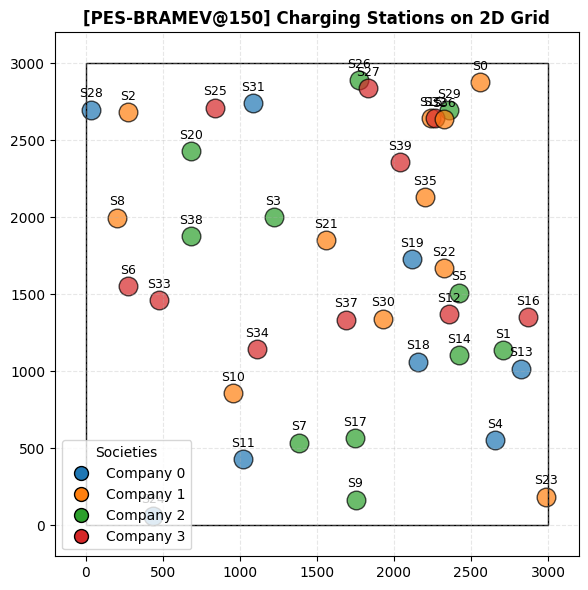

In [118]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

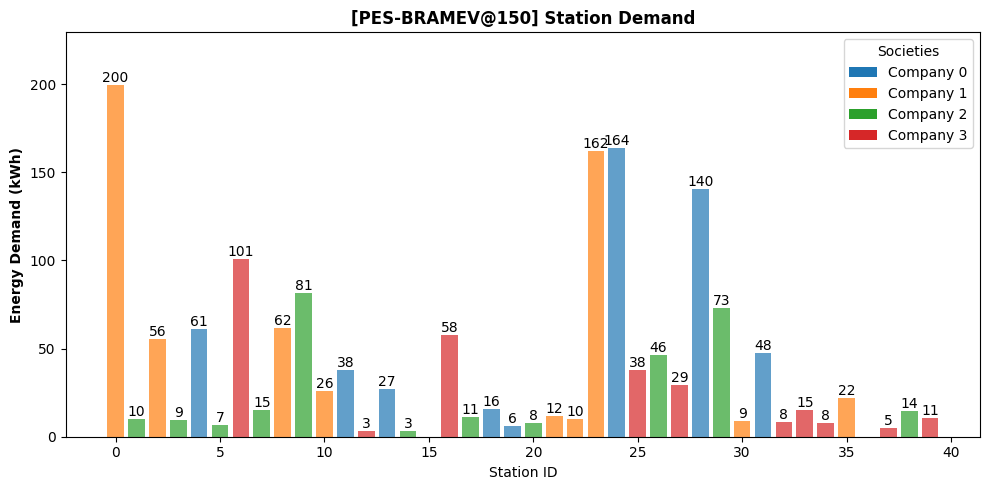

In [119]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

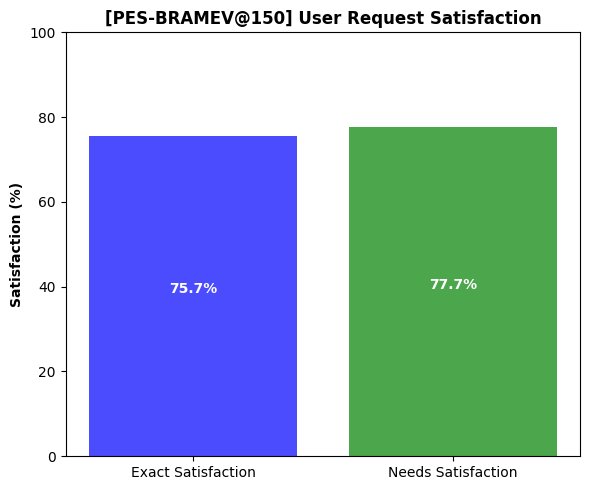

In [120]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

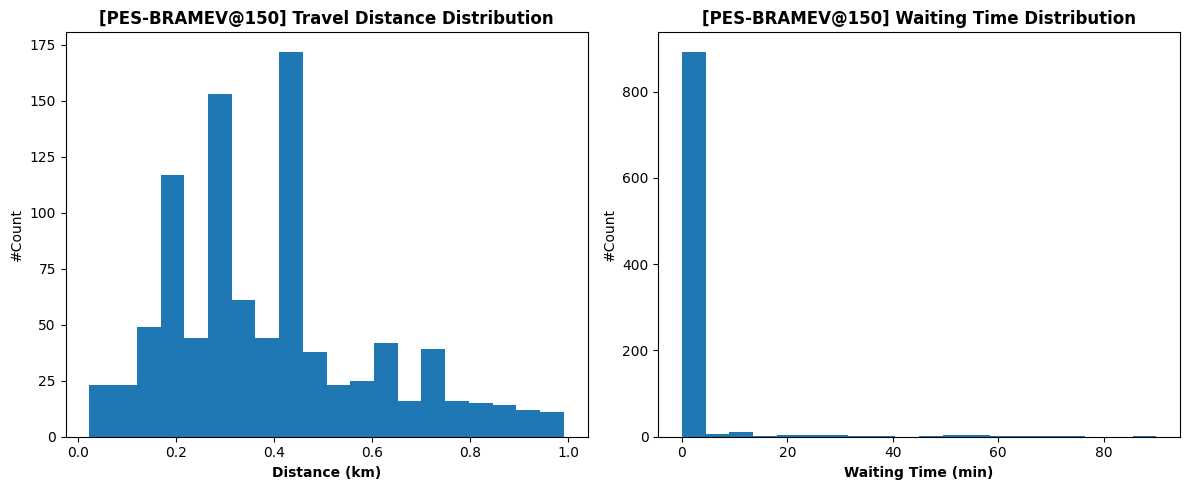

In [121]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

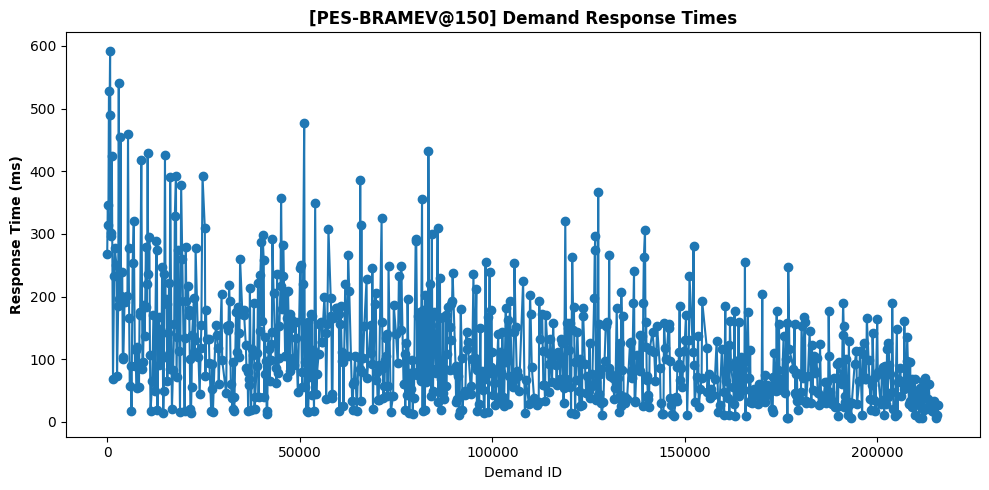

In [122]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

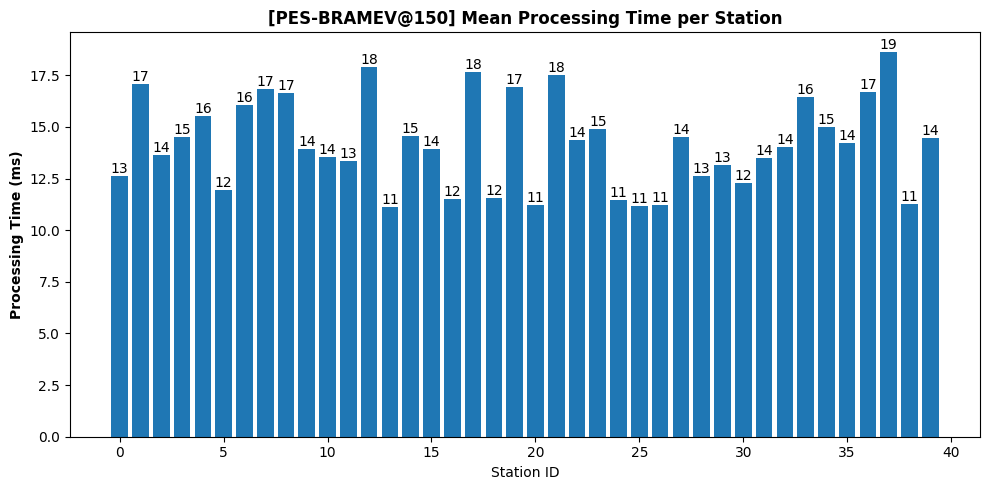

In [123]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

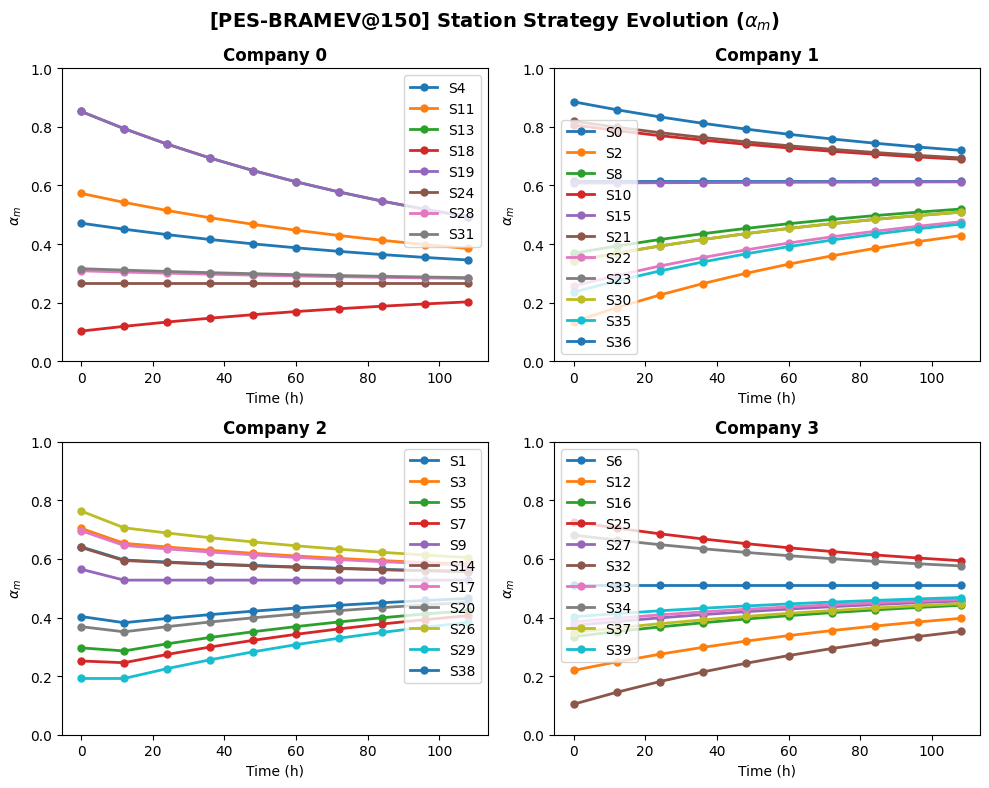

In [124]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [125]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.319444  0.310417  0.081944  0.027083  0.018750   
1            0          11  0.298611  0.050694  0.070139  0.027083  0.070139   
2            0          13  0.170833  0.116667  0.043056  0.068056       NaN   
3            0          18  0.168056  0.059722  0.000000  0.000000       NaN   
4            0          19  0.079861  0.000000  0.000000  0.000000  0.000000   
5            0          24  0.606944  0.509028  0.442361  0.284028  0.338194   
6            0          28  0.710417  0.563889  0.260417  0.193056  0.279167   
7            0          31  0.455556  0.213194  0.000000  0.000000  0.000000   
8            1           0  0.650694  0.779167  0.486111  0.412500  0.533333   
9            1           2  0.416667  0.283333  0.032639  0.023611  0.052083   
10           1           8  0.407639  0.288889  0.015278  0.029861  0.000000   
11           1          10  0.218750  0.

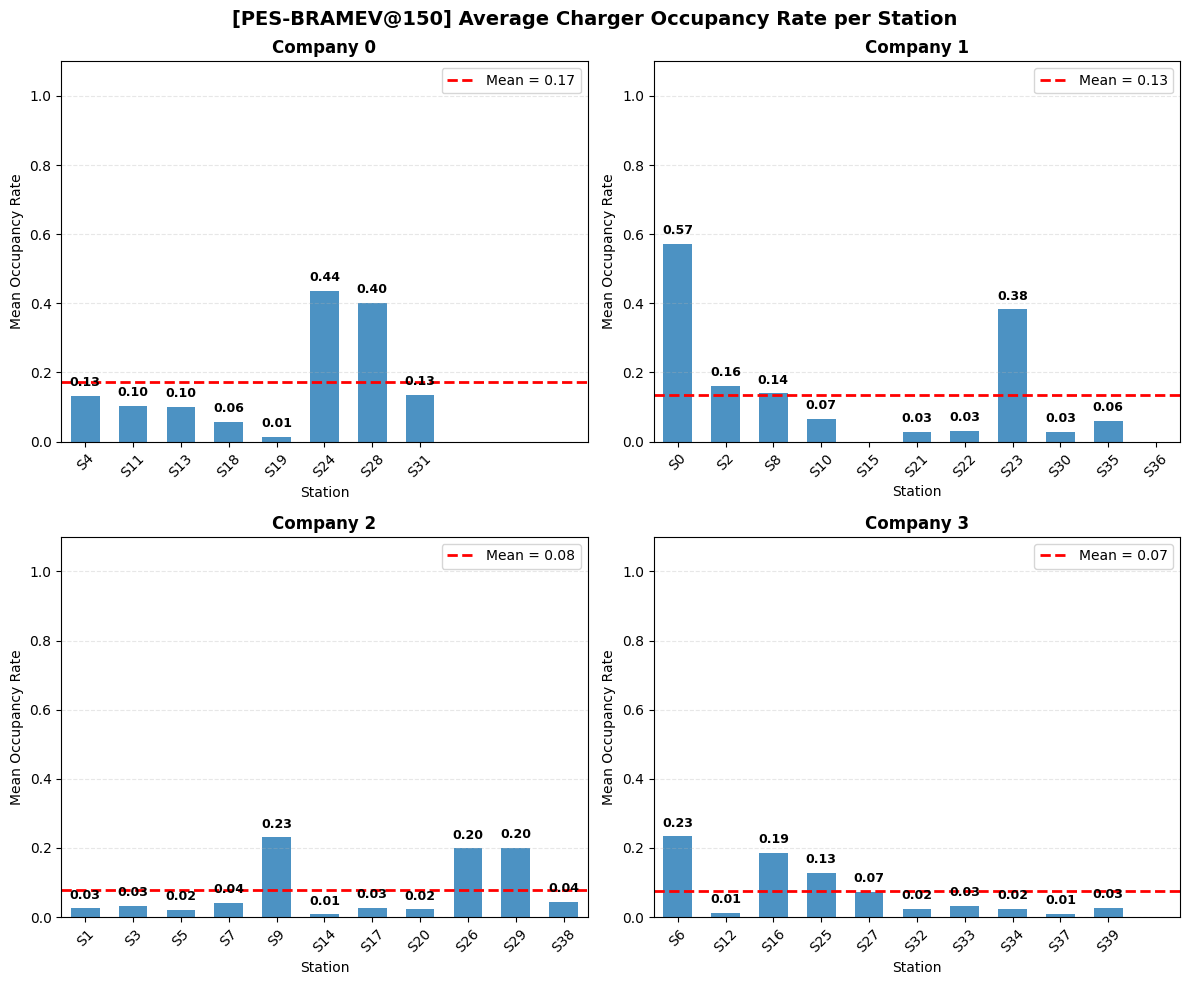

In [126]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

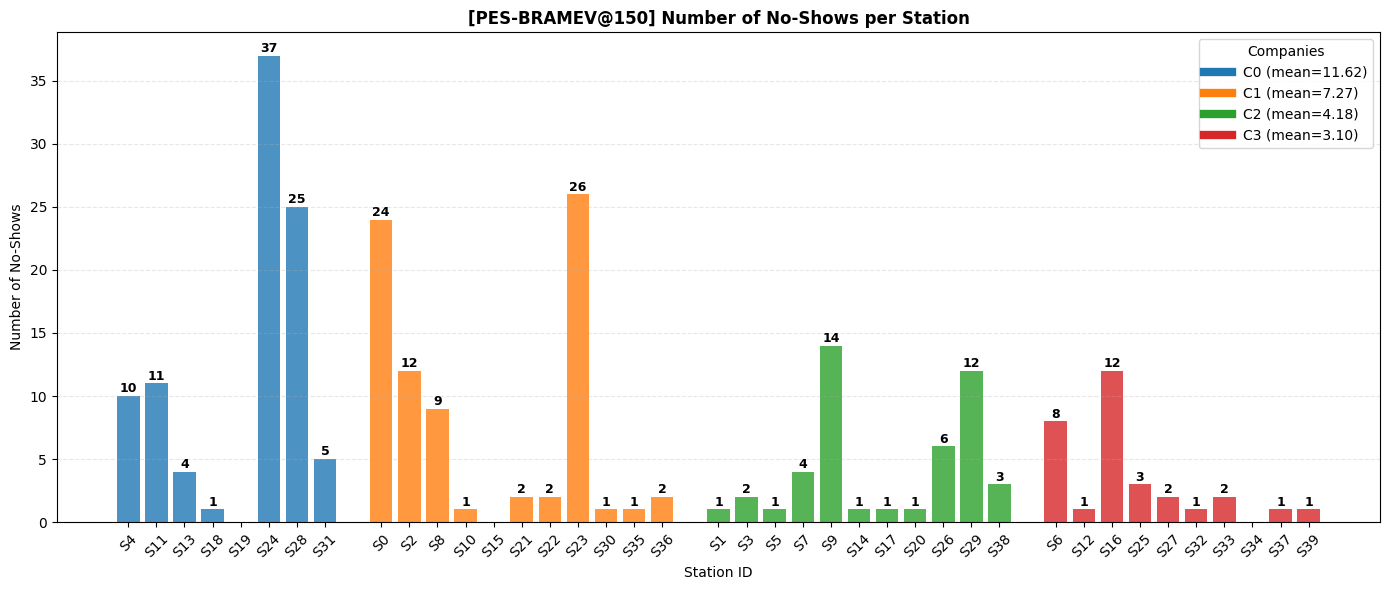

In [127]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [128]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,45,35,10,0,0,0.777778,0.222222,0.0,0.0
1,0,11,34,22,11,0,0,0.647059,0.323529,0.0,0.0
2,0,13,21,16,4,0,0,0.761905,0.190476,0.0,0.0
3,0,18,9,8,1,0,0,0.888889,0.111111,0.0,0.0
4,0,19,3,3,0,0,0,1.000000,0.000000,0.0,0.0
5,0,24,134,96,37,0,0,0.716418,0.276119,0.0,0.0
6,0,28,110,84,25,0,0,0.763636,0.227273,0.0,0.0
7,0,31,33,28,5,0,0,0.848485,0.151515,0.0,0.0
8,1,0,142,117,24,0,0,0.823944,0.169014,0.0,0.0
9,1,2,46,32,12,0,0,0.695652,0.260870,0.0,0.0


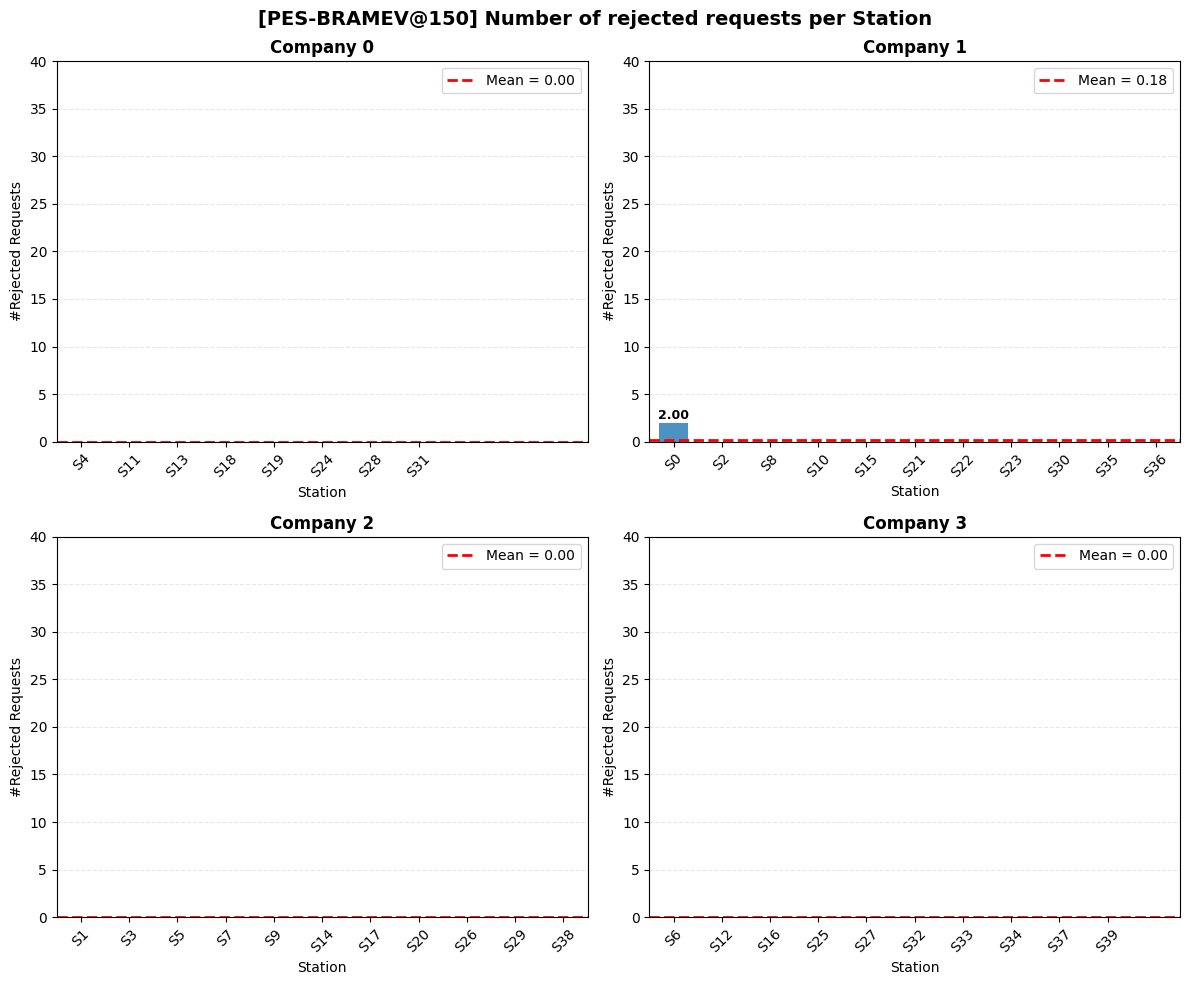

In [129]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

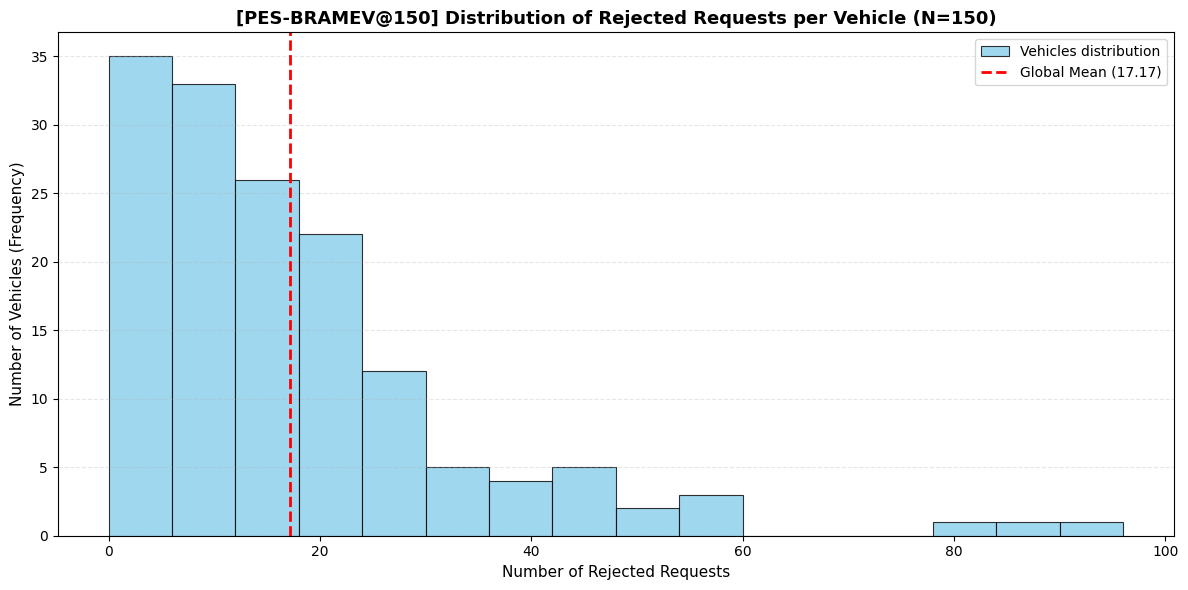

In [130]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

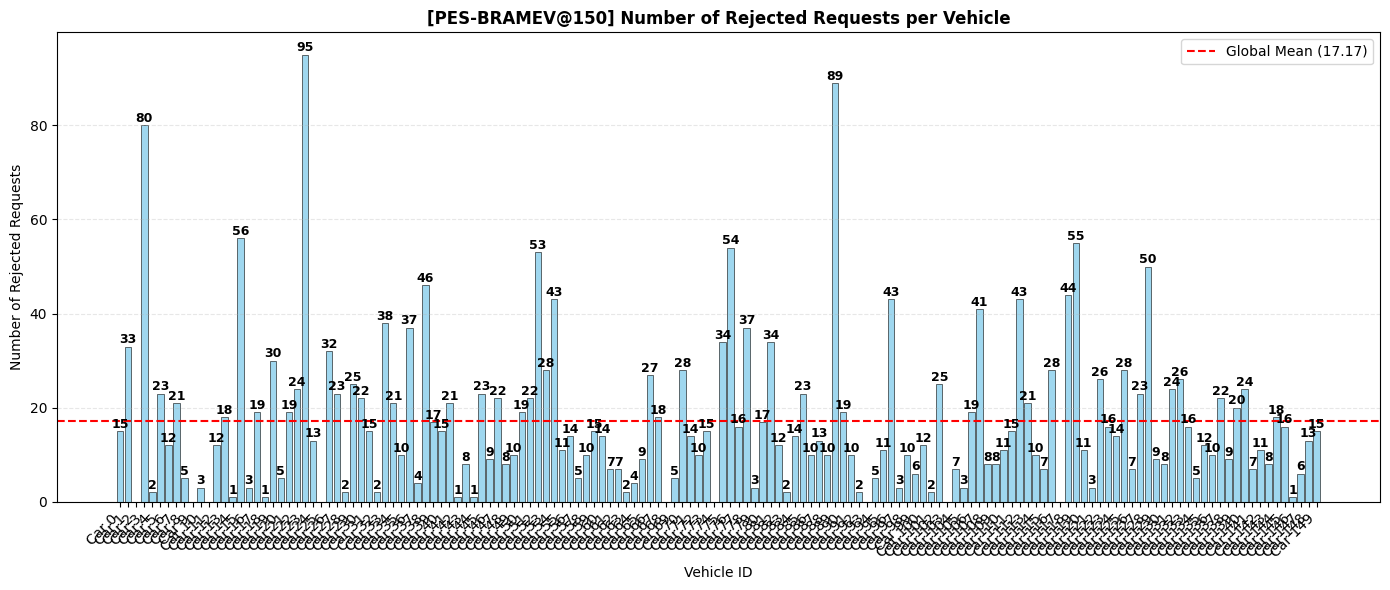

In [131]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

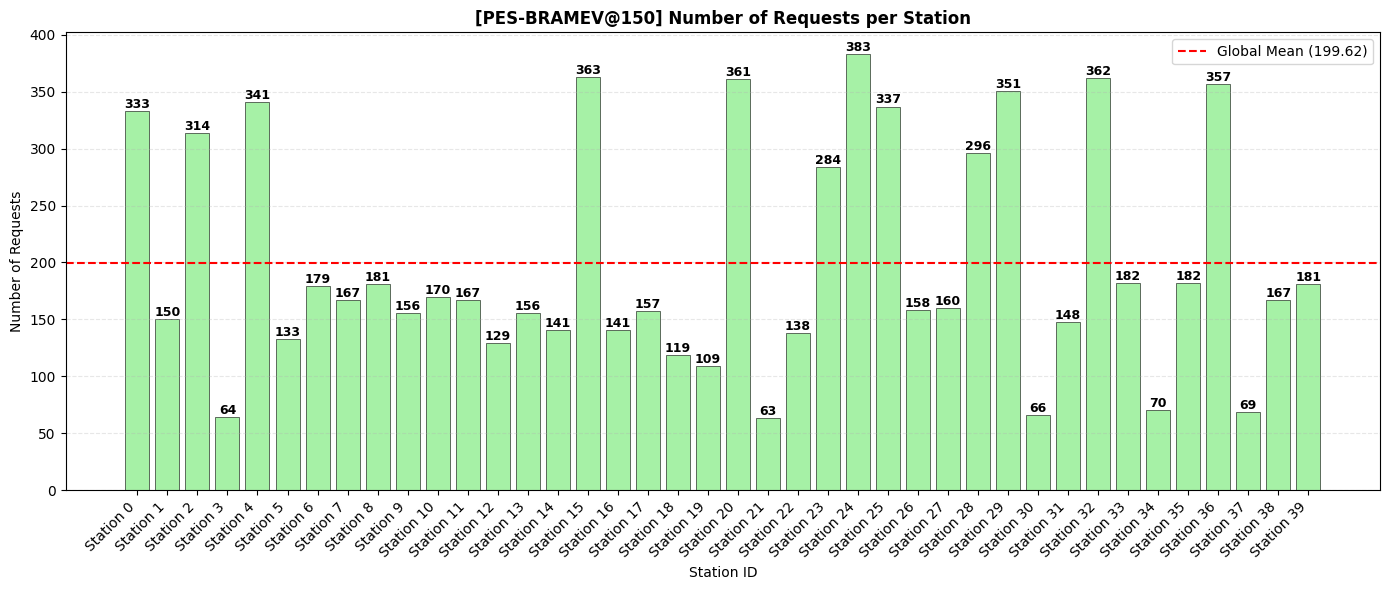

In [132]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [133]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

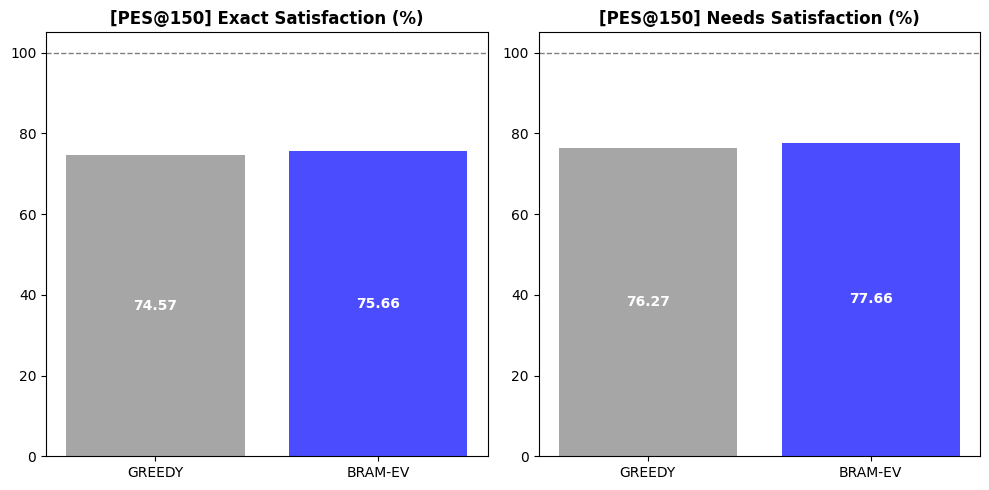

In [134]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

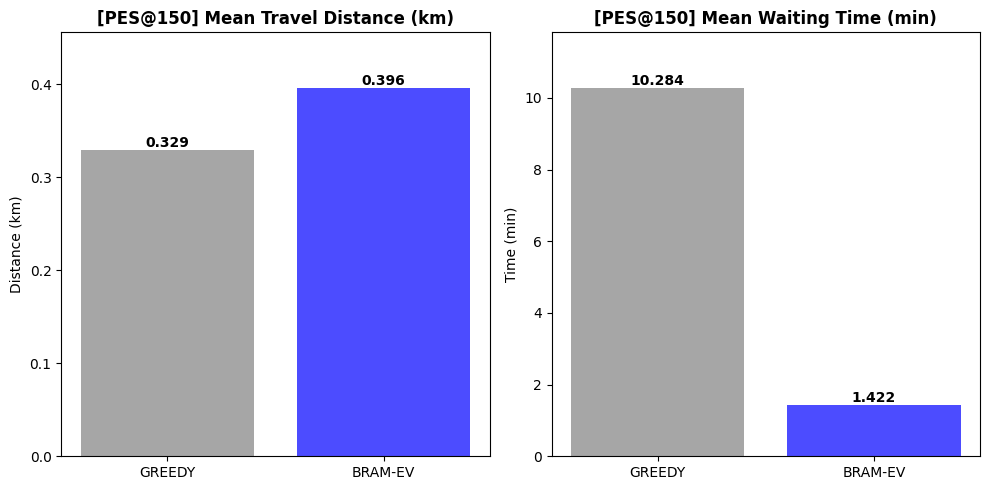

In [135]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

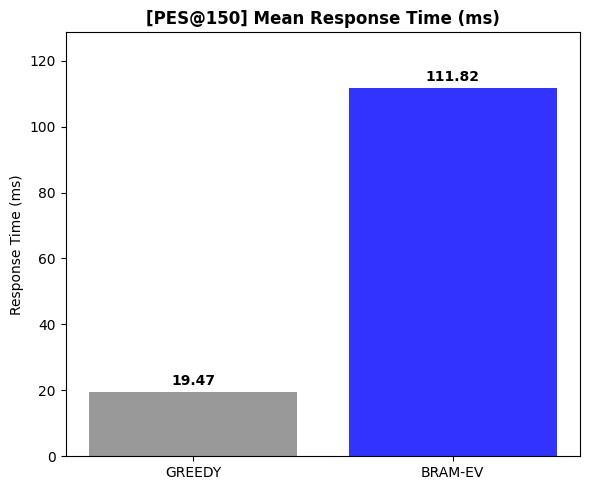

In [136]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [137]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [138]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [139]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [140]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:16:13.112 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:16:13.424 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:16:13.835 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:16:14.252 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:16:14.636 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:16:14.985 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:16:15.405 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:16:15.704 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:16:15.946 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:16:16.219 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:16:16.632 | IN

##### *Metrics*

In [141]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 6.37 kWh
  Station 1: 68.12 kWh
  Station 2: 64.67 kWh
  Station 3: 70.38 kWh
  Station 4: 286.05 kWh
  Station 5: 18.81 kWh
  Station 6: 8.91 kWh
  Station 7: 71.81 kWh
  Station 8: 6.68 kWh
  Station 9: 93.47 kWh
  Station 10: 3.54 kWh
  Station 11: 7.08 kWh
  Station 12: 4.74 kWh
  Station 13: 13.66 kWh
  Station 14: 71.95 kWh
  Station 15: 90.51 kWh
  Station 16: 74.33 kWh
  Station 17: 4.78 kWh
  Station 18: 54.03 kWh
  Station 19: 6.38 kWh
  Station 20: 5.23 kWh
  Station 21: 11.16 kWh
  Station 22: 21.02 kWh
  Station 23: 11.10 kWh
  Station 24: 214.84 kWh
  Station 25: 5.22 kWh
  Station 26: 11.92 kWh
  Station 27: 10.97 kWh
  Station 28: 8.11 kWh
  Station 29: 16.01 kWh
  Station 30: 9.22 kWh
  Station 31: 2.67 kWh
  Station 32: 231.66 kWh
  Station 33: 83.78 kWh
  Station 34: 79.17 kWh
  Station 35: 205.86 kWh
  Station 36: 6.77 kWh
  Station 37: 31.53 kWh
  Station 38: 19.77 kWh
  Station 39: 91.05 k

In [142]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

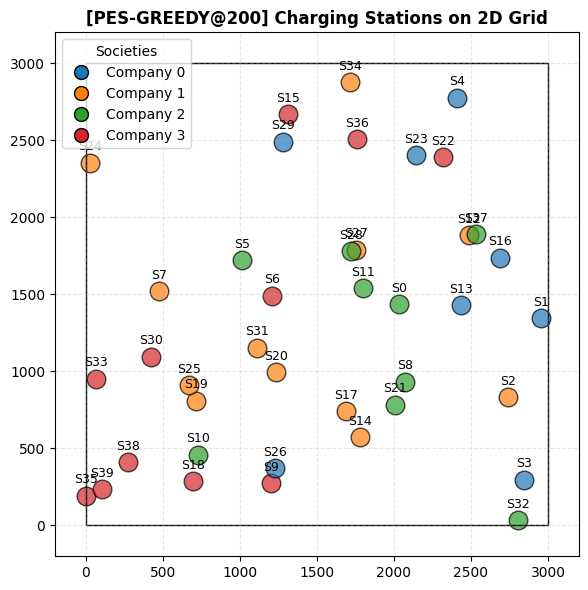

In [143]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

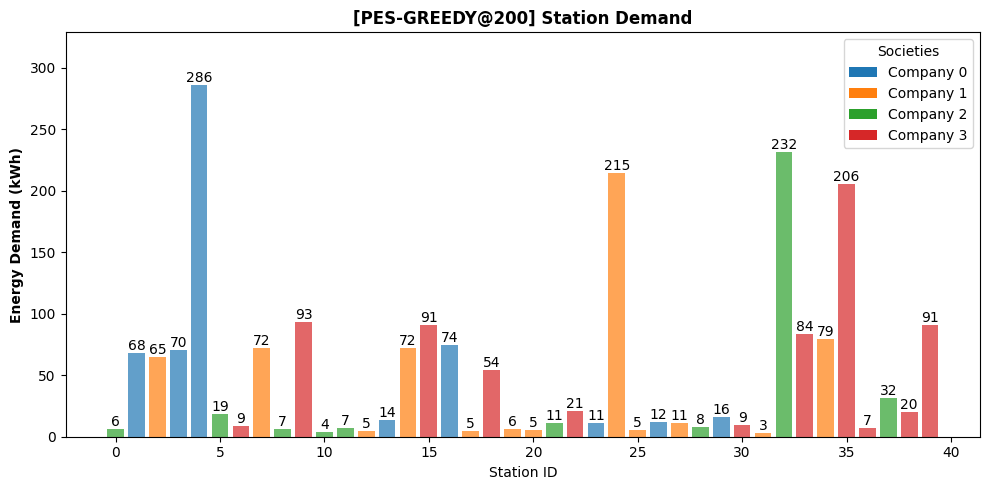

In [144]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

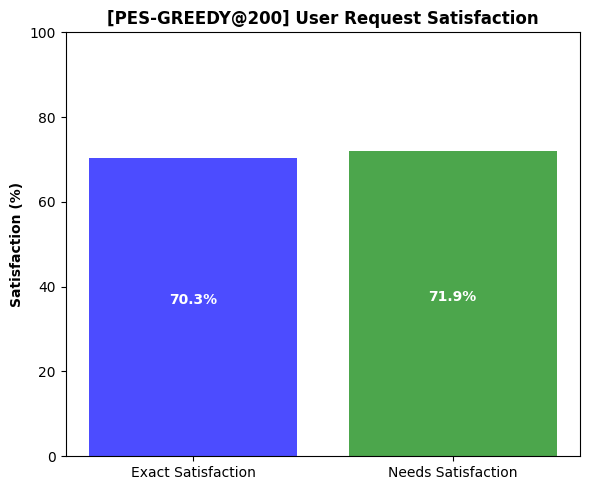

In [145]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

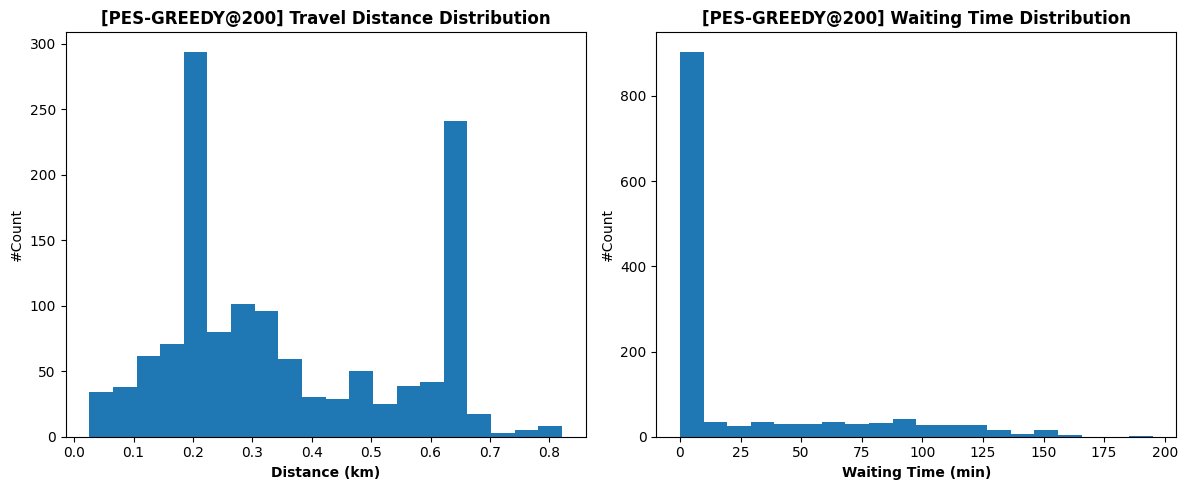

In [146]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

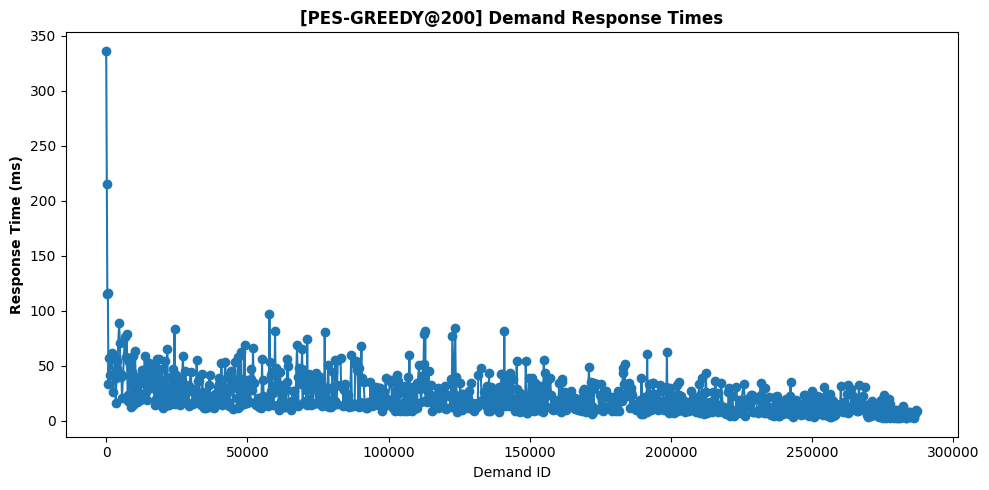

In [147]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

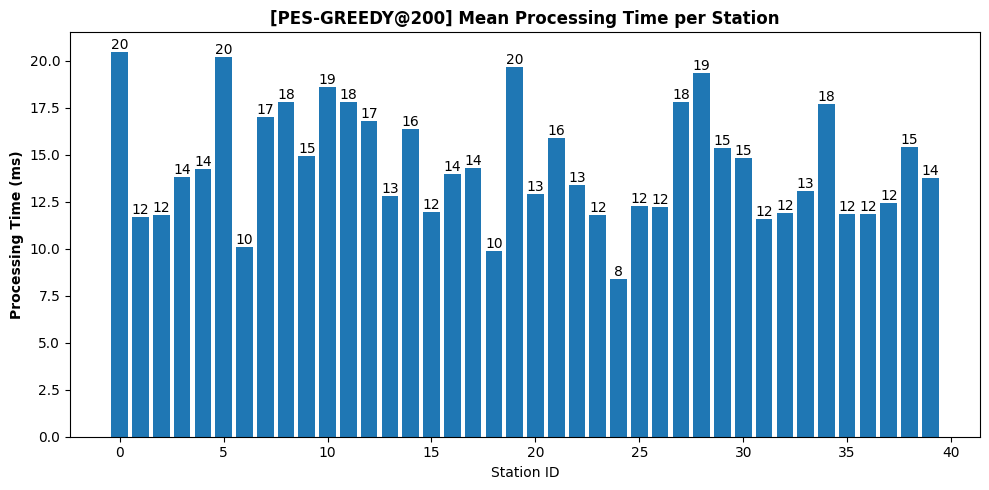

In [148]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [149]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.444444  0.343056  0.119444  0.100694       NaN   
1            0           3  0.543056  0.303472  0.040278  0.062500  0.137500   
2            0           4  0.664583  0.805556  0.657639  0.547917  0.674306   
3            0          13  0.165278  0.032639  0.000000  0.000000       NaN   
4            0          16  0.545833  0.360417  0.052778  0.029167  0.090972   
5            0          23  0.120833  0.050694  0.000000  0.000000       NaN   
6            0          26  0.141667  0.000000  0.000000  0.000000       NaN   
7            0          29  0.153472  0.058333  0.016667  0.000000  0.000000   
8            1           2  0.425000  0.275694  0.064583  0.132639       NaN   
9            1           7  0.577083  0.286806  0.092361  0.000000  0.000000   
10           1          12  0.064583  0.000000  0.000000  0.000000  0.000000   
11           1          14  0.464583  0.

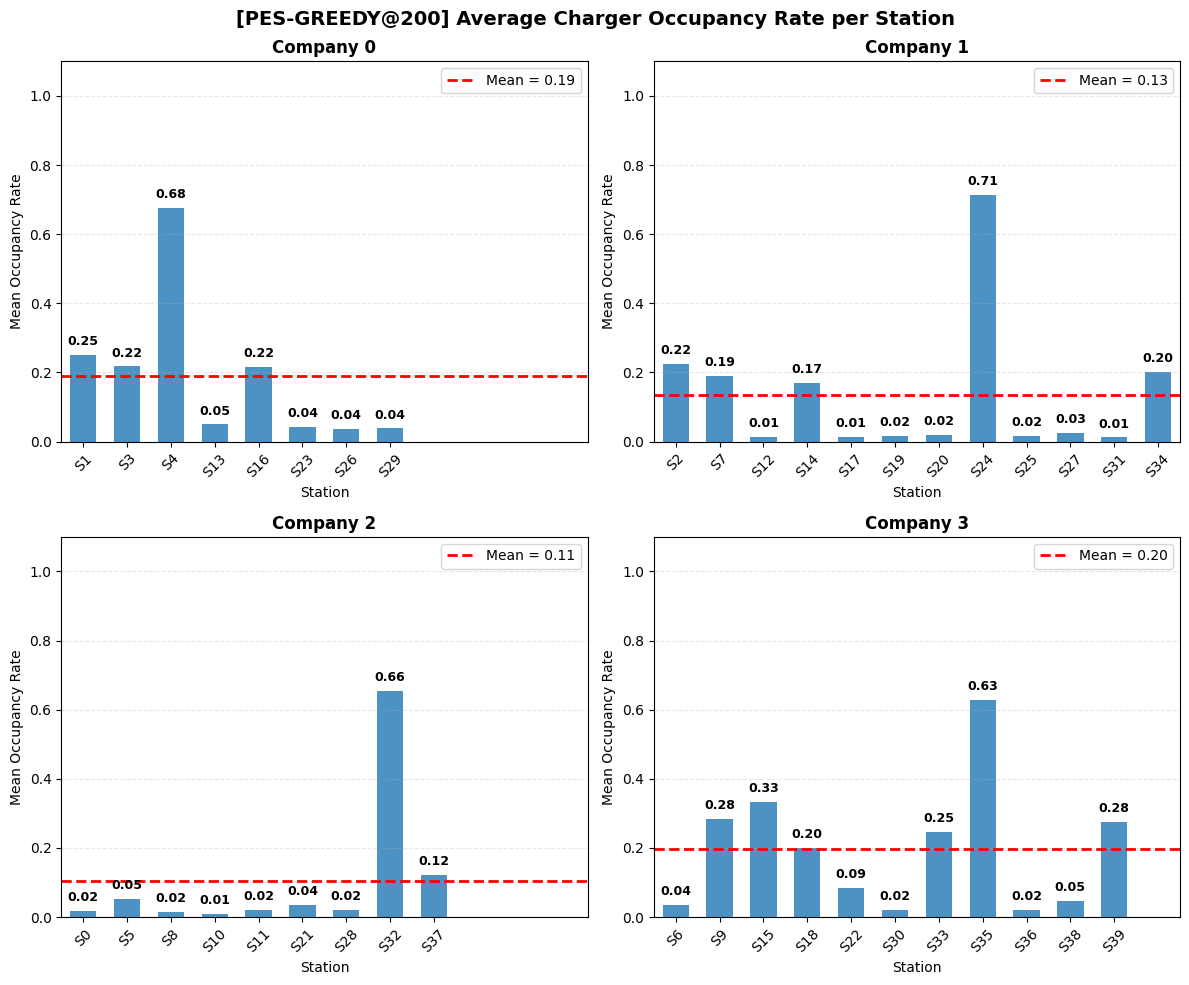

In [150]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

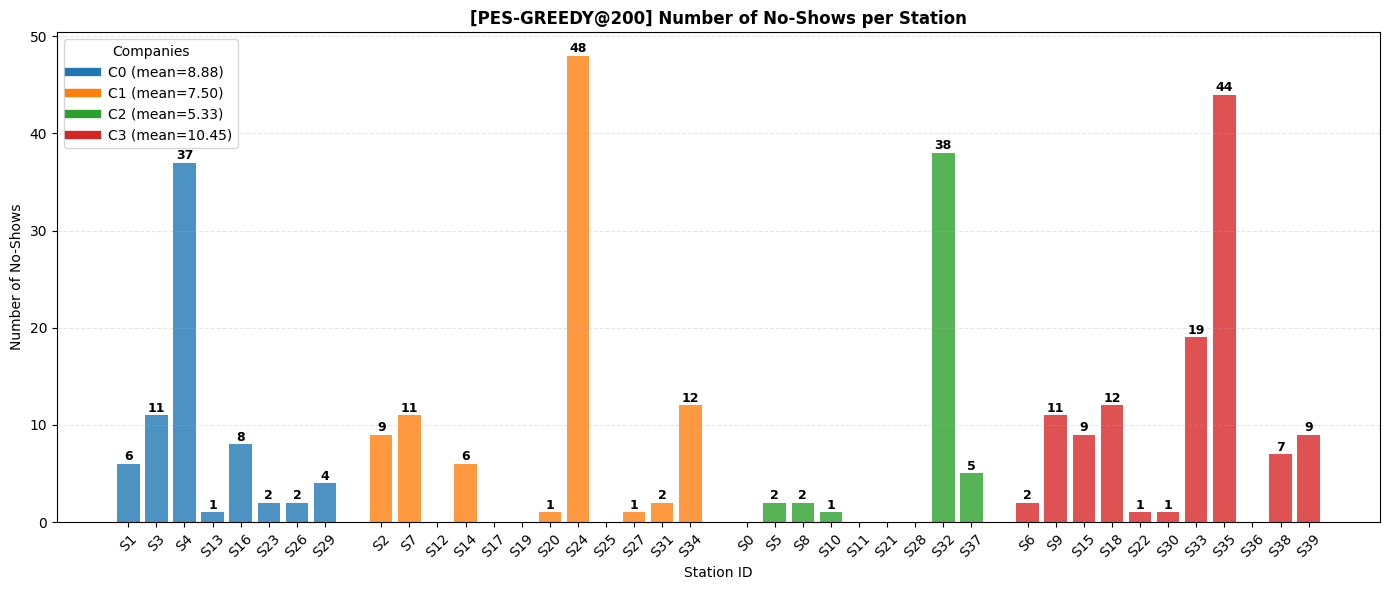

In [151]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [152]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,46,39,6,0,0,0.847826,0.130435,0.000000,0.000000
1,0,3,52,41,11,0,0,0.788462,0.211538,0.000000,0.000000
2,0,4,218,177,37,0,1,0.811927,0.169725,0.000000,0.004587
3,0,13,8,7,1,0,0,0.875000,0.125000,0.000000,0.000000
4,0,16,48,40,8,0,0,0.833333,0.166667,0.000000,0.000000
5,0,23,8,6,2,0,0,0.750000,0.250000,0.000000,0.000000
6,0,26,8,6,2,0,0,0.750000,0.250000,0.000000,0.000000
7,0,29,14,9,4,0,0,0.642857,0.285714,0.000000,0.000000
8,1,2,46,37,9,0,0,0.804348,0.195652,0.000000,0.000000
9,1,7,50,38,11,0,0,0.760000,0.220000,0.000000,0.000000


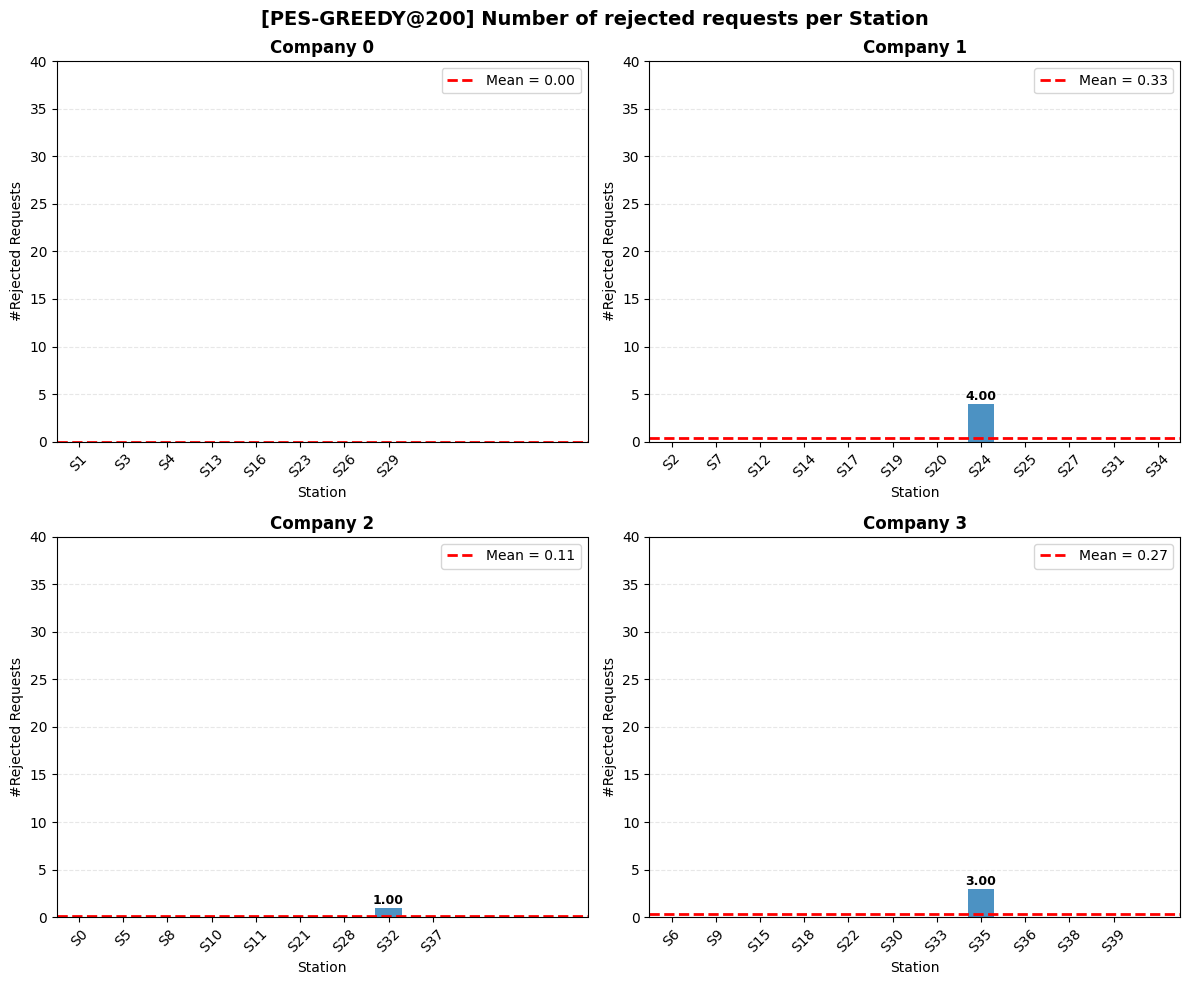

In [153]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [154]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [155]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [156]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:16:45.894 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:16:47.695 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:16:48.924 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:16:50.836 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:16:53.081 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:16:54.244 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:16:56.345 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:16:58.044 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:17:00.432 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:17:01.261 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:17:02.936 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [157]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 47.37 kWh
  Station 1: 8.92 kWh
  Station 2: 61.38 kWh
  Station 3: 65.83 kWh
  Station 4: 57.23 kWh
  Station 5: 18.05 kWh
  Station 6: 130.78 kWh
  Station 7: 14.02 kWh
  Station 8: 26.84 kWh
  Station 9: 157.42 kWh
  Station 10: 46.59 kWh
  Station 11: 11.76 kWh
  Station 12: 5.71 kWh
  Station 13: 13.78 kWh
  Station 14: 68.33 kWh
  Station 15: 204.47 kWh
  Station 16: 12.01 kWh
  Station 17: 198.79 kWh
  Station 18: 22.39 kWh
  Station 19: 67.25 kWh
  Station 20: 25.21 kWh
  Station 21: 57.82 kWh
  Station 22: 88.45 kWh
  Station 23: 50.42 kWh
  Station 24: 60.24 kWh
  Station 25: 12.78 kWh
  Station 26: 16.53 kWh
  Station 27: 56.48 kWh
  Station 28: 14.59 kWh
  Station 29: 26.44 kWh
  Station 30: 112.80 kWh
  Station 31: 41.51 kWh
  Station 32: 14.46 kWh
  Station 33: 3.00 kWh
  Station 34: 133.28 kWh
  Station 35: 73.66 kWh
  Station 36: 98.88 kWh
  Station 37: 13.28 kWh
  Station 38: 10.12 kWh
  Statio

In [158]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

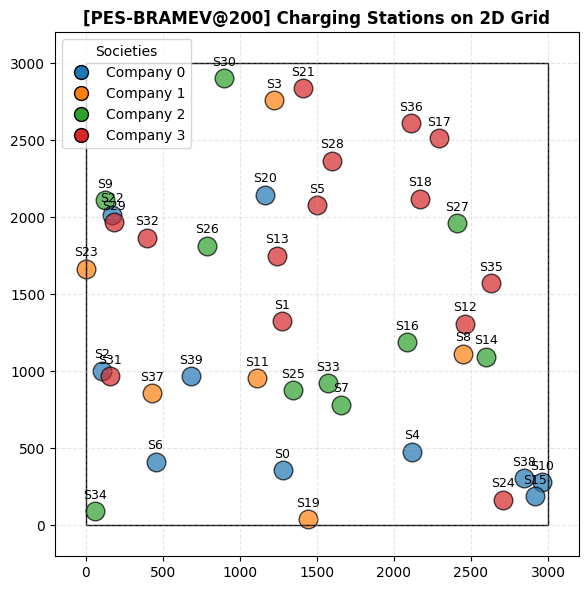

In [159]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

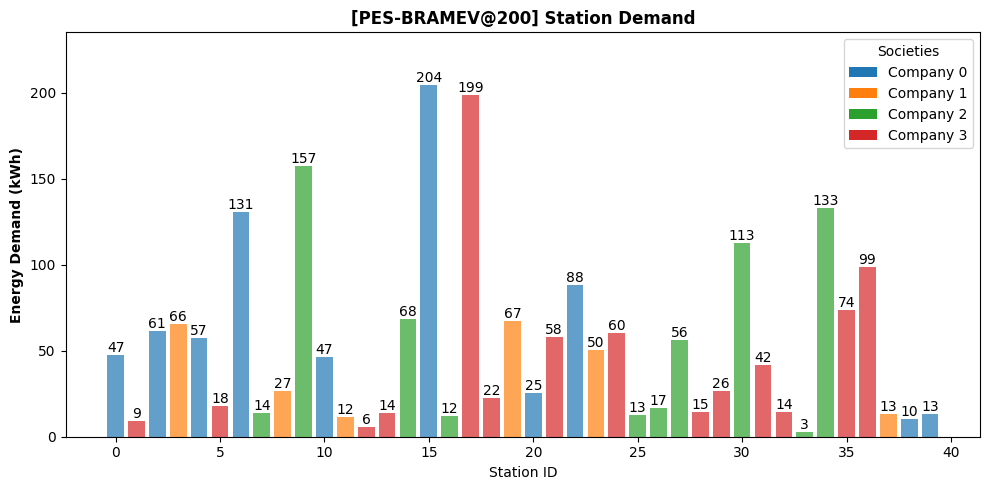

In [160]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

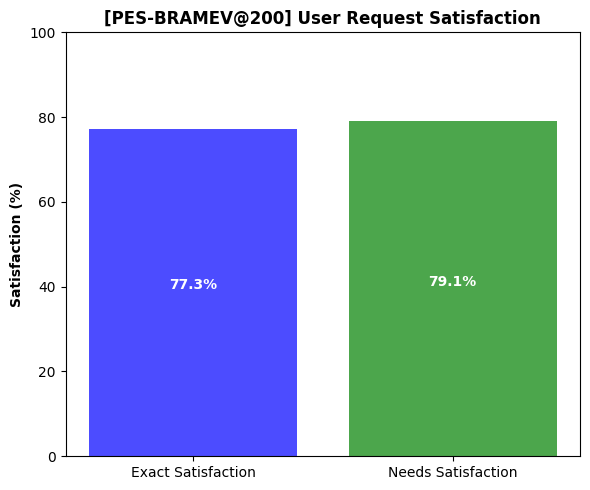

In [161]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

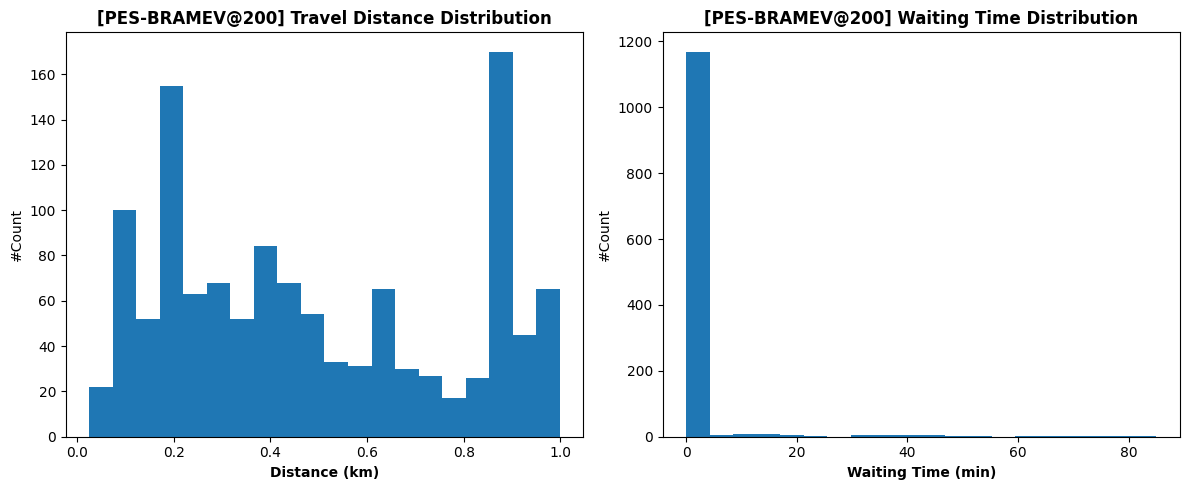

In [162]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

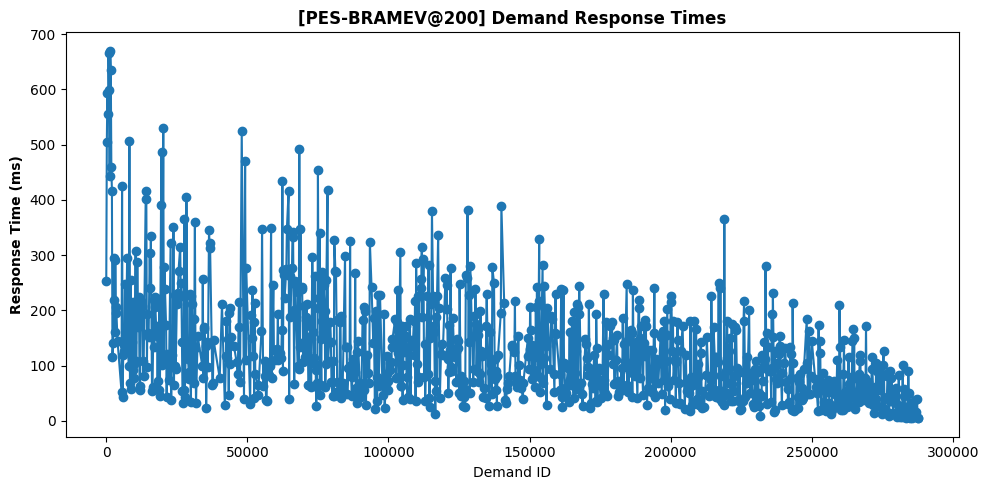

In [163]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

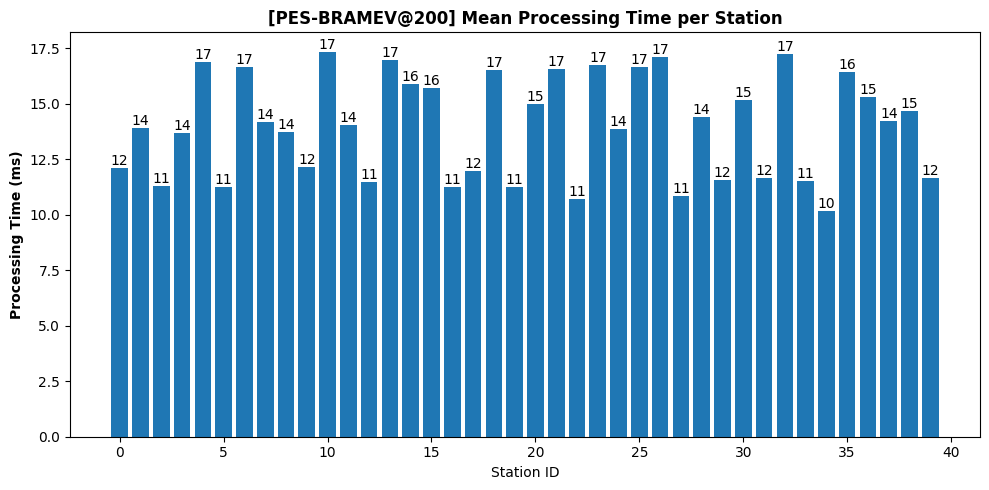

In [164]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

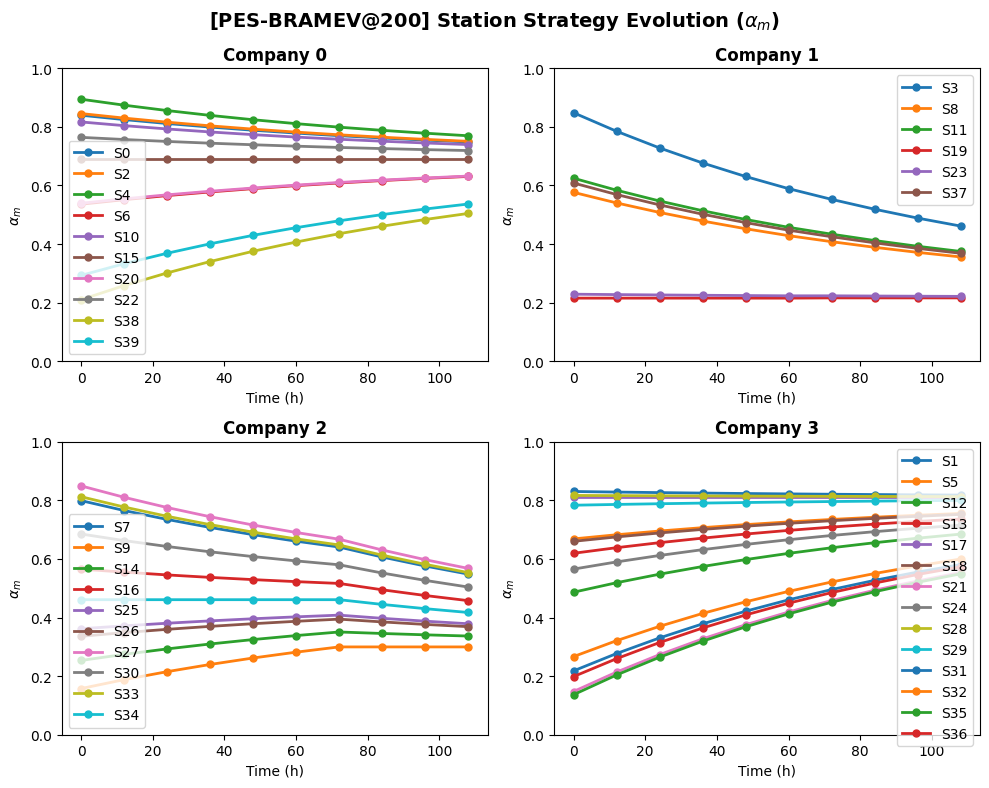

In [165]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [166]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.390278  0.227778  0.050000  0.055556       NaN   
1            0           2  0.460417  0.233333  0.082639  0.156250       NaN   
2            0           4  0.431944  0.320833  0.049306  0.000000  0.019444   
3            0           6  0.467361  0.448611  0.263889  0.183333  0.227778   
4            0          10  0.367361  0.208333  0.088889  0.000000  0.022222   
5            0          15  0.658333  0.653472  0.463194  0.467361  0.365278   
6            0          20  0.263889  0.068056  0.017361  0.000000  0.000000   
7            0          22  0.656250  0.392361  0.131944  0.158333       NaN   
8            0          38  0.099306  0.020139  0.000000  0.000000  0.000000   
9            0          39  0.091667  0.070139  0.000000  0.000000       NaN   
10           1           3  0.382639  0.379167  0.057639  0.050694  0.022222   
11           1           8  0.243056  0.

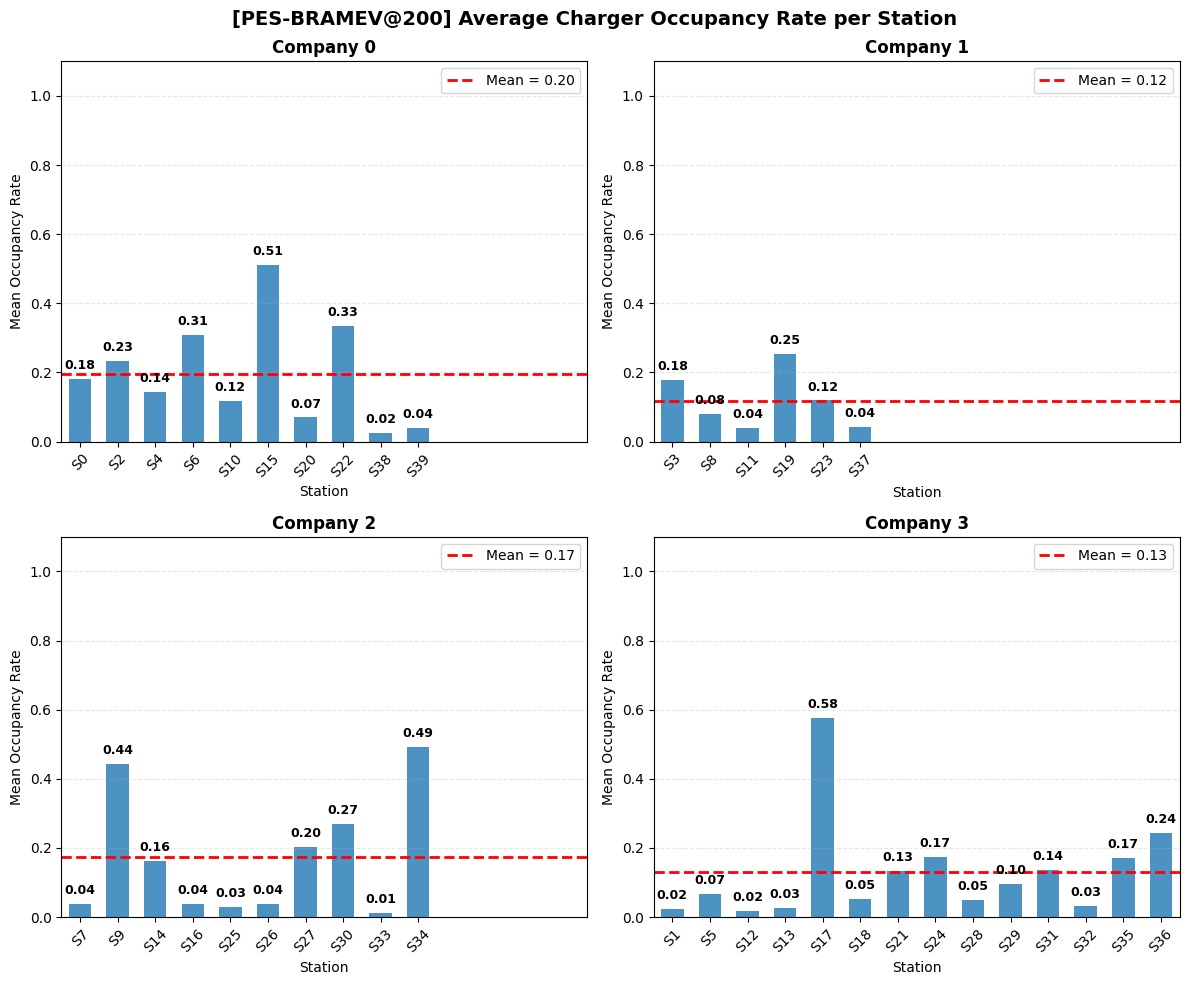

In [167]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

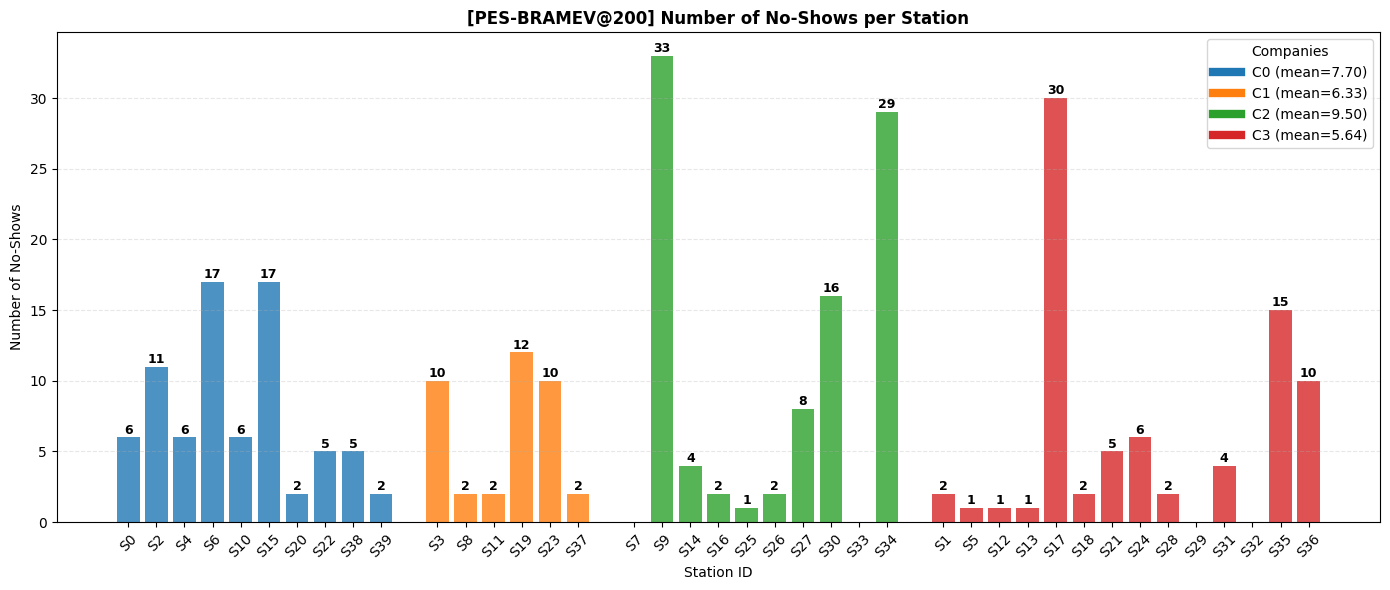

In [168]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [169]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,34,27,6,0,0,0.794118,0.176471,0.0,0.0
1,0,2,45,34,11,0,0,0.755556,0.244444,0.0,0.0
2,0,4,37,31,6,0,0,0.837838,0.162162,0.0,0.0
3,0,6,90,72,17,0,0,0.800000,0.188889,0.0,0.0
4,0,10,32,26,6,0,0,0.812500,0.187500,0.0,0.0
5,0,15,134,114,17,0,0,0.850746,0.126866,0.0,0.0
6,0,20,18,16,2,0,0,0.888889,0.111111,0.0,0.0
7,0,22,55,48,5,0,0,0.872727,0.090909,0.0,0.0
8,0,38,10,5,5,0,0,0.500000,0.500000,0.0,0.0
9,0,39,10,8,2,0,0,0.800000,0.200000,0.0,0.0


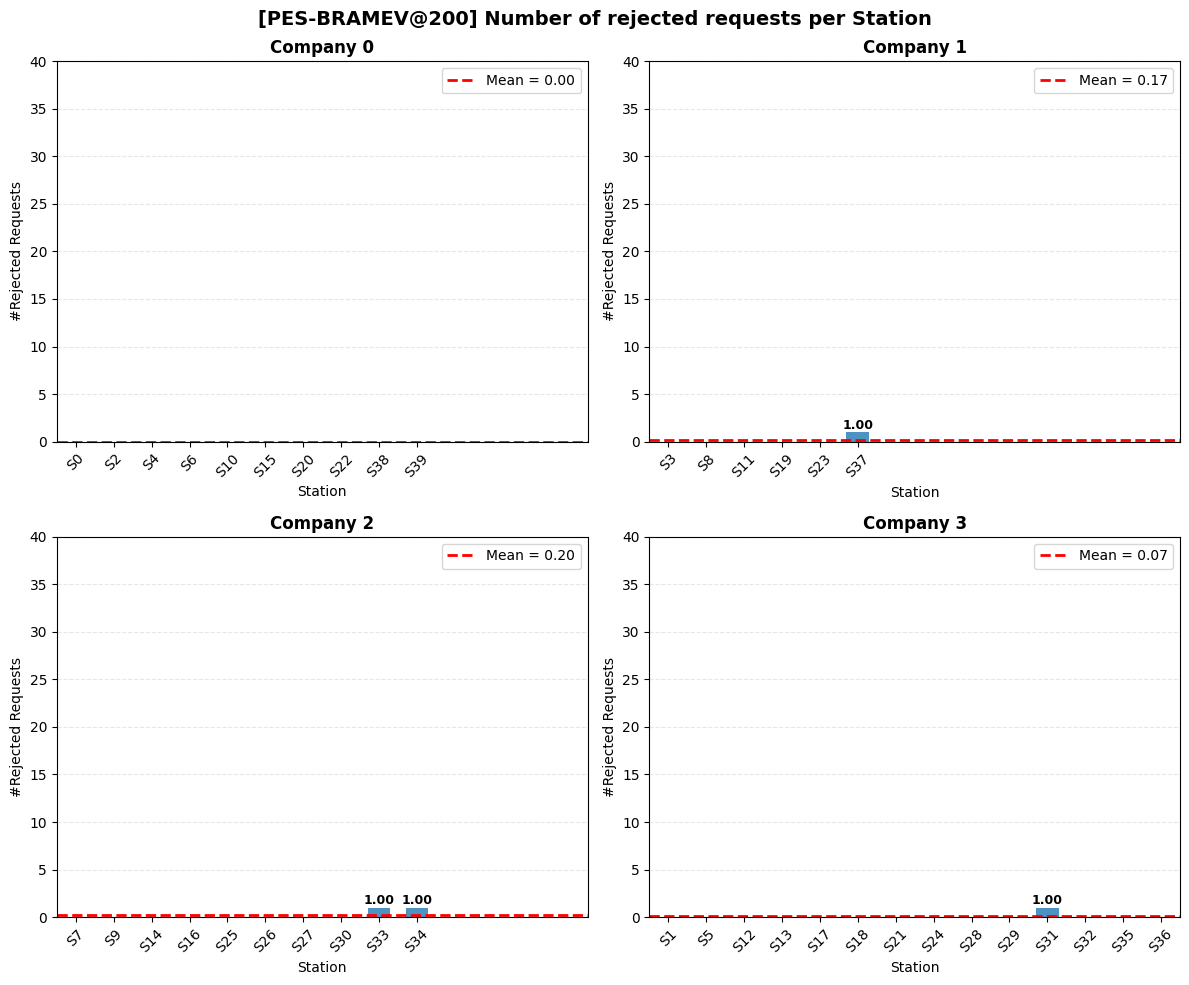

In [170]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

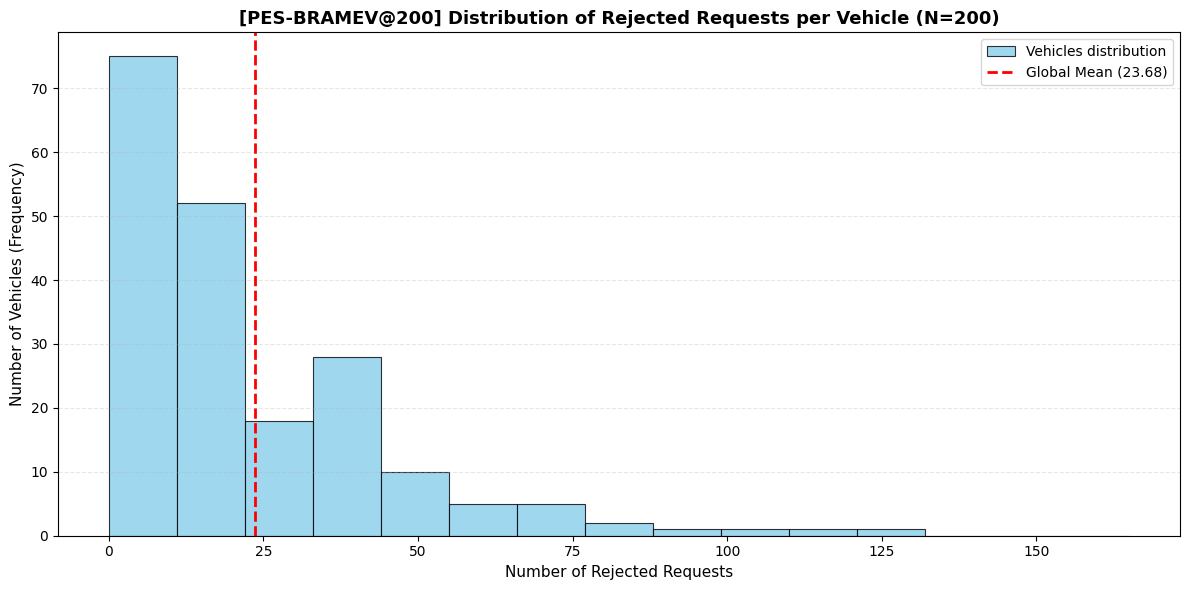

In [171]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

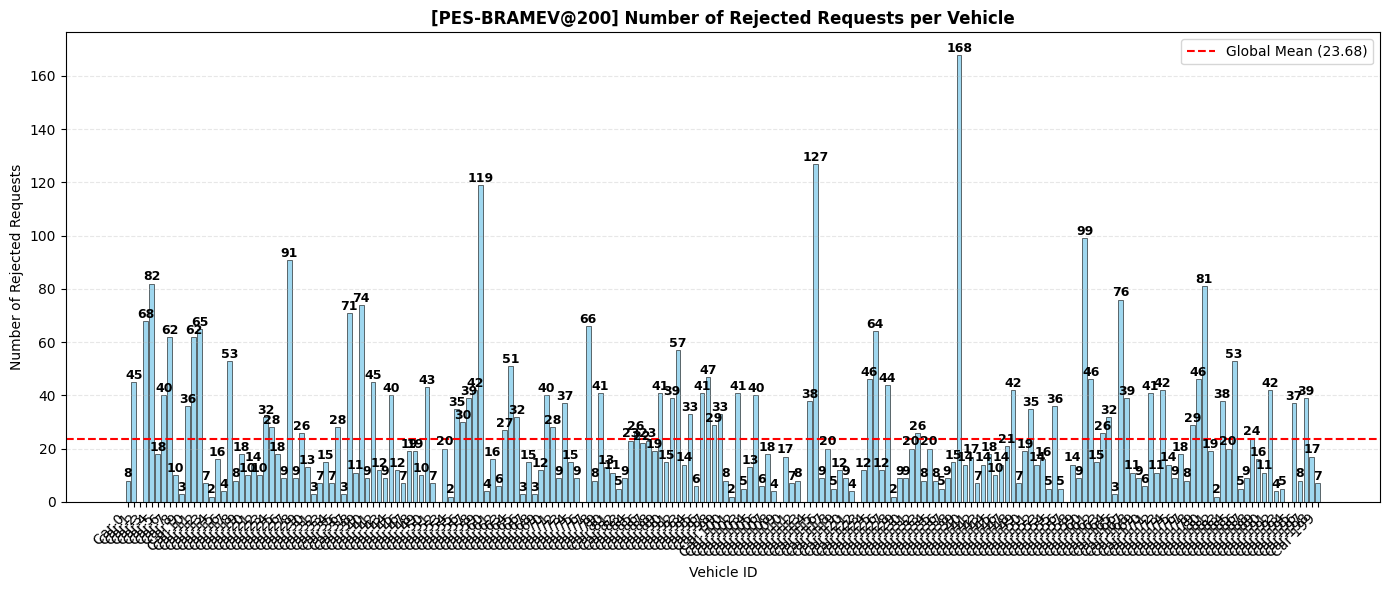

In [172]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

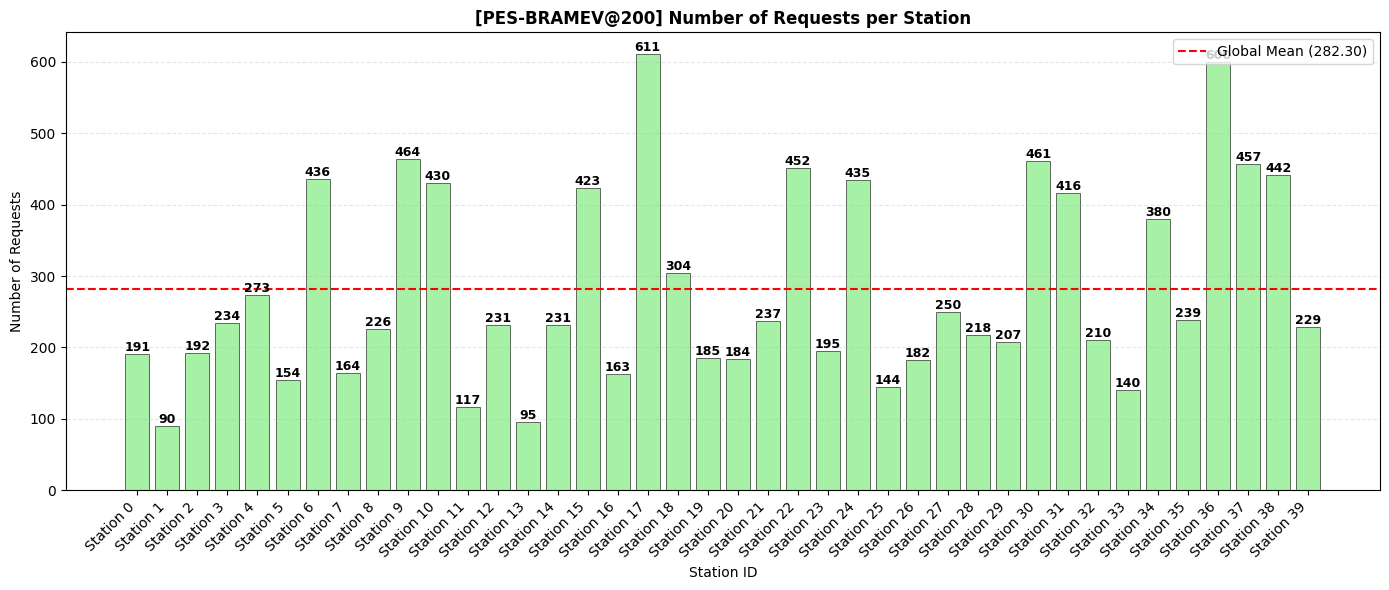

In [173]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [174]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

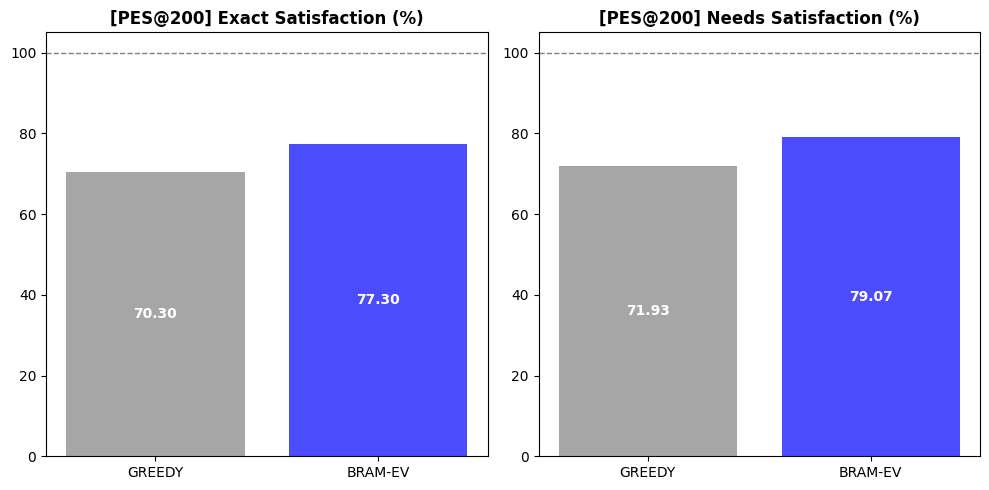

In [175]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

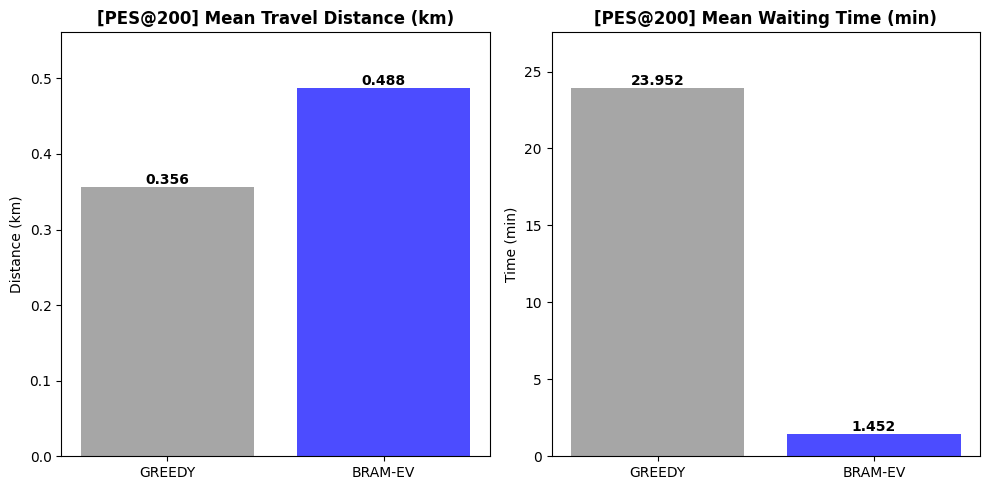

In [176]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

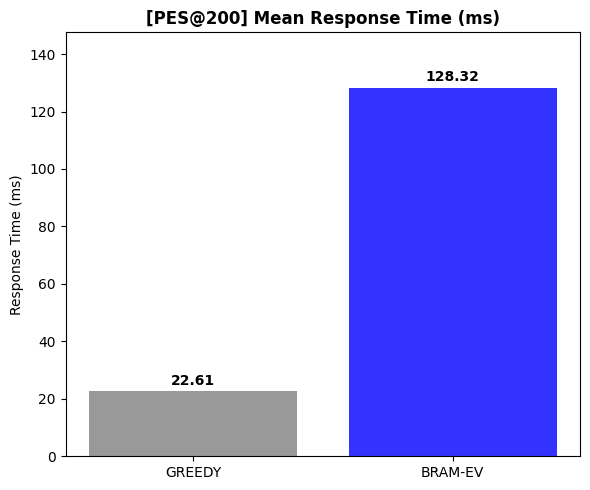

In [177]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [178]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [179]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [180]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [181]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:18:54.645 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:18:55.147 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:18:55.528 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:18:55.883 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:18:56.307 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:18:56.804 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:18:57.346 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:18:57.809 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:18:58.317 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:18:58.896 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:18:59.410 | IN

##### *Metrics*

In [182]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 302.60 kWh
  Station 1: 11.27 kWh
  Station 2: 16.17 kWh
  Station 3: 133.27 kWh
  Station 4: 222.10 kWh
  Station 5: 129.03 kWh
  Station 6: 97.57 kWh
  Station 7: 7.65 kWh
  Station 8: 35.67 kWh
  Station 9: 53.36 kWh
  Station 10: 4.22 kWh
  Station 11: 8.26 kWh
  Station 12: 7.10 kWh
  Station 13: 33.65 kWh
  Station 14: 9.21 kWh
  Station 15: 19.19 kWh
  Station 16: 49.17 kWh
  Station 17: 49.26 kWh
  Station 18: 5.00 kWh
  Station 19: 122.54 kWh
  Station 20: 76.83 kWh
  Station 21: 88.03 kWh
  Station 22: 94.18 kWh
  Station 23: 33.62 kWh
  Station 24: 1.69 kWh
  Station 25: 31.65 kWh
  Station 26: 23.11 kWh
  Station 27: 255.82 kWh
  Station 28: 16.30 kWh
  Station 29: 1.88 kWh
  Station 30: 8.50 kWh
  Station 31: 238.58 kWh
  Station 32: 19.12 kWh
  Station 33: 24.49 kWh
  Station 34: 29.36 kWh
  Station 35: 90.83 kWh
  Station 36: 115.53 kWh
  Station 37: 11.08 kWh
  Station 38: 103.82 kWh
  Station 3

In [183]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

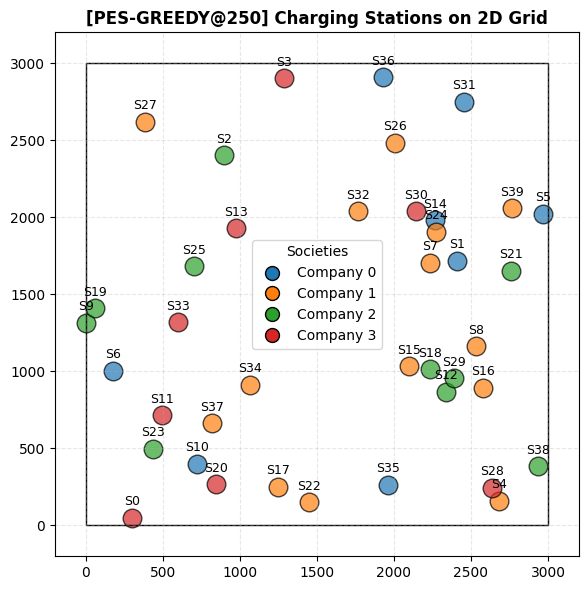

In [184]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

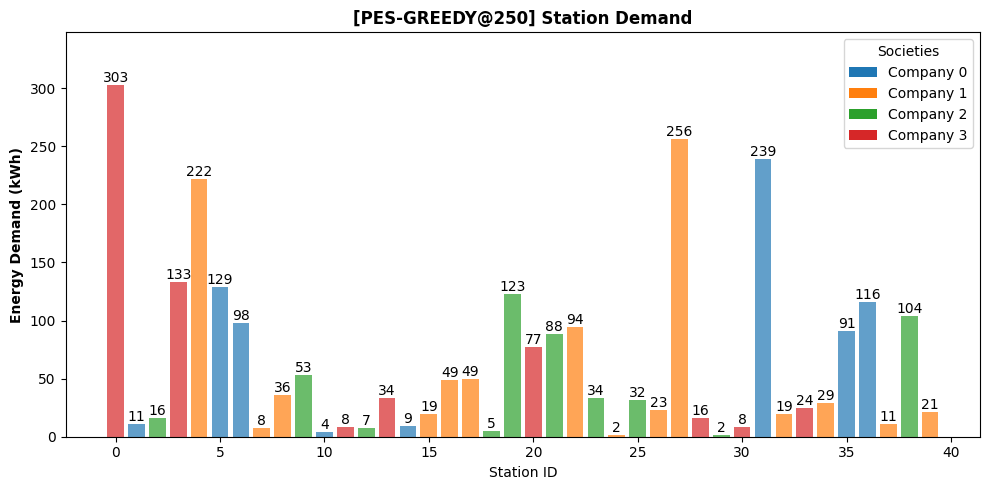

In [185]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

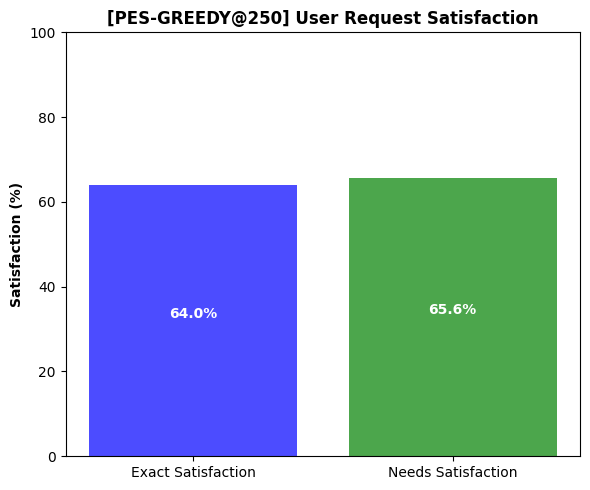

In [186]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

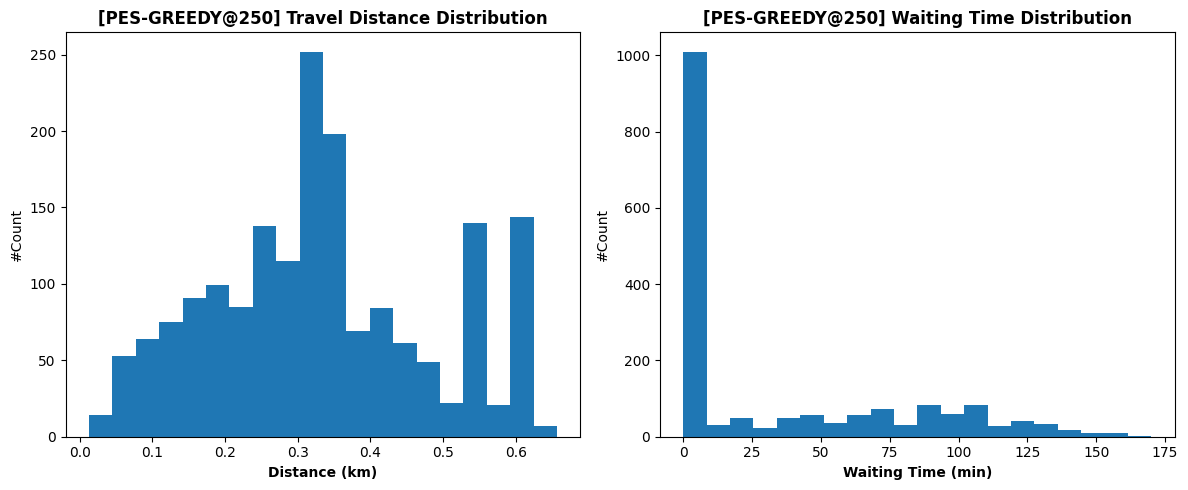

In [187]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

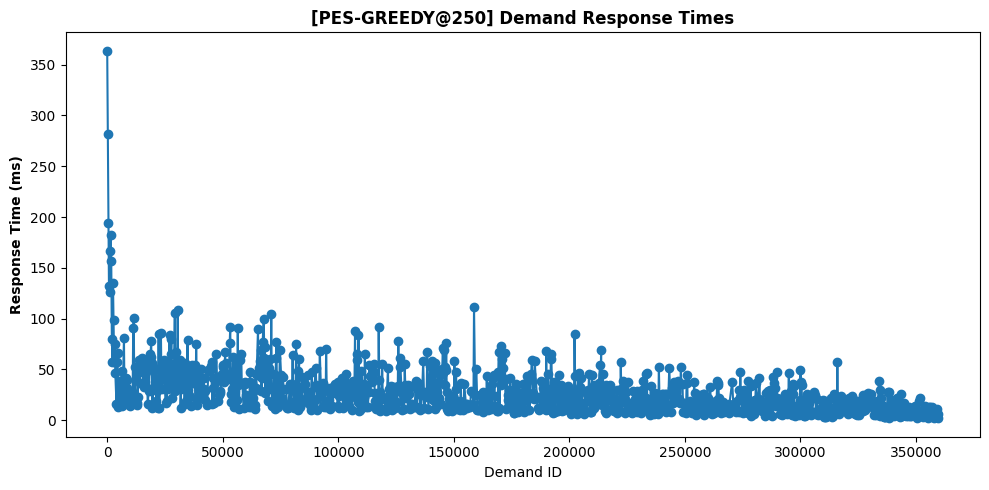

In [188]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

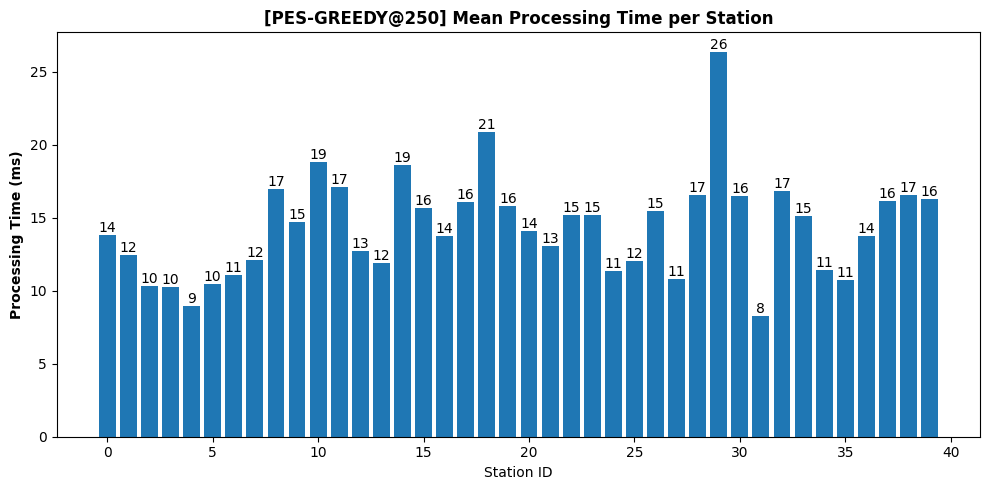

In [189]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [190]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.178472  0.000000  0.000000  0.000000       NaN   
1            0           5  0.694444  0.529861  0.304861  0.325694       NaN   
2            0           6  0.606944  0.427778  0.188889  0.252083       NaN   
3            0          10  0.061806  0.000000  0.000000  0.000000  0.000000   
4            0          14  0.127778  0.000000  0.000000  0.000000  0.000000   
5            0          31  0.736111  0.781944  0.830556  0.839583       NaN   
6            0          35  0.551389  0.352778  0.195139  0.181250       NaN   
7            0          36  0.582639  0.490278  0.161806  0.081250  0.279861   
8            1           4  0.750000  0.793750  0.776389  0.620833       NaN   
9            1           7  0.112500  0.000000  0.000000  0.000000  0.000000   
10           1           8  0.337500  0.171528  0.000000  0.000000  0.000000   
11           1          15  0.213194  0.

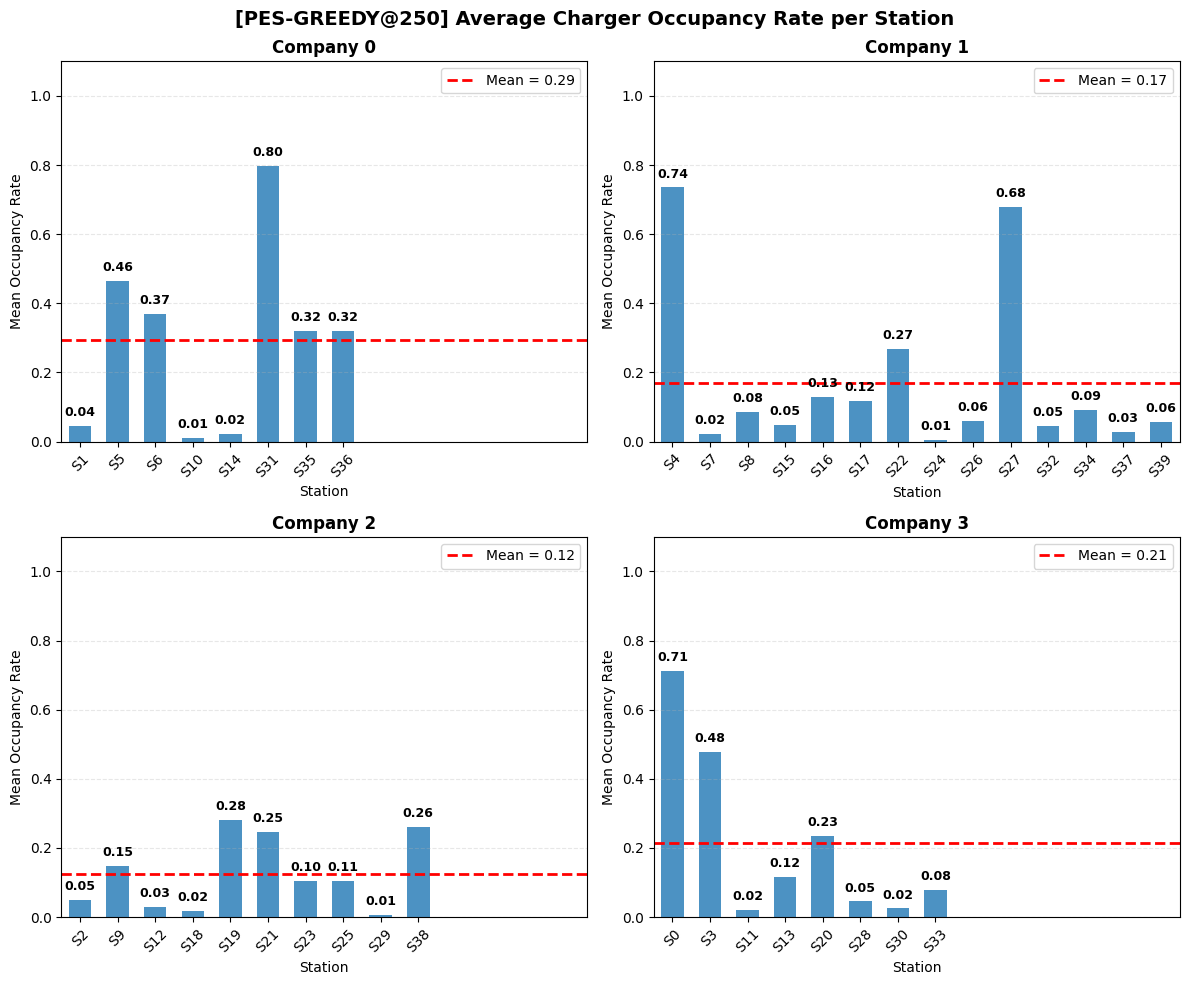

In [191]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

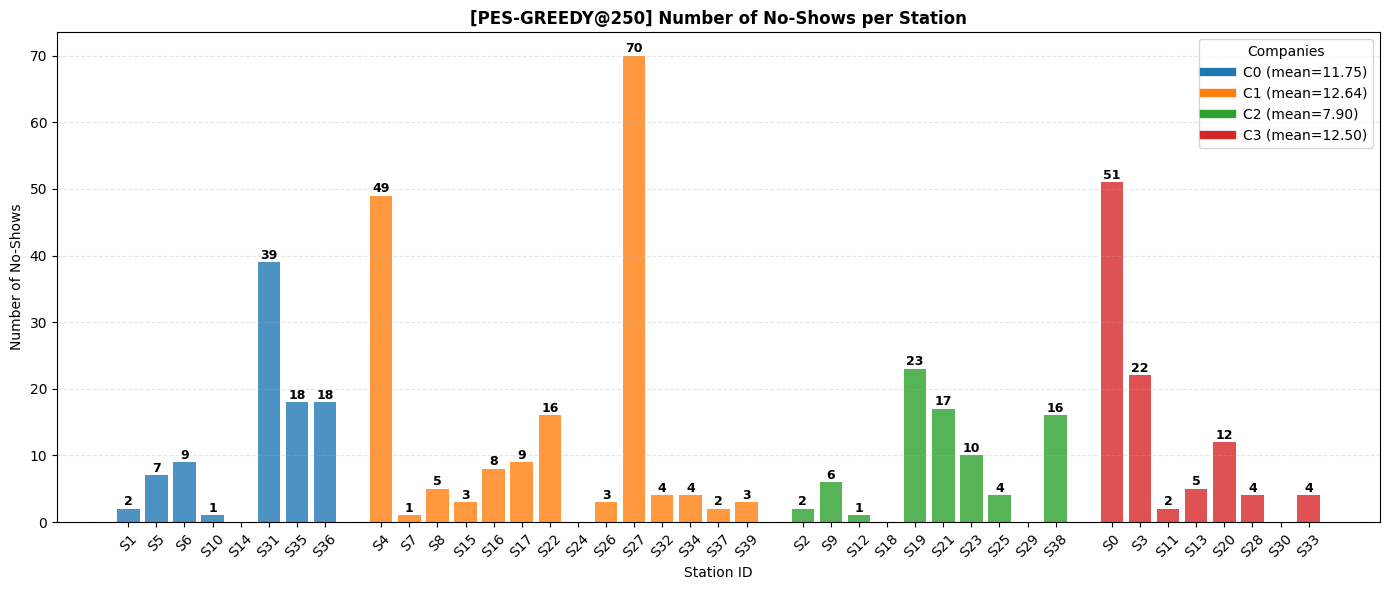

In [192]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [193]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,8,6,2,0,0,0.750000,0.250000,0.000000,0.000000
1,0,5,85,77,7,0,0,0.905882,0.082353,0.000000,0.000000
2,0,6,63,52,9,0,0,0.825397,0.142857,0.000000,0.000000
3,0,10,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
4,0,14,6,5,0,0,0,0.833333,0.000000,0.000000,0.000000
5,0,31,270,208,39,13,8,0.770370,0.144444,0.048148,0.029630
6,0,35,73,54,18,0,0,0.739726,0.246575,0.000000,0.000000
7,0,36,84,65,18,0,0,0.773810,0.214286,0.000000,0.000000
8,1,4,257,176,49,23,8,0.684825,0.190661,0.089494,0.031128
9,1,7,6,5,1,0,0,0.833333,0.166667,0.000000,0.000000


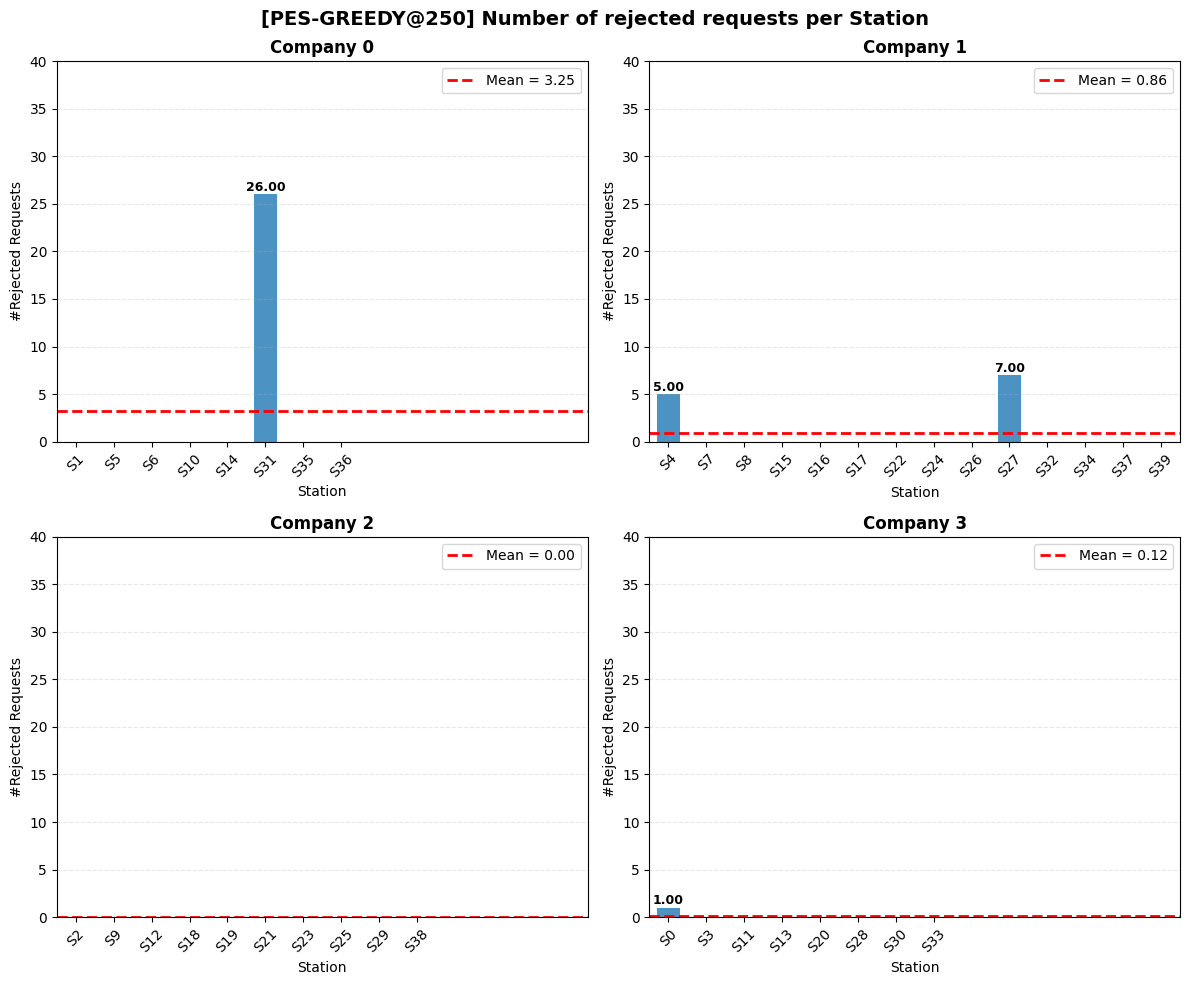

In [194]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [195]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [196]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [197]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:19:38.914 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:19:49.167 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:19:58.792 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:20:08.641 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:20:18.482 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:20:28.747 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:20:39.688 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:20:51.249 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:21:03.605 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:21:16.214 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:21:28.716 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [198]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 20.67 kWh
  Station 1: 7.08 kWh
  Station 2: 2.33 kWh
  Station 3: 13.03 kWh
  Station 4: 1.35 kWh
  Station 5: 30.29 kWh
  Station 6: 24.21 kWh
  Station 7: 10.48 kWh
  Station 8: 33.12 kWh
  Station 9: 17.74 kWh
  Station 10: 27.43 kWh
  Station 11: 31.89 kWh
  Station 12: 14.70 kWh
  Station 13: 23.11 kWh
  Station 14: 31.86 kWh
  Station 15: 3.13 kWh
  Station 16: 10.37 kWh
  Station 17: 24.24 kWh
  Station 18: 15.50 kWh
  Station 19: 13.78 kWh
  Station 20: 44.38 kWh
  Station 21: 2.90 kWh
  Station 22: 29.38 kWh
  Station 23: 21.16 kWh
  Station 24: 45.77 kWh
  Station 25: 24.59 kWh
  Station 26: 5.09 kWh
  Station 27: 6.46 kWh
  Station 28: 7.72 kWh
  Station 29: 44.26 kWh
  Station 30: 105.06 kWh
  Station 31: 10.43 kWh
  Station 32: 12.18 kWh
  Station 33: 27.64 kWh
  Station 34: 6.62 kWh
  Station 35: 27.84 kWh
  Station 36: 61.16 kWh
  Station 37: 77.10 kWh
  Station 38: 10.42 kWh
  Station 39: 105.0

In [199]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

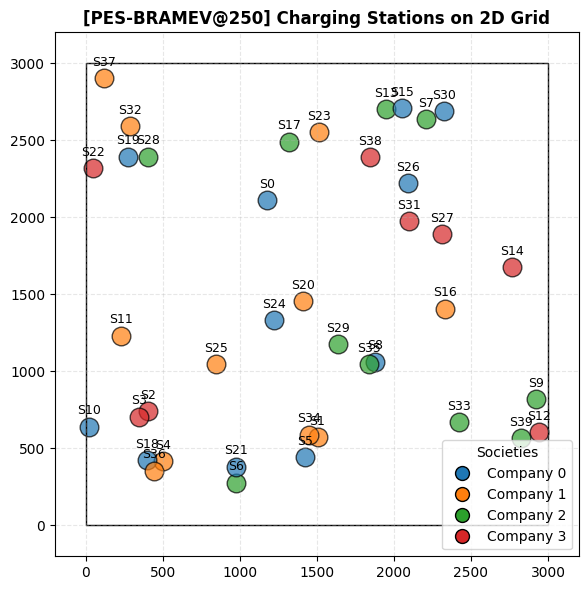

In [200]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

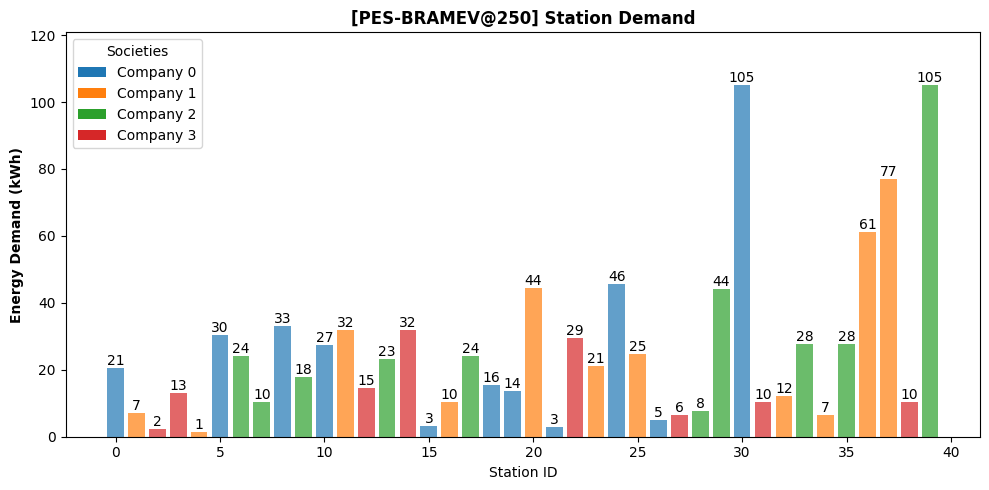

In [201]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

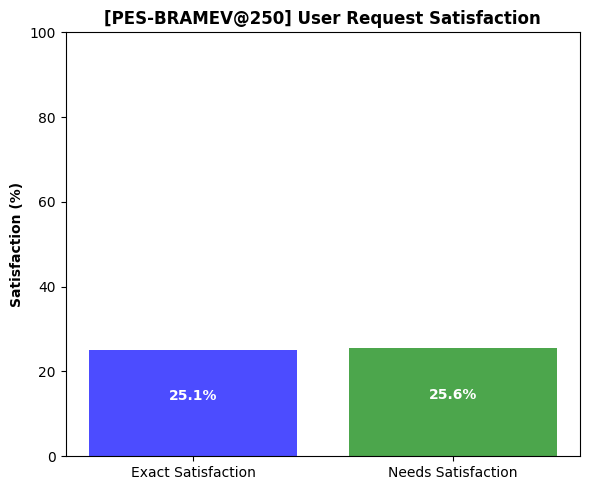

In [202]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

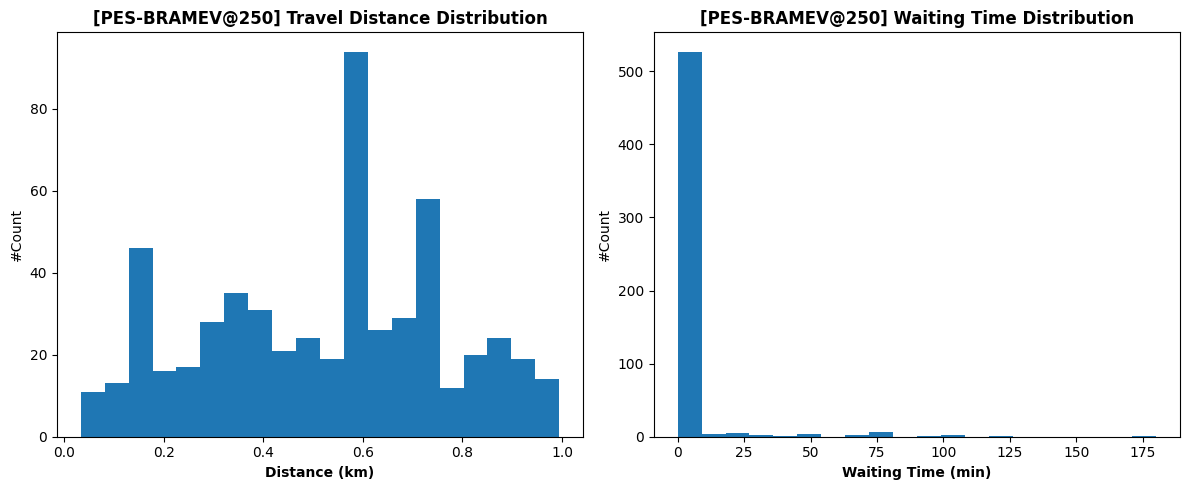

In [203]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

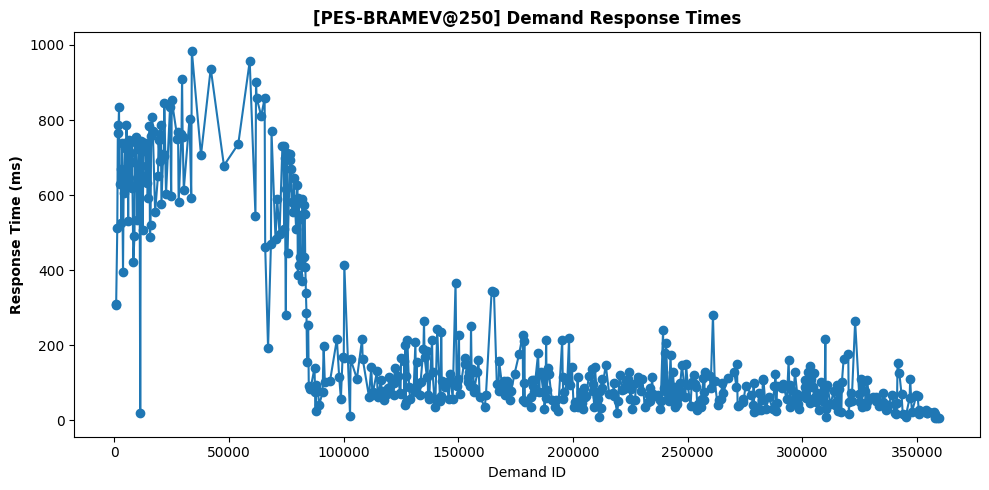

In [204]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

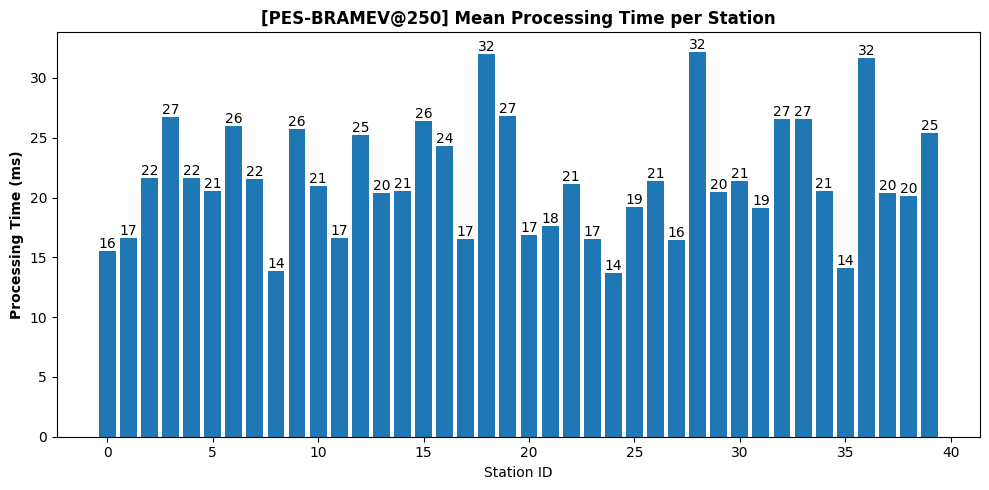

In [205]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

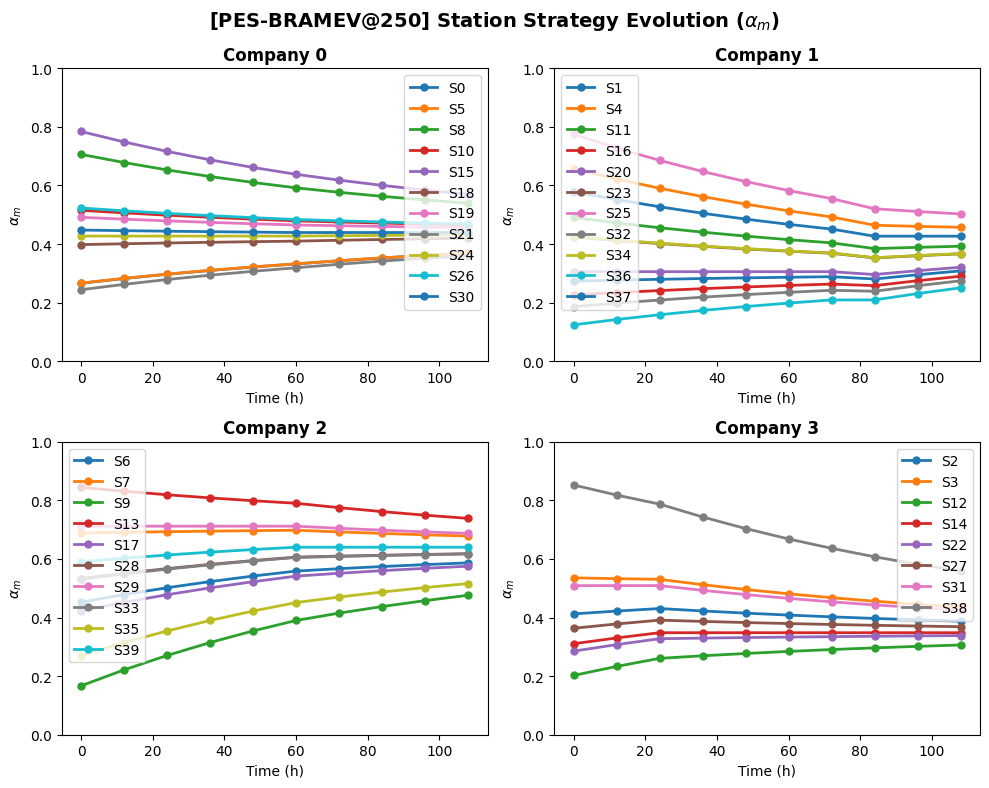

In [206]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [207]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.206944  0.066667  0.030556  0.040278       NaN   
1            0           5  0.278472  0.090972  0.052778  0.000000  0.057639   
2            0           8  0.156944  0.034722  0.135417  0.159722       NaN   
3            0          10  0.238889  0.105556  0.036111  0.040278       NaN   
4            0          15  0.059722  0.000000  0.000000  0.000000  0.000000   
5            0          18  0.208333  0.017361  0.000000  0.000000  0.000000   
6            0          19  0.128472  0.043056  0.000000  0.000000  0.029861   
7            0          21  0.040278  0.000000  0.000000  0.000000       NaN   
8            0          24  0.241667  0.225694  0.120139  0.111111       NaN   
9            0          26  0.066667  0.000000  0.000000  0.000000  0.000000   
10           0          30  0.523611  0.342361  0.243750  0.377778       NaN   
11           1           1  0.088889  0.

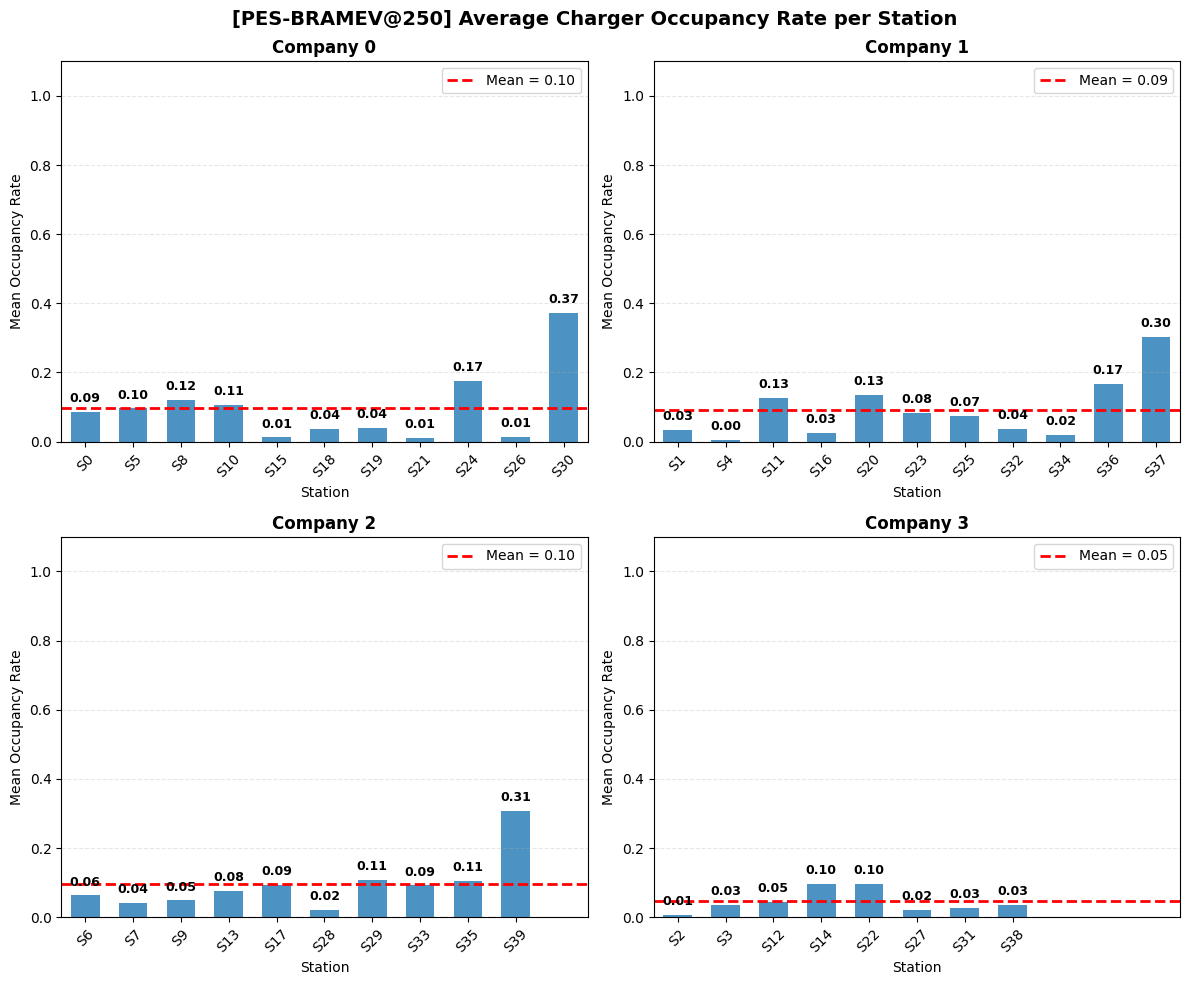

In [208]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

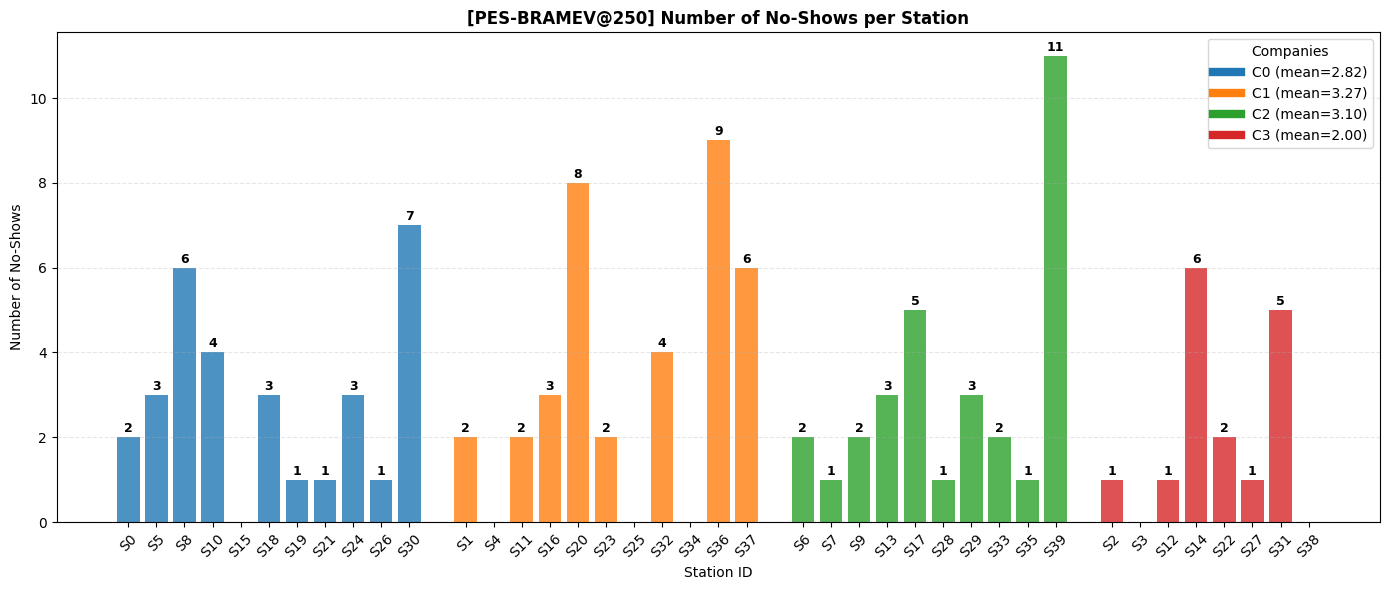

In [209]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [210]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,13,11,2,0,0,0.846154,0.153846,0.0,0.000000
1,0,5,18,15,3,0,0,0.833333,0.166667,0.0,0.000000
2,0,8,20,14,6,0,0,0.700000,0.300000,0.0,0.000000
3,0,10,20,16,4,0,0,0.800000,0.200000,0.0,0.000000
4,0,15,2,2,0,0,0,1.000000,0.000000,0.0,0.000000
5,0,18,11,8,3,0,0,0.727273,0.272727,0.0,0.000000
6,0,19,8,7,1,0,0,0.875000,0.125000,0.0,0.000000
7,0,21,3,2,1,0,0,0.666667,0.333333,0.0,0.000000
8,0,24,30,25,3,0,1,0.833333,0.100000,0.0,0.033333
9,0,26,4,3,1,0,0,0.750000,0.250000,0.0,0.000000


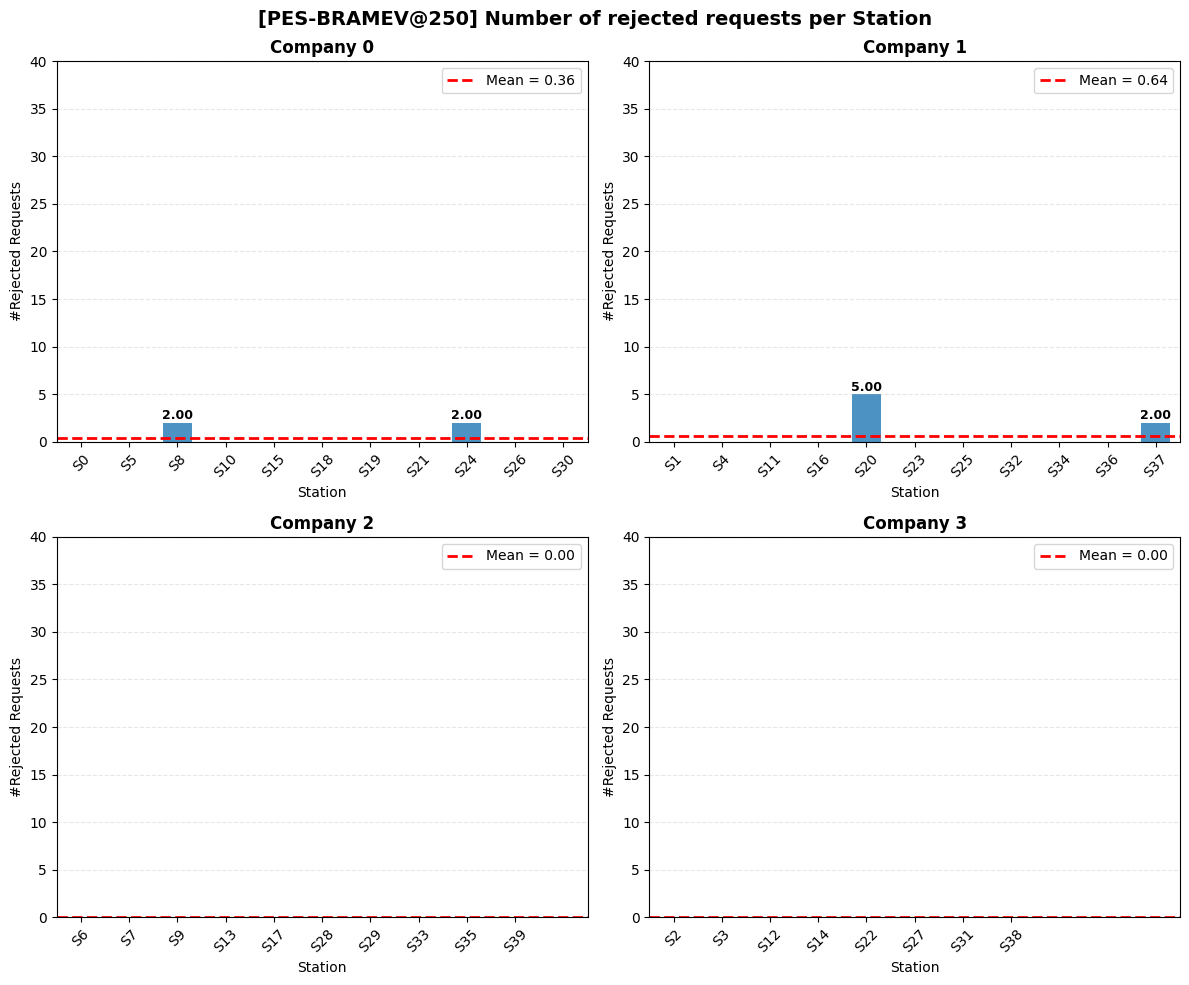

In [211]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

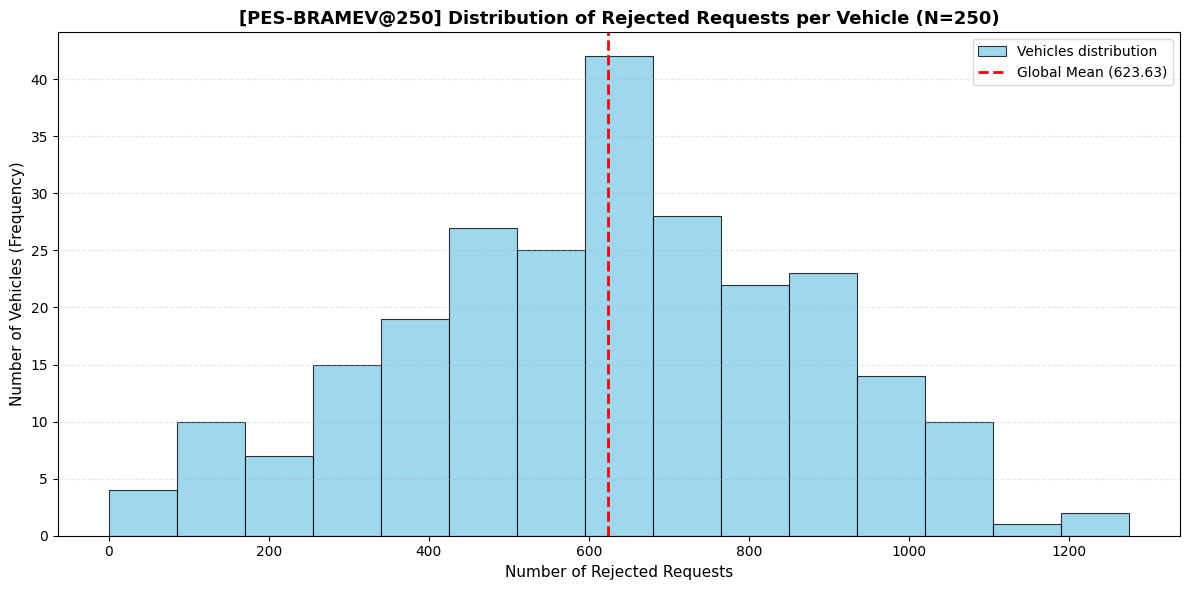

In [212]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

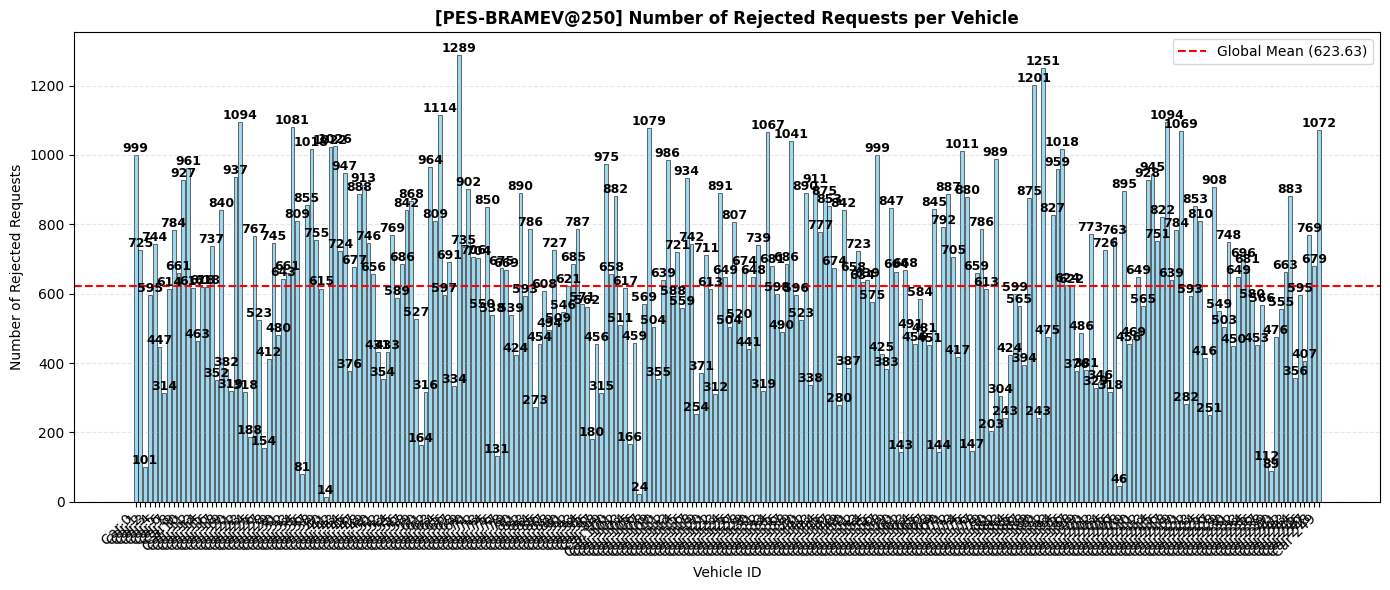

In [213]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

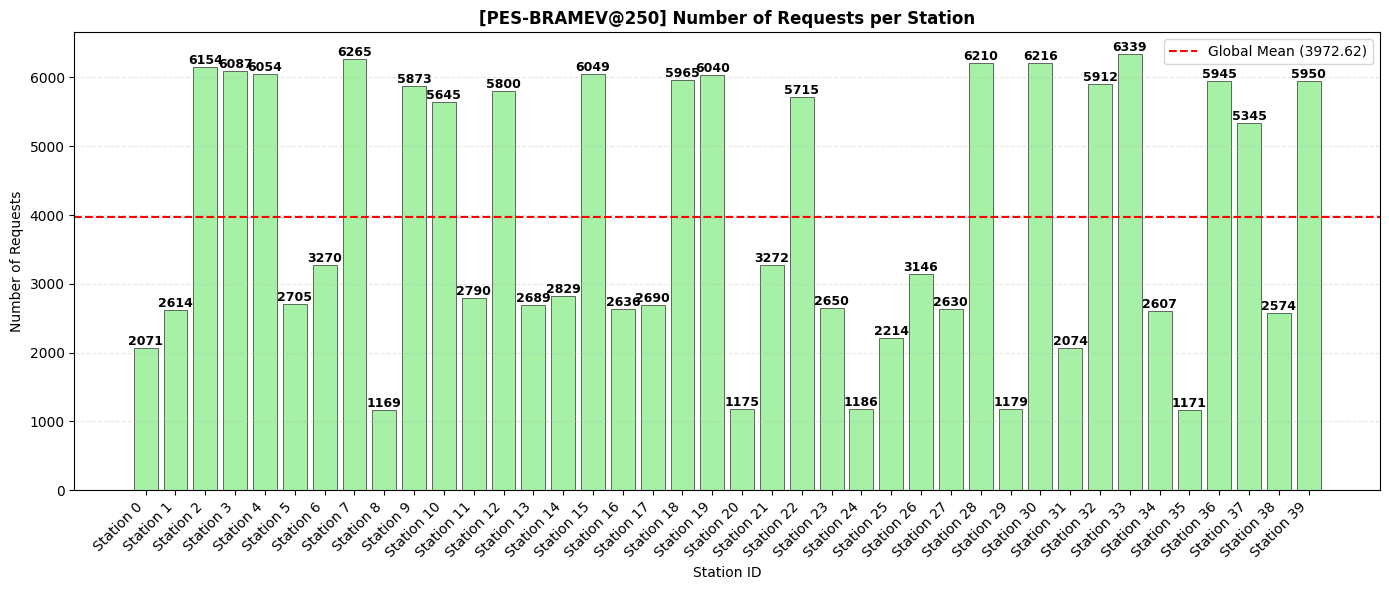

In [214]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [215]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

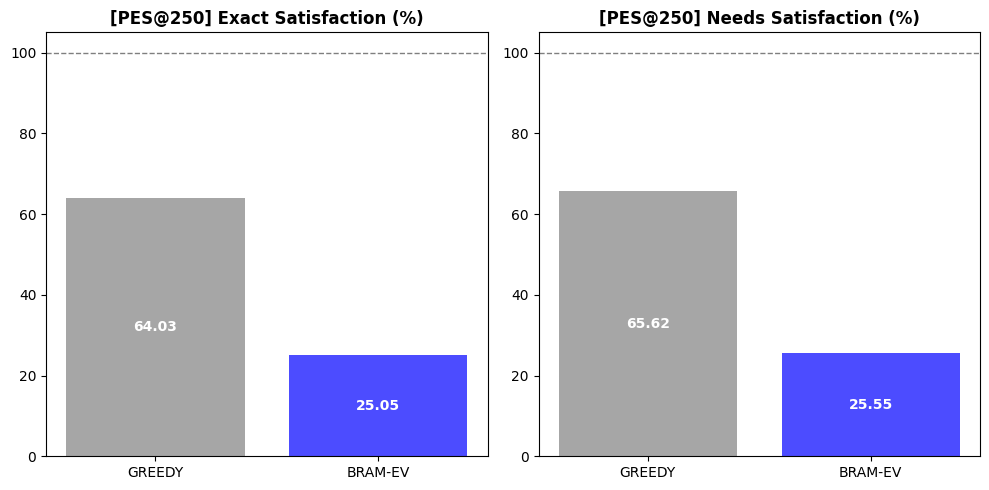

In [216]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

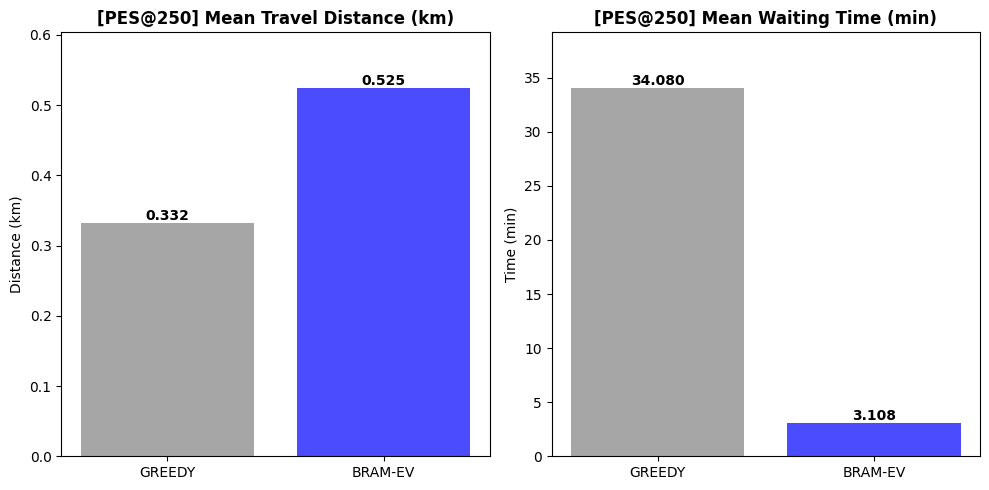

In [217]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

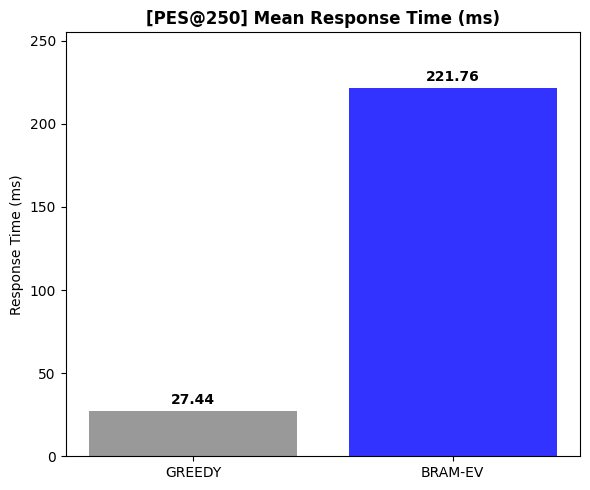

In [218]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

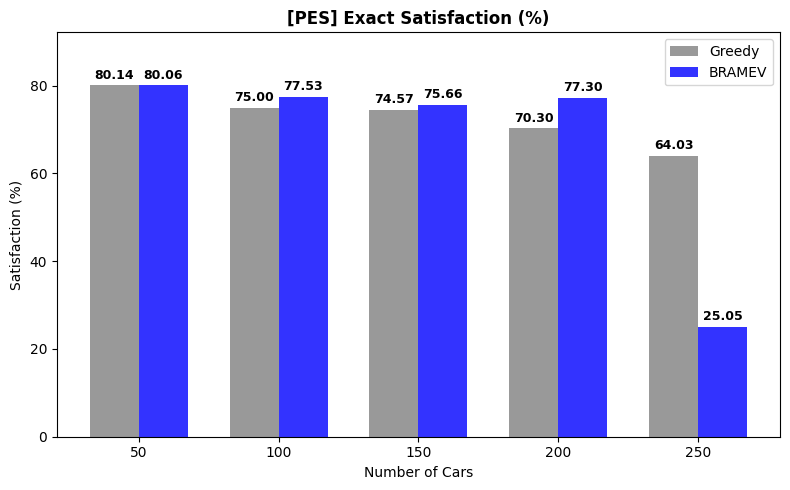

In [219]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

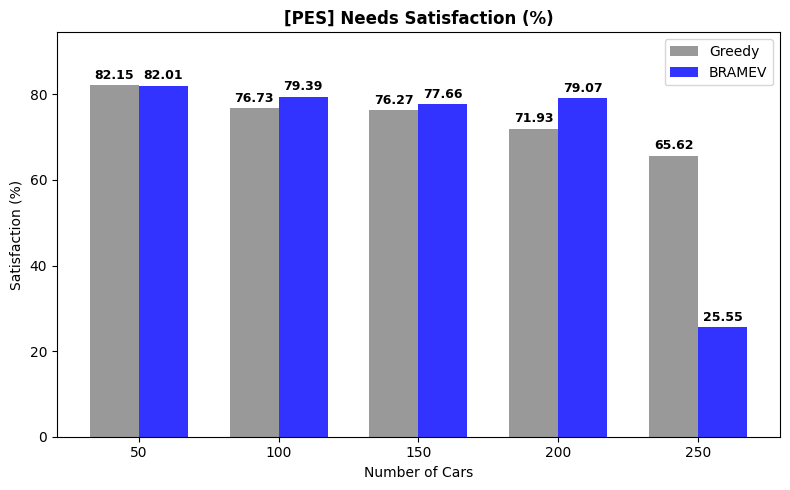

In [220]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

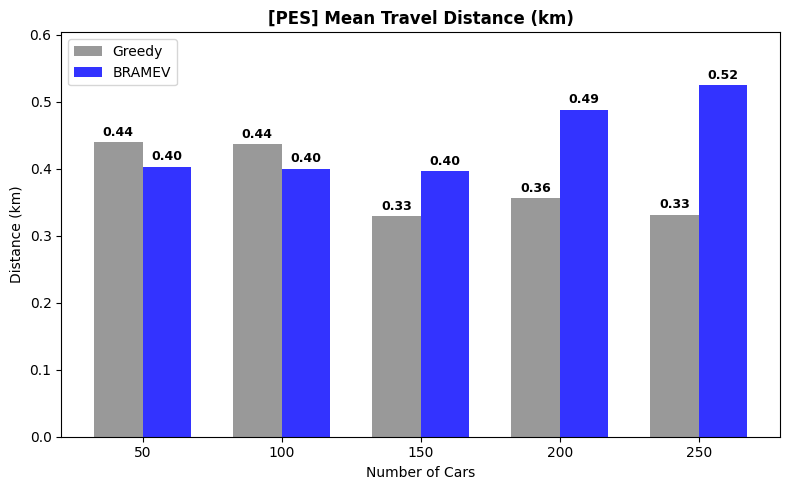

In [221]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


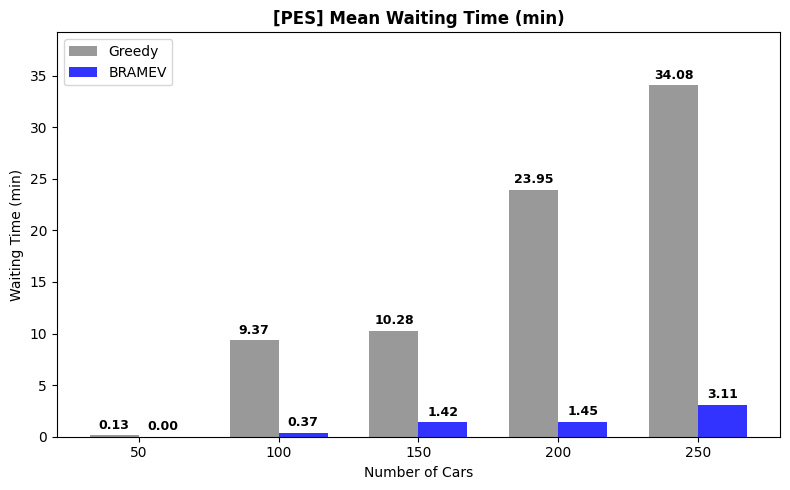

In [222]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


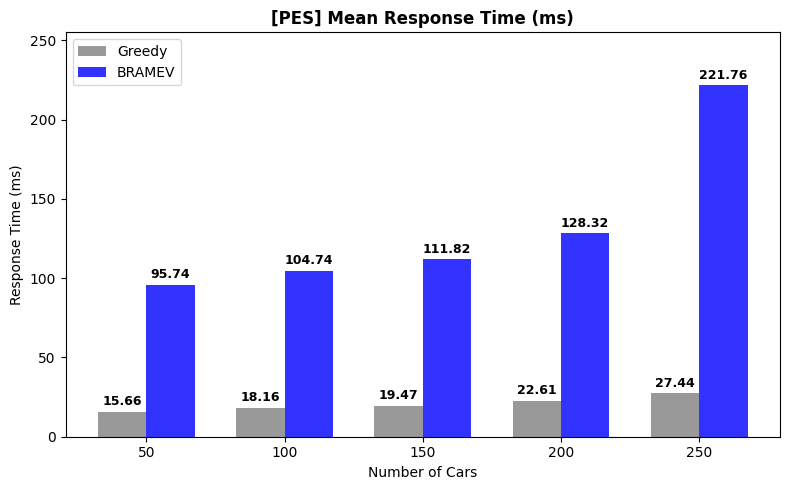

: 

In [ ]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
